# Trabajo Práctico Integrador — Modelado Comparativo en Minería de Datos
## Clasificación: *Telco Customer Churn* · Regresión: *Medical Cost Personal*

**Materia:** Modelizado de Minería de Datos — Tecnicatura Superior en Ciencia de Datos e IA (IFTS N°18)  
**Modalidad:** trabajo práctico grupal (5 integrantes) — *en desarrollo*  
**Fecha de entrega:** 04/11/2026

---

## Objetivo

Realizar un modelado completo para **un problema de clasificación** y **un problema de regresión**, comparando las técnicas y los procedimientos vistos en la materia: estadística descriptiva y visualización, limpieza, transformaciones, codificación de variables categóricas, selección de características, métodos de remuestreo, métricas de evaluación y algoritmos de Machine Learning lineales y no lineales.

| Parte | Problema | Dataset | Variable objetivo |
|---|---|---|---|
| **A** | Clasificación binaria | *Telco Customer Churn* (IBM / Kaggle) — 7.043 clientes | ¿El cliente **se da de baja** (*churn*)? → Yes / No |
| **B** | Regresión | *Medical Cost Personal* (Kaggle) — 1.338 asegurados | **Costo médico anual** (`charges`, en USD) |

## Índice

**0.** Librerías y configuración
**Parte A — Clasificación binaria (Telco Customer Churn)**: A1. Descripción del problema · A2. Análisis exploratorio (EDA) · A3. Preprocesamiento · A4. Selección de características · A5. Métodos de remuestreo · A6. Modelado y comparación de algoritmos · A7. Evaluación final en test · A8. Modelo final y predicción
**Parte B — Regresión (Medical Cost)**: B1. Descripción del problema · B2. EDA · B3. Preprocesamiento · B4. Selección de características · B5. Modelado y comparación de algoritmos · B6. Evaluación final en test · B7. Modelo final y predicción
**Conclusiones** generales, limitaciones y posibles mejoras
**Anexo:** qué tema de la materia se aplicó en cada sección

## 0. Librerías y configuración

Usamos las librerías vistas en la materia: **NumPy** y **Pandas** para manipular datos, **Matplotlib** y **Seaborn** para visualizar, **scikit-learn** para transformaciones, remuestreo, selección de variables, modelos y métricas.

Fijamos una semilla (`SEED = 42`) para que todos los resultados sean reproducibles.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Remuestreo
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, RepeatedStratifiedKFold,
                                     ShuffleSplit, LeaveOneOut, cross_val_score, cross_validate, cross_val_predict)
# Transformaciones y codificación
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, Normalizer, Binarizer,
                                   PowerTransformer, LabelEncoder)
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
# Selección de características y reducción de dimensiones
from sklearn.feature_selection import SelectKBest, chi2, f_classif, f_regression, RFE
from sklearn.decomposition import PCA
# Algoritmos lineales
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, LassoCV, ElasticNet
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# Algoritmos no lineales
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.svm import SVC, SVR
# Feature importance
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, ExtraTreesRegressor, RandomForestRegressor
# Métricas
from sklearn.metrics import (accuracy_score, cohen_kappa_score, roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report, roc_curve, make_scorer,
                             mean_absolute_error, mean_squared_error, r2_score)

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 90

SEED = 42
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


Definimos dos funciones auxiliares para no repetir código. Cada una aplica el **mismo arnés de prueba** (*test harness*, clase 29-30) a todos los modelos: la misma validación cruzada y las mismas métricas, de modo que la comparación sea justa. Lo único que cambia de un modelo a otro es el modelo.

In [2]:
# Métricas de clasificación (clase 15-16): accuracy, kappa de Cohen, AUC ROC y F1 de la clase positiva
SCORING_CLF = {"accuracy": "accuracy",
               "kappa": make_scorer(cohen_kappa_score),
               "auc": "roc_auc",
               "f1": "f1"}

def comparar_clasificadores(modelos, X, y, cv):
    """Evalúa cada modelo con validación cruzada y devuelve (tabla resumen, resultados por fold)."""
    filas, folds = [], {}
    for nombre, modelo in modelos.items():
        r = cross_validate(modelo, X, y, cv=cv, scoring=SCORING_CLF)
        folds[nombre] = r
        filas.append({"modelo": nombre,
                      "accuracy": r["test_accuracy"].mean(),
                      "kappa": r["test_kappa"].mean(),
                      "AUC": r["test_auc"].mean(),
                      "AUC (desv)": r["test_auc"].std(),
                      "F1": r["test_f1"].mean()})
    return pd.DataFrame(filas).set_index("modelo").sort_values("AUC", ascending=False), folds

# Métricas de regresión (clase 15-16): MSE (en negativo), MAE y R²
SCORING_REG = {"neg_mse": "neg_mean_squared_error",
               "neg_mae": "neg_mean_absolute_error",
               "r2": "r2"}

def comparar_regresores(modelos, X, y, cv):
    """Evalúa cada regresor con validación cruzada. RMSE = raíz del MSE promedio (en USD)."""
    filas, folds = [], {}
    for nombre, modelo in modelos.items():
        r = cross_validate(modelo, X, y, cv=cv, scoring=SCORING_REG)
        folds[nombre] = r
        filas.append({"modelo": nombre,
                      "Neg MSE": r["test_neg_mse"].mean(),
                      "RMSE": np.sqrt(-r["test_neg_mse"].mean()),
                      "RMSE (desv)": np.sqrt(-r["test_neg_mse"]).std(),
                      "MAE": -r["test_neg_mae"].mean(),
                      "R2": r["test_r2"].mean()})
    return pd.DataFrame(filas).set_index("modelo").sort_values("RMSE"), folds

def contar_atipicos_iqr(df):
    """Cuenta valores fuera de [Q1 - 1.5·IQR ; Q3 + 1.5·IQR] (el criterio de los bigotes del boxplot)."""
    q1, q3 = df.quantile(0.25), df.quantile(0.75)
    iqr = q3 - q1
    fuera = (df < q1 - 1.5 * iqr) | (df > q3 + 1.5 * iqr)
    return pd.DataFrame({"atípicos": fuera.sum(), "% del total": (fuera.mean() * 100).round(1)})

---
# PARTE A — CLASIFICACIÓN BINARIA: *Telco Customer Churn*

## A1. Descripción del problema

**Contexto.** El dataset *Telco Customer Churn* (publicado por IBM como dataset de ejemplo y muy usado en Kaggle) tiene **7.043 clientes** de una empresa de telecomunicaciones (telefonía e internet). De cada cliente se registraron sus datos demográficos, los servicios que tiene contratados, el tipo de contrato, la forma de pago, lo que paga y **si se dio de baja en el último mes** (*churn*, fuga o abandono de clientes).

| Grupo | Variables |
|---|---|
| Identificador | `customerID` (no se usa para modelar) |
| Datos demográficos | `gender` (sexo), `SeniorCitizen` (mayor de 65: 0/1), `Partner` (tiene pareja), `Dependents` (tiene personas a cargo) |
| Antigüedad | `tenure`: meses que lleva como cliente |
| Servicios contratados | `PhoneService`, `MultipleLines`, `InternetService` (DSL / fibra óptica / no tiene), `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Cuenta | `Contract` (mes a mes / 1 año / 2 años), `PaperlessBilling` (factura electrónica), `PaymentMethod` (4 formas de pago) |
| Facturación | `MonthlyCharges` (cargo mensual, USD), `TotalCharges` (total facturado desde el alta, USD) |
| **Variable objetivo** | **`Churn`: ¿el cliente se dio de baja? → `Yes` / `No`** |

**¿Qué queremos predecir?** Si un cliente **se va a dar de baja (`Churn = Yes`) o no (`Churn = No`)**. Es un problema de **clasificación binaria**: la respuesta es una de dos categorías, y la variable objetivo ya viene definida así en el dataset.

**¿Por qué es adecuado para el TP?**
- La variable objetivo es **binaria y está bien definida**.
- Tiene **16 variables categóricas** → obliga a aplicar **Label Encoding y One-Hot Encoding** (y permite mostrar Target Encoding).
- Tiene problemas reales de calidad de datos: una columna numérica guardada como **texto**, **valores faltantes** y **categorías redundantes** ("No internet service") → pasos concretos de limpieza y corrección de formato.
- Las variables numéricas tienen **escalas distintas** y una de ellas es **asimétrica** → sirve para escalado y Yeo-Johnson.
- Hay dos variables **muy correlacionadas** entre sí (antigüedad y total facturado) → sirve para la selección de características.
- La clase está **desbalanceada** (~27 % de bajas) → obliga a usar kappa, AUC, F1 y recall además del accuracy.
- Tamaño razonable (7.043 filas) y variables fáciles de explicar.

**Uso práctico:** detectar a tiempo a los clientes con riesgo de irse permite ofrecerles una **acción de retención** (descuento, cambio de plan), que suele ser mucho más barata que conseguir un cliente nuevo.

## A2. Análisis exploratorio de datos (EDA)

### A2.1 Carga y primera revisión

In [3]:
df_t = pd.read_csv("data/telco_churn.csv")
df_t.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dimensiones (filas, columnas):", df_t.shape)
print("\nTipos de datos:")
print(df_t.dtypes)

Dimensiones (filas, columnas): (7043, 21)

Tipos de datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Primer problema de formato:** `TotalCharges` es un monto en dólares, pero pandas la leyó como **texto**. Eso significa que hay algún valor que no es un número. Lo buscamos:

In [5]:
no_numericos = df_t.loc[pd.to_numeric(df_t["TotalCharges"], errors="coerce").isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
print(f"Filas donde TotalCharges no es un número: {len(no_numericos)}")
no_numericos.assign(TotalCharges=no_numericos["TotalCharges"].map(repr))

Filas donde TotalCharges no es un número: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,' ',No
753,3115-CZMZD,0,20.25,' ',No
936,5709-LVOEQ,0,80.85,' ',No
1082,4367-NUYAO,0,25.75,' ',No
1340,1371-DWPAZ,0,56.05,' ',No
3331,7644-OMVMY,0,19.85,' ',No
3826,3213-VVOLG,0,25.35,' ',No
4380,2520-SGTTA,0,20.00,' ',No
5218,2923-ARZLG,0,19.70,' ',No
6670,4075-WKNIU,0,73.35,' ',No


Son **11 filas con un espacio en blanco** (`' '`) en lugar del monto, y **todas tienen `tenure = 0`**: son clientes que se acaban de dar de alta y todavía no recibieron su primera factura. Convertimos la columna a número; esos espacios quedan como **valores faltantes (NaN)** y los tratamos en la sección de limpieza (A2.10).

También separamos los tipos de variables. `SeniorCitizen` está guardada como número (0/1), pero en realidad es **categórica** (sí/no).

In [6]:
df_t["TotalCharges"] = pd.to_numeric(df_t["TotalCharges"], errors="coerce")
num_t = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_t = [c for c in df_t.columns if c not in num_t + ["customerID", "Churn"]]
print("Numéricas:", num_t)
print(f"Categóricas ({len(cat_t)}):", cat_t)

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### A2.2 Estadística descriptiva

In [7]:
desc_t = df_t[num_t].describe().T
desc_t["mediana"] = df_t[num_t].median()
desc_t["coef_var"] = desc_t["std"] / desc_t["mean"]
desc_t[["count", "mean", "std", "min", "25%", "mediana", "75%", "max", "coef_var"]]

,count,mean,std,min,25%,mediana,75%,max,coef_var
tenure,7043.0,32.371,24.559,0.00,9.00,29.000,55.000,72.00,0.759
MonthlyCharges,7043.0,64.762,30.090,18.25,35.50,70.350,89.850,118.75,0.465
TotalCharges,7032.0,2283.300,2266.771,18.80,401.45,1397.475,3794.738,8684.80,0.993


In [8]:
resumen_cat = pd.DataFrame({"categorías": df_t[cat_t].nunique(),
                            "más frecuente": df_t[cat_t].mode().iloc[0],
                            "% de la más frecuente": [df_t[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_t]})
resumen_cat.round(1)

,categorías,más frecuente,% de la más frecuente
gender,2,Male,50.5
SeniorCitizen,2,0,83.8
Partner,2,No,51.7
Dependents,2,No,70.0
PhoneService,2,Yes,90.3
MultipleLines,3,No,48.1
InternetService,3,Fiber optic,44.0
OnlineSecurity,3,No,49.7
OnlineBackup,3,No,43.8
DeviceProtection,3,No,43.9


**Lo que vemos:**
- `tenure` va de 0 a 72 meses (6 años); la mediana es 29 meses.
- `MonthlyCharges` va de ~18 a ~119 USD por mes.
- `TotalCharges` llega a ~8.700 USD y su **media (2.283) es mucho mayor que la mediana (1.397)**: asimetría a la derecha (muchos clientes con poco facturado y pocos con mucho).
- `TotalCharges` tiene **11 valores menos** en `count` (los faltantes).
- Las escalas son muy distintas (meses, dólares por mes, dólares totales) → k-NN y SVM van a necesitar escalado.
- La mayoría de las categóricas tienen 2 o 3 categorías; `PaymentMethod` tiene 4.

### A2.3 Distribución entre clases

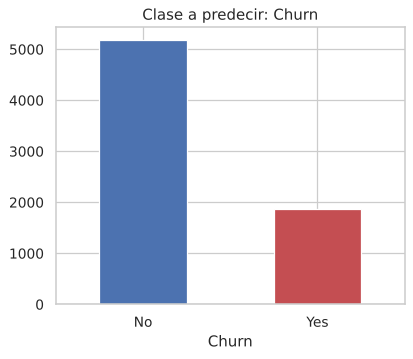

       cantidad     %
Churn                
No         5174  73.5
Yes        1869  26.5

Baseline (predecir siempre 'No'): accuracy = 73.5%


In [9]:
conteo_t = df_t.groupby("Churn").size()
fig, ax = plt.subplots(figsize=(5, 4))
conteo_t.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Clase a predecir: Churn"); ax.tick_params(axis="x", rotation=0)
plt.show()
print(pd.DataFrame({"cantidad": conteo_t, "%": (conteo_t / len(df_t) * 100).round(1)}))
baseline_t = conteo_t.max() / conteo_t.sum()
print(f"\nBaseline (predecir siempre 'No'): accuracy = {baseline_t:.1%}")

La clase está **desbalanceada**: el **26,5 %** de los clientes se dio de baja. Un modelo que diga siempre "No" acertaría el **73,5 %**: ese es el **baseline** que cualquier modelo tiene que superar, y por eso vamos a evaluar también con **kappa, AUC ROC, F1 y recall** de la clase "Yes".

**Tasa de baja según cada variable categórica.** La línea punteada es la tasa general (26,5 %). Las barras muy por encima indican grupos de riesgo.

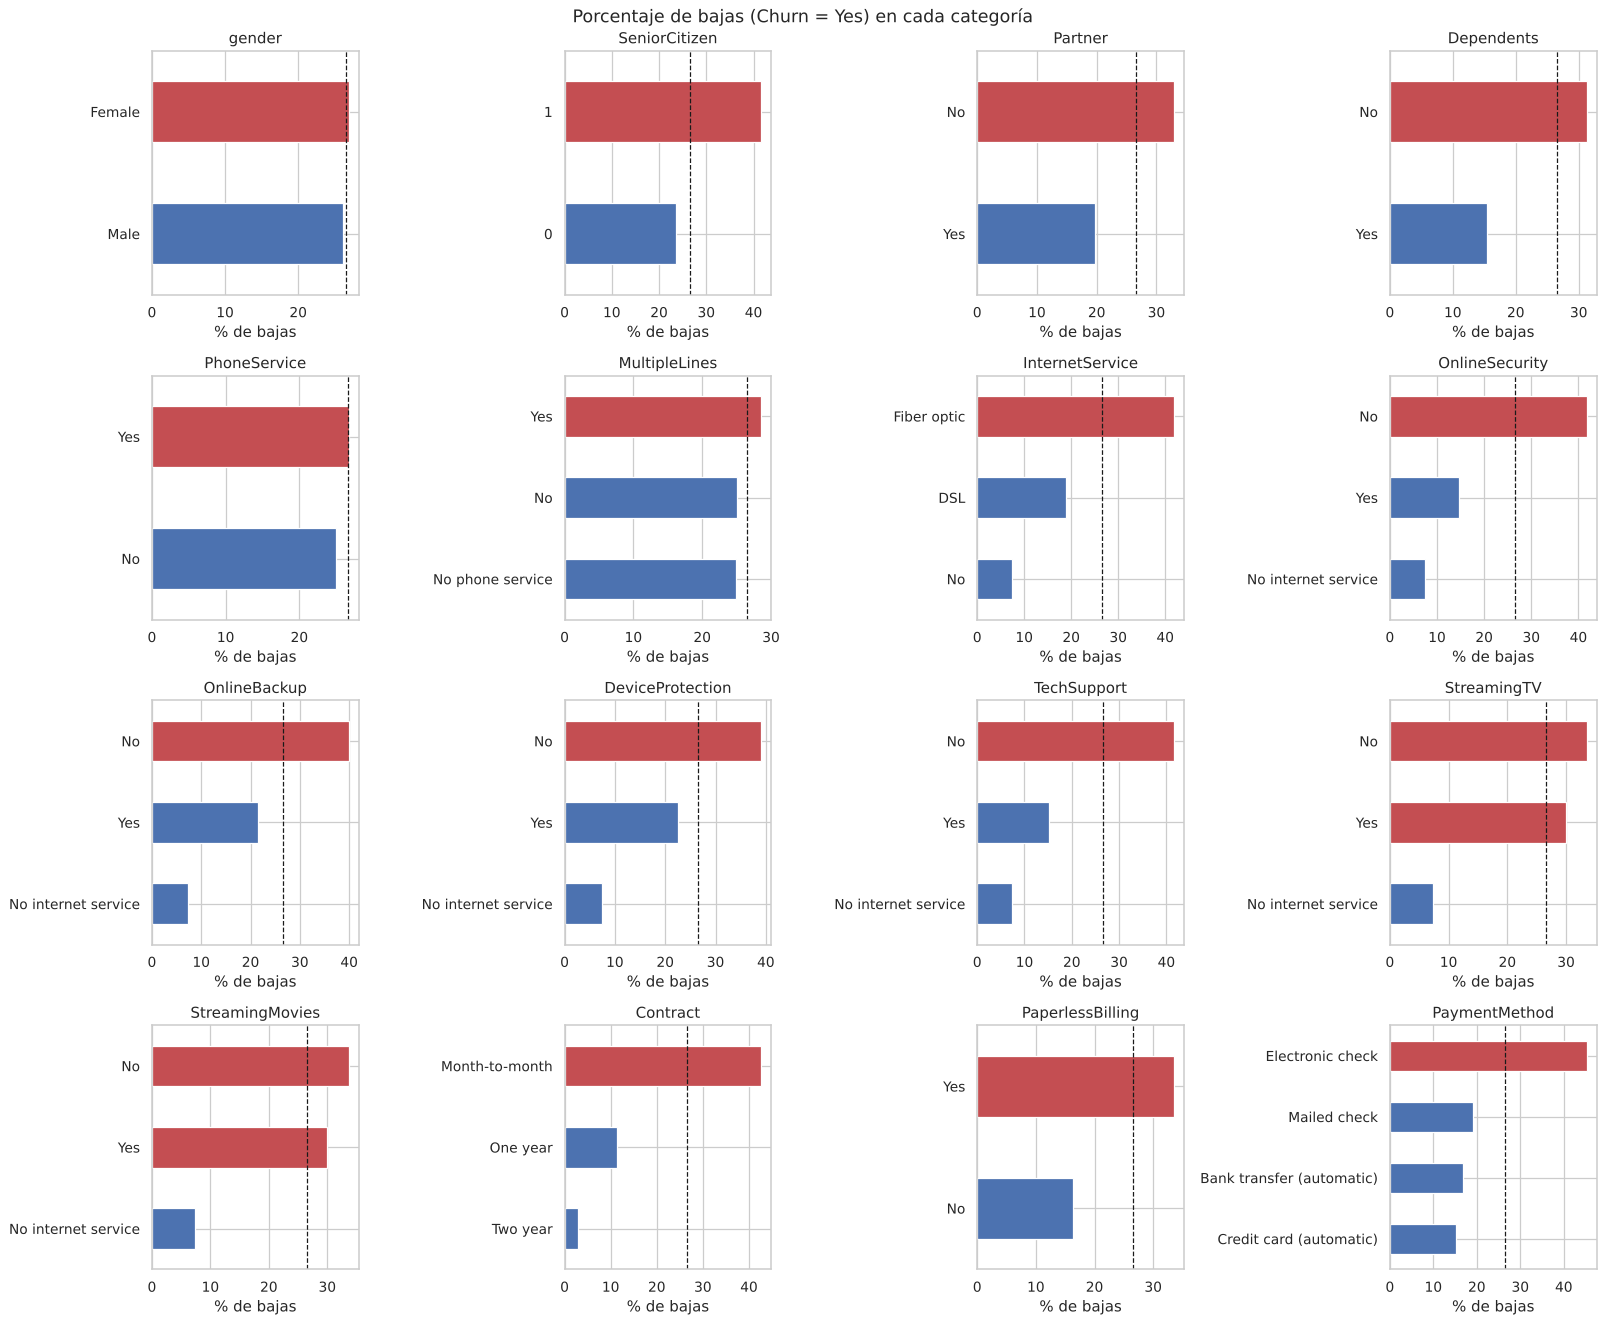

In [10]:
tasa_general = (df_t["Churn"] == "Yes").mean()
fig, axes = plt.subplots(4, 4, figsize=(18, 15))
for ax, col in zip(axes.ravel(), cat_t):
    tasa = df_t.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
    tasa.plot(kind="barh", ax=ax, color=np.where(tasa > tasa_general * 100, "#C44E52", "#4C72B0"))
    ax.axvline(tasa_general * 100, color="k", ls="--", lw=1)
    ax.set_title(col); ax.set_xlabel("% de bajas"); ax.set_ylabel("")
plt.suptitle("Porcentaje de bajas (Churn = Yes) en cada categoría", fontsize=14)
plt.tight_layout(); plt.show()

**Lo que vemos:**
- **`Contract`** es la variable que más discrimina: se va el **43 %** de los clientes con contrato **mes a mes**, contra el 11 % con contrato de 1 año y menos del **3 %** con contrato de 2 años.
- **`InternetService`**: los clientes con **fibra óptica** se van mucho más (42 %) que los de DSL (19 %) o los que no tienen internet (7 %).
- **`PaymentMethod`**: quienes pagan con **cheque electrónico** se van el 45 % de las veces; con pago automático, alrededor del 15-17 %.
- No tener **seguridad online** ni **soporte técnico** también se asocia a más bajas. Los **mayores de 65** se van más (42 % vs. 24 %).
- **`gender`** y **`PhoneService`** casi no cambian la tasa: probablemente no aporten al modelo.

### A2.4 Asimetría

In [11]:
asim_t = df_t[num_t].skew().sort_values(ascending=False)
pd.DataFrame({"asimetría": asim_t,
              "interpretación": np.where(asim_t.abs() > 1, "fuerte", np.where(asim_t.abs() > 0.5, "moderada", "baja"))})

,asimetría,interpretación
TotalCharges,0.962,moderada
tenure,0.240,baja
MonthlyCharges,-0.221,baja


`TotalCharges` tiene **asimetría positiva moderada (0,96)**. `tenure` y `MonthlyCharges` son casi simétricas (aunque, como veremos en los histogramas, **no son normales**: tienen forma de "U" o varios picos).

### A2.5 Histogramas y gráficos de densidad

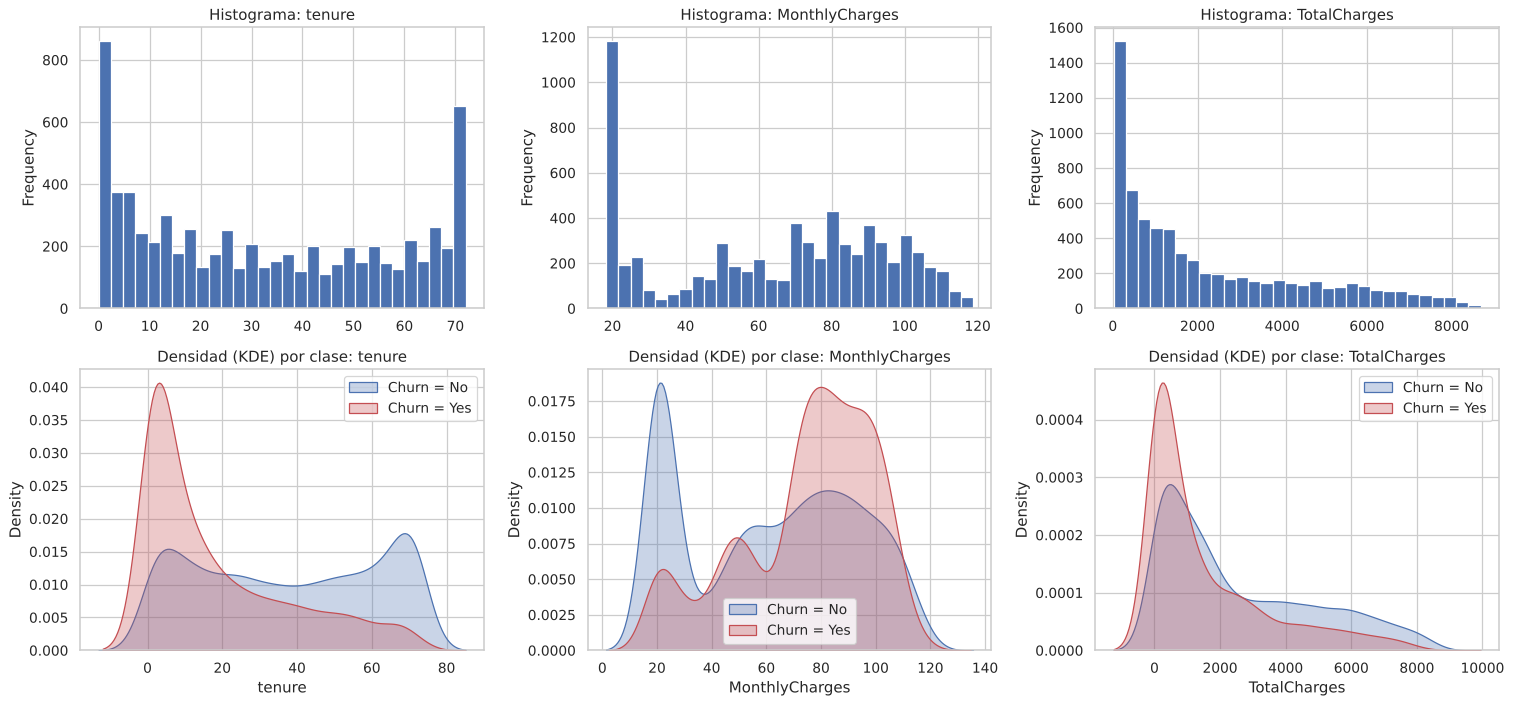

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for i, col in enumerate(num_t):
    df_t[col].plot(kind="hist", bins=30, ax=axes[0, i], color="#4C72B0", edgecolor="white", title=f"Histograma: {col}")
    for clase, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
        sns.kdeplot(df_t.loc[df_t["Churn"] == clase, col], ax=axes[1, i], color=color, fill=True, alpha=.3, label=f"Churn = {clase}")
    axes[1, i].set_title(f"Densidad (KDE) por clase: {col}"); axes[1, i].legend()
plt.tight_layout(); plt.show()

- **`tenure`** tiene forma de **"U"**: muchos clientes nuevos (0-5 meses) y muchos muy antiguos (~70 meses). En el KDE por clase se ve claramente que **las bajas se concentran en los primeros meses**.
- **`MonthlyCharges`** tiene un pico en ~20 USD (clientes sólo con teléfono) y otra zona entre 70 y 100 USD. **Los que se van pagan más por mes.**
- **`TotalCharges`** tiene la cola larga a la derecha; los que se van tienen un total bajo (porque se van temprano).

### A2.6 Boxplots univariables

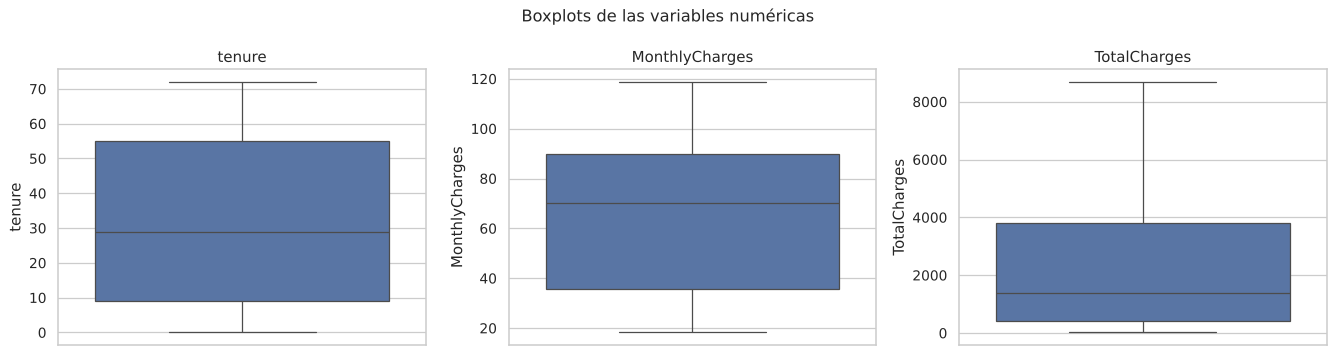

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_t):
    sns.boxplot(y=df_t[col], ax=ax, color="#4C72B0"); ax.set_title(col)
plt.suptitle("Boxplots de las variables numéricas", fontsize=13); plt.tight_layout(); plt.show()

Ninguna de las tres variables numéricas tiene puntos fuera de los bigotes: **no hay valores atípicos** según el criterio del boxplot (lo confirmamos en A2.10).

### A2.7 Matriz de correlación

Para calcular correlaciones con las categóricas, en esta copia exploratoria pasamos las binarias a 0/1 y las de más categorías a variables dummy (la codificación formal está en A3).

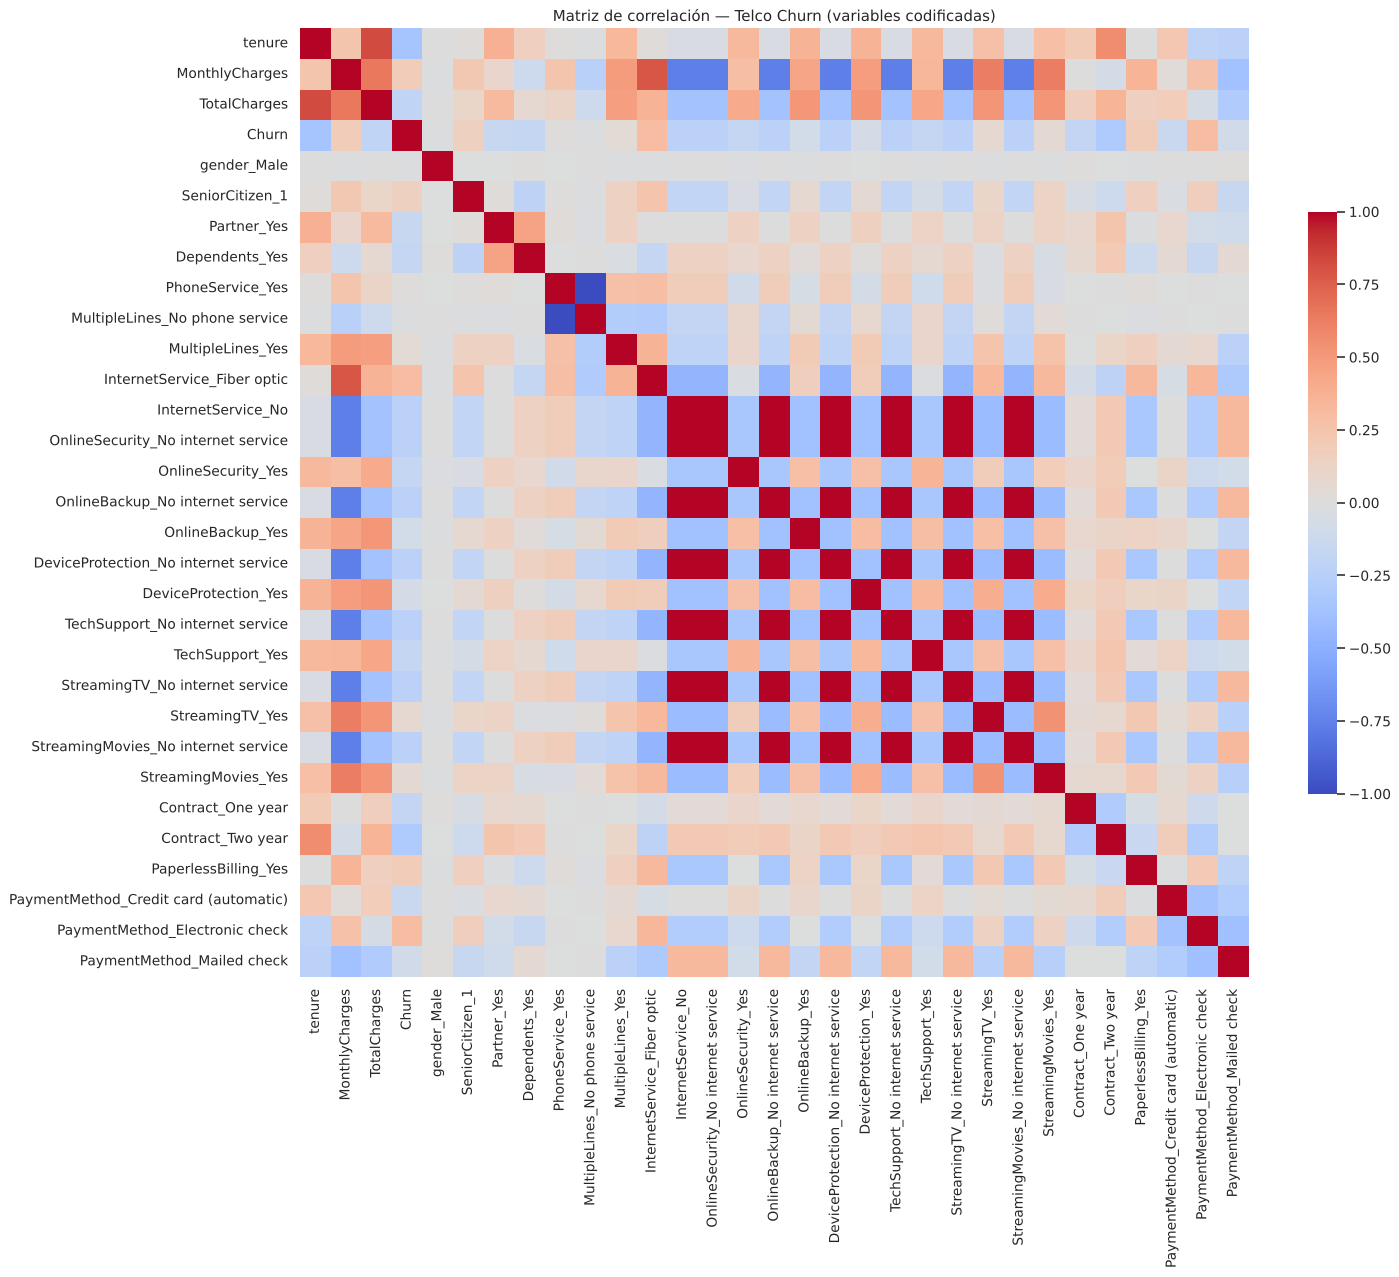

In [14]:
df_t_corr = df_t.drop(columns="customerID").copy()
df_t_corr["Churn"] = (df_t_corr["Churn"] == "Yes").astype(int)
df_t_corr = pd.get_dummies(df_t_corr, columns=cat_t, drop_first=True, dtype=int)
corr_t = df_t_corr.corr()
plt.figure(figsize=(17, 14))
sns.heatmap(corr_t, cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .6})
plt.title("Matriz de correlación — Telco Churn (variables codificadas)"); plt.show()

In [15]:
print("Correlación con Churn (las 12 más fuertes):")
print(corr_t["Churn"].drop("Churn").sort_values(key=abs, ascending=False).head(12).round(3).to_string())
triang_t = corr_t.drop(index="Churn", columns="Churn")
triang_t = triang_t.where(np.triu(np.ones(triang_t.shape), k=1).astype(bool))
print("\nPares de variables con |correlación| > 0.75:")
print(triang_t.stack().loc[lambda s: s.abs() > 0.75].sort_values(key=abs, ascending=False).round(3).to_string())

Correlación con Churn (las 12 más fuertes):
tenure                                 -0.352
InternetService_Fiber optic             0.308
Contract_Two year                      -0.302
PaymentMethod_Electronic check          0.302
InternetService_No                     -0.228
OnlineSecurity_No internet service     -0.228
DeviceProtection_No internet service   -0.228
TechSupport_No internet service        -0.228
StreamingMovies_No internet service    -0.228
StreamingTV_No internet service        -0.228
OnlineBackup_No internet service       -0.228
TotalCharges                           -0.199

Pares de variables con |correlación| > 0.75:
InternetService_No                    DeviceProtection_No internet service    1.000
                                      StreamingTV_No internet service         1.000
                                      TechSupport_No internet service         1.000
                                      OnlineBackup_No internet service        1.000
                      

**Lo que vemos:**
- Las variables que más se relacionan con la baja son **`tenure` (negativa: a más antigüedad, menos bajas)**, el **contrato mes a mes / de 2 años**, la **fibra óptica**, el **cheque electrónico** y **`TotalCharges`**.
- **Multicolinealidad:** aparecen varios pares por encima de 0,75:
  - **`tenure` y `TotalCharges` (0,83)**: es lógico, porque el total facturado es aproximadamente *antigüedad × cargo mensual*. Aportan información repetida.
  - Las columnas "**No internet service**" de los seis servicios de internet están **perfectamente correlacionadas (1,0)** entre sí y con `InternetService_No`: dicen seis veces lo mismo. Lo corregimos en la limpieza (A2.10).
  - `MultipleLines_No phone service` y `PhoneService_Yes` (−1,0): mismo problema.
  - `MonthlyCharges` con `InternetService_Fiber optic` (0,79): la fibra es el servicio más caro.

### A2.8 Matriz de dispersión por clase

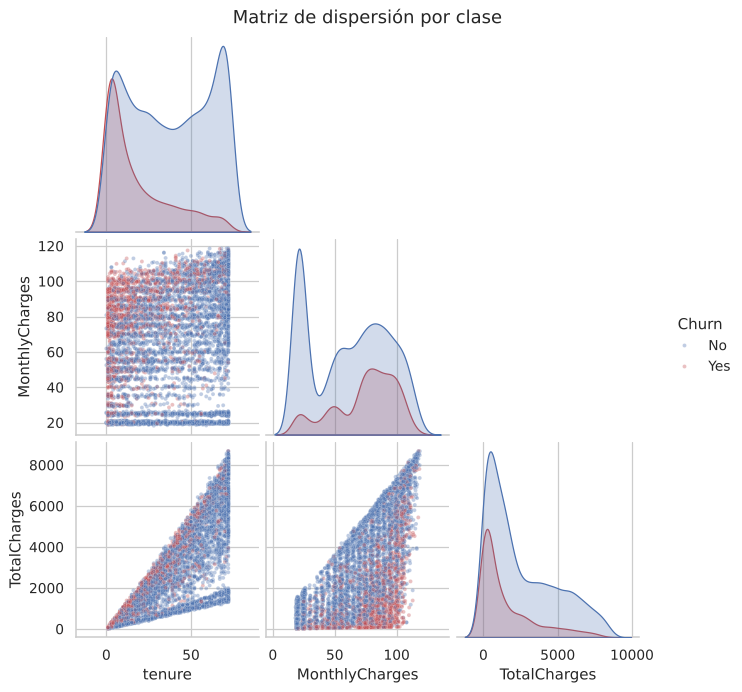

In [16]:
g = sns.pairplot(df_t[num_t + ["Churn"]], hue="Churn", hue_order=["No", "Yes"],
                 palette={"No": "#4C72B0", "Yes": "#C44E52"}, plot_kws={"alpha": 0.35, "s": 10}, diag_kind="kde", corner=True)
g.fig.suptitle("Matriz de dispersión por clase", y=1.02); plt.show()

- En **`tenure` vs `MonthlyCharges`**, las bajas (rojo) se concentran en la zona de **poca antigüedad y cargo mensual alto** (arriba a la izquierda).
- **`tenure` vs `TotalCharges`** muestra la relación casi determinística entre ellas: los puntos forman un "abanico" (el total crece con los meses, a una pendiente que es el cargo mensual).
- Las clases se superponen bastante: ninguna variable numérica sola separa a los que se van.

### A2.9 Boxplots por clase

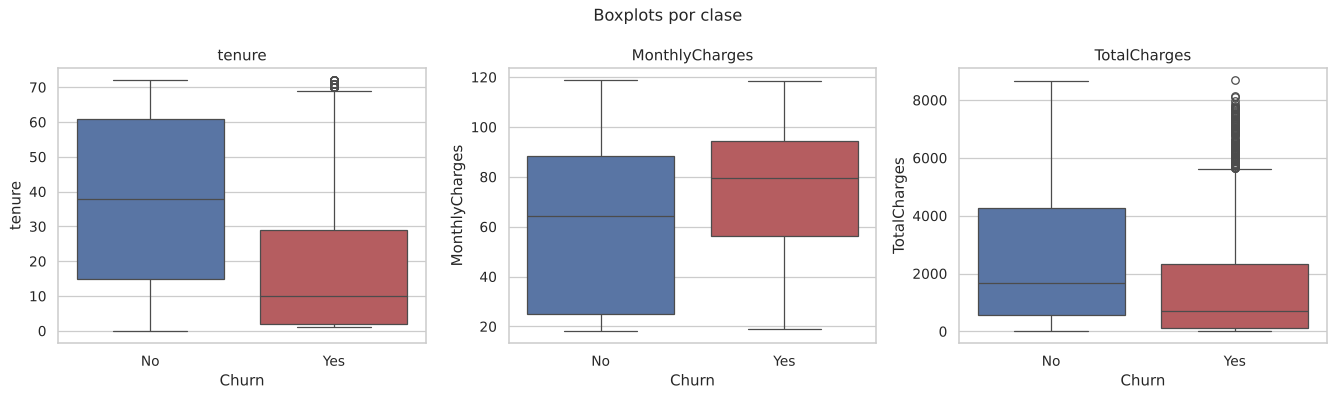

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.4,1683.6
Yes,10.0,79.6,703.6


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, num_t):
    sns.boxplot(data=df_t, x="Churn", y=col, order=["No", "Yes"], ax=ax, palette={"No": "#4C72B0", "Yes": "#C44E52"})
    ax.set_title(col)
plt.suptitle("Boxplots por clase", fontsize=13); plt.tight_layout(); plt.show()
df_t.groupby("Churn")[num_t].median().round(1)

Los clientes que se dan de baja tienen **mediana de antigüedad de 10 meses** (contra 38 de los que se quedan) y **pagan más por mes** (mediana ~80 USD contra ~64). En la clase "Yes", `tenure` y `TotalCharges` muestran varios puntos por encima del bigote: son los pocos clientes antiguos que igual se fueron.

### A2.10 Valores faltantes, duplicados, atípicos e inconsistencias

In [18]:
print("Valores faltantes por columna (sólo las que tienen):")
print(df_t.isna().sum().loc[lambda s: s > 0].to_string())
print("\nFilas duplicadas (con customerID):", df_t.duplicated().sum())
print("Filas duplicadas (sin customerID):", df_t.drop(columns="customerID").duplicated().sum())
print("IDs de cliente repetidos:", df_t["customerID"].duplicated().sum())
print("\nValores atípicos según IQR:")
display(contar_atipicos_iqr(df_t[num_t]))
print("Categorías de cada variable (para detectar inconsistencias):")
for col in cat_t:
    print(f"  {col}: {sorted(df_t[col].astype(str).unique())}")

Valores faltantes por columna (sólo las que tienen):
TotalCharges    11

Filas duplicadas (con customerID): 0
Filas duplicadas (sin customerID): 22
IDs de cliente repetidos: 0

Valores atípicos según IQR:


,atípicos,% del total
tenure,0,0.0
MonthlyCharges,0,0.0
TotalCharges,0,0.0


Categorías de cada variable (para detectar inconsistencias):
  gender: ['Female', 'Male']
  SeniorCitizen: ['0', '1']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


**Diagnóstico y decisiones de limpieza:**

1. **Formato:** `TotalCharges` estaba como texto (ya corregido en A2.1). `customerID` es sólo un identificador: **la eliminamos** porque no aporta información para predecir (y si la dejáramos, el modelo podría "memorizar" clientes).
2. **Faltantes:** 11 valores en `TotalCharges`, todos de clientes con **`tenure = 0`** (recién dados de alta). **Imputamos con 0**: todavía no se les facturó nada, así que el total facturado es 0. Usar la media (~2.283 USD) sería un error de sentido común: le asignaría a un cliente nuevo lo que facturó un cliente promedio en años.
3. **Duplicados:** no hay filas repetidas ni IDs repetidos. Sin contar el ID hay 22 filas iguales, pero **son clientes distintos** (con distinto `customerID`) que casualmente tienen el mismo perfil (por ejemplo, clientes nuevos con el plan más básico). **Los conservamos**: no son errores de carga.
4. **Inconsistencias (categorías redundantes):** en los seis servicios de internet aparece la categoría **"No internet service"**, y en `MultipleLines`, **"No phone service"**. Esa información ya está en `InternetService = No` y en `PhoneService = No`. Las reemplazamos por **"No"** (si no tiene internet, tampoco tiene seguridad online): así esas 7 variables pasan a ser **binarias**, se eliminan las correlaciones perfectas que vimos en A2.7 y el One-Hot genera menos columnas.
5. **Atípicos:** no hay según el criterio IQR. No hace falta tratarlos.

In [19]:
df_t = df_t.drop(columns="customerID")
print(f"TotalCharges faltantes antes: {df_t['TotalCharges'].isna().sum()}")
df_t["TotalCharges"] = df_t["TotalCharges"].fillna(0)
print(f"TotalCharges faltantes después: {df_t['TotalCharges'].isna().sum()}")

servicios_internet = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
print("\nANTES:", df_t["OnlineSecurity"].value_counts().to_dict(), "|", df_t["MultipleLines"].value_counts().to_dict())
df_t[servicios_internet] = df_t[servicios_internet].replace("No internet service", "No")
df_t["MultipleLines"] = df_t["MultipleLines"].replace("No phone service", "No")
print("DESPUÉS:", df_t["OnlineSecurity"].value_counts().to_dict(), "|", df_t["MultipleLines"].value_counts().to_dict())
print("\nDimensiones después de la limpieza:", df_t.shape)

TotalCharges faltantes antes: 11
TotalCharges faltantes después: 0

ANTES: {'No': 3498, 'Yes': 2019, 'No internet service': 1526} | {'No': 3390, 'Yes': 2971, 'No phone service': 682}
DESPUÉS: {'No': 5024, 'Yes': 2019} | {'No': 4072, 'Yes': 2971}

Dimensiones después de la limpieza: (7043, 20)


## A3. Preprocesamiento de datos

### A3.1 Codificación de variables categóricas y de la clase

| Variables | Categorías | Técnica | Motivo |
|---|---|---|---|
| `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, los 6 servicios de internet, `PaperlessBilling` | 2 | **Label Encoding** | Binarias: No → 0, Yes → 1 (Female → 0, Male → 1) |
| `SeniorCitizen` | 2 | — | Ya viene como 0/1 |
| `InternetService`, `Contract`, `PaymentMethod` | 3 o 4 | **One-Hot Encoding** (`drop_first=True`) | Varias categorías; si usáramos 0, 1, 2, 3 el modelo supondría un orden que no existe (por ejemplo, entre formas de pago) |
| **`Churn` (clase)** | 2 | **Label Encoding** | No → 0, **Yes → 1** (la clase positiva es "se da de baja") |

> `Contract` sí tiene un orden natural (mes a mes < 1 año < 2 años) y se podría codificar como 0, 1, 2. Elegimos One-Hot para no suponer que el efecto de pasar de "mes a mes" a "1 año" es el mismo que de "1 año" a "2 años" (el EDA mostró que no lo es: 43 % → 11 % → 3 %).

Label Encoding y One-Hot **no aprenden nada de la variable objetivo**, así que se pueden aplicar antes de dividir sin fuga de datos. Target Encoding sí aprende de la clase: lo mostramos después del split, calculado sólo con train.

In [20]:
binarias_t = [c for c in cat_t if df_t[c].nunique() == 2 and c != "SeniorCitizen"]
multicat_t = [c for c in cat_t if df_t[c].nunique() > 2]
print("Label Encoding:", binarias_t)
print("One-Hot Encoding:", multicat_t)

df_t_cod = df_t.copy()
codigos = {}
for col in binarias_t:
    le_col = LabelEncoder()
    df_t_cod[col] = le_col.fit_transform(df_t_cod[col])
    codigos[col] = dict(zip(le_col.classes_, range(len(le_col.classes_))))
df_t_cod = pd.get_dummies(df_t_cod, columns=multicat_t, drop_first=True, dtype=int)

le_t = LabelEncoder()
df_t_cod["Churn"] = le_t.fit_transform(df_t_cod["Churn"])
print("Clase:", dict(zip(le_t.classes_, range(2))))
print("Ejemplos de códigos:", {k: codigos[k] for k in ["gender", "Partner", "OnlineSecurity"]})

print("\nANTES de codificar:"); display(df_t.head(3))
print("DESPUÉS de codificar:"); display(df_t_cod.head(3))
print("Dimensiones:", df_t.shape, "→", df_t_cod.shape)

Label Encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
One-Hot Encoding: ['InternetService', 'Contract', 'PaymentMethod']
Clase: {'No': 0, 'Yes': 1}
Ejemplos de códigos: {'gender': {'Female': 0, 'Male': 1}, 'Partner': {'No': 0, 'Yes': 1}, 'OnlineSecurity': {'No': 0, 'Yes': 1}}

ANTES de codificar:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


DESPUÉS de codificar:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,1


Dimensiones: (7043, 20) → (7043, 24)


### A3.2 División en entrenamiento y prueba

70 % train / 30 % test, **estratificado** para que las dos partes tengan la misma proporción de bajas. El test no se toca hasta la evaluación final (A7).

In [21]:
X_t = df_t_cod.drop(columns="Churn")
y_t = df_t_cod["Churn"].values
features_t = X_t.columns.tolist()
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.30, random_state=SEED, stratify=y_t)
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"% de bajas → train: {y_train_t.mean():.1%} | test: {y_test_t.mean():.1%}")

Train: (4930, 23) | Test: (2113, 23)
% de bajas → train: 26.5% | test: 26.5%


**Target Encoding (demostración, sólo con train).** Reemplaza cada forma de pago por el **% de bajas de esa forma de pago en train**. Es útil cuando una variable tiene muchas categorías; acá tiene 4, así que nos quedamos con One-Hot, pero mostramos cómo se hace sin filtrar información del test.

In [22]:
pago_train = df_t.loc[X_train_t.index, "PaymentMethod"]
te_pago = pd.Series(y_train_t, index=X_train_t.index).groupby(pago_train).mean()
print("Target Encoding aprendido en train (proporción de bajas por forma de pago):")
print(te_pago.round(3).to_string())
pago_test = df_t.loc[X_test_t.index, "PaymentMethod"]
pd.DataFrame({"PaymentMethod (original)": pago_test.head(6).values,
              "PaymentMethod (target encoding)": pago_test.head(6).map(te_pago).round(3).values})

Target Encoding aprendido en train (proporción de bajas por forma de pago):
PaymentMethod
Bank transfer (automatic)    0.163
Credit card (automatic)      0.147
Electronic check             0.456
Mailed check                 0.195


,PaymentMethod (original),PaymentMethod (target encoding)
0,Electronic check,0.456
1,Mailed check,0.195
2,Electronic check,0.456
3,Mailed check,0.195
4,Mailed check,0.195
5,Bank transfer (automatic),0.163


### A3.3 Comparación de las transformaciones vistas en clase (variables numéricas)

Las transformaciones se aplican a las **3 variables numéricas**; las binarias (0/1) ya están en una escala comparable. Las ajustamos **sólo con train**.

In [23]:
print("¿Hay valores <= 0 en train? (Box-Cox no los acepta)")
print((X_train_t[num_t] <= 0).sum().to_string())

transf_t = {"MinMaxScaler": MinMaxScaler(), "StandardScaler": StandardScaler(), "Normalizer": Normalizer(),
            "Yeo-Johnson": PowerTransformer(method="yeo-johnson", standardize=False)}
filas = [{"transformación": "Original", **{f"{c} media": X_train_t[c].mean() for c in num_t},
          **{f"{c} asim.": X_train_t[c].skew() for c in num_t}}]
for nombre, t in transf_t.items():
    Xt = pd.DataFrame(t.fit_transform(X_train_t[num_t]), columns=num_t)
    filas.append({"transformación": nombre, **{f"{c} media": Xt[c].mean() for c in num_t}, **{f"{c} asim.": Xt[c].skew() for c in num_t}})
try:
    PowerTransformer(method="box-cox").fit(X_train_t[num_t])
except ValueError as e:
    print("\nBox-Cox falla:", str(e)[:90], "...")
display(pd.DataFrame(filas).set_index("transformación").round(3))

# Binarización: ¿el cliente tiene menos de 12 meses de antigüedad?
binz = Binarizer(threshold=12)
nuevo = pd.DataFrame({"tenure": X_train_t["tenure"].values[:8],
                      "tenure > 12 meses (Binarizer)": binz.fit_transform(X_train_t[["tenure"]])[:8].ravel()})
print("Ejemplo de binarización de tenure (umbral 12 meses):"); display(nuevo)
print("Tasa de baja en train según la binarización:")
print(pd.Series(y_train_t).groupby(binz.transform(X_train_t[["tenure"]]).ravel()).mean().rename({0: "hasta 12 meses", 1: "más de 12 meses"}).round(3).to_string())

¿Hay valores <= 0 en train? (Box-Cox no los acepta)
tenure            7
MonthlyCharges    0
TotalCharges      7



Box-Cox falla: The Box-Cox transformation can only be applied to strictly positive data ...


,tenure media,MonthlyCharges media,TotalCharges media,tenure asim.,MonthlyCharges asim.,TotalCharges asim.
transformación,,,,,,
Original,32.471,64.950,2301.798,0.240,-0.220,0.950
MinMaxScaler,0.451,0.464,0.265,0.240,-0.220,0.950
StandardScaler,0.000,0.000,-0.000,0.240,-0.220,0.950
Normalizer,0.021,0.130,0.965,1.213,2.104,-3.722
Yeo-Johnson,7.484,50.263,20.574,-0.242,-0.260,-0.145


Ejemplo de binarización de tenure (umbral 12 meses):


,tenure,tenure > 12 meses (Binarizer)
0,5,0
1,3,0
2,3,0
3,60,1
4,12,0
5,65,1
6,18,1
7,8,0


Tasa de baja en train según la binarización:
hasta 12 meses     0.477
más de 12 meses    0.169


**Conclusiones de la comparación:**
- **MinMaxScaler** y **StandardScaler** cambian la escala pero no la forma (la asimetría de `TotalCharges` sigue en ~0,96).
- **Normalizer** trabaja por fila: como `TotalCharges` (miles) es mucho más grande que las otras, cada fila queda dominada por ella. **No tiene sentido** acá.
- **Box-Cox no se puede aplicar**: `tenure` y `TotalCharges` tienen ceros (los clientes nuevos).
- **Yeo-Johnson** acepta ceros y corrige la asimetría de `TotalCharges`.
- **Binarizer** es útil para **interpretar** (los clientes con hasta 12 meses se van ~3 veces más), pero pierde información para el modelo: no la usamos como transformación principal.

**Transformación elegida:** 1º **Yeo-Johnson** → 2º **estandarización**, sobre las 3 numéricas. Es el mismo orden que pide la consigna (primero corregir la forma, después la escala); estandarizar primero generaría valores negativos y la corrección se calcularía sobre datos ya modificados.

### A3.4 Aplicación de la transformación elegida (ajustada sólo con train)

Como sólo transformamos algunas columnas, usamos `make_column_transformer`: aplica `PowerTransformer()` (que por defecto hace Yeo-Johnson + estandarización) a las numéricas y deja pasar las demás sin cambios (`remainder="passthrough"`).

In [24]:
from sklearn.compose import make_column_transformer

def preproc_t(columnas=None):
    """Yeo-Johnson + estandarización sólo en las numéricas presentes; el resto pasa igual."""
    cols = num_t if columnas is None else [c for c in num_t if c in columnas]
    return make_column_transformer((PowerTransformer(), cols), remainder="passthrough", verbose_feature_names_out=False)

prep = preproc_t().set_output(transform="pandas")
X_train_t_tr = prep.fit_transform(X_train_t)[features_t]     # fit SÓLO con train
X_test_t_tr = prep.transform(X_test_t)[features_t]           # transform en test

print("ANTES (train):"); display(X_train_t[num_t + ["Contract_Two year", "OnlineSecurity"]].head())
print("DESPUÉS (train):"); display(X_train_t_tr[num_t + ["Contract_Two year", "OnlineSecurity"]].head())
pd.DataFrame({"media antes": X_train_t[num_t].mean(), "desvío antes": X_train_t[num_t].std(), "asim. antes": X_train_t[num_t].skew(),
              "media después": X_train_t_tr[num_t].mean(), "desvío después": X_train_t_tr[num_t].std(), "asim. después": X_train_t_tr[num_t].skew(),
              "media test después": X_test_t_tr[num_t].mean()}).round(3)

ANTES (train):


,tenure,MonthlyCharges,TotalCharges,Contract_Two year,OnlineSecurity
5557,5,80.20,384.25,0,0
2270,3,86.85,220.95,0,0
6930,3,75.15,216.75,0,0
2257,60,80.55,4847.05,0,0
898,12,98.90,1120.95,0,1


DESPUÉS (train):


,tenure,MonthlyCharges,TotalCharges,Contract_Two year,OnlineSecurity
5557,-1.171,0.515,-0.798,0,0
2270,-1.375,0.728,-1.074,0,0
6930,-1.375,0.352,-1.083,0,0
2257,1.050,0.526,1.103,0,0
898,-0.666,1.112,-0.140,0,1


,media antes,desvío antes,asim. antes,media después,desvío después,asim. después,media test después
tenure,32.471,24.646,0.24,0.0,1.0,-0.242,-0.011
MonthlyCharges,64.950,30.244,-0.22,0.0,1.0,-0.260,-0.020
TotalCharges,2301.798,2292.566,0.95,0.0,1.0,-0.145,-0.017


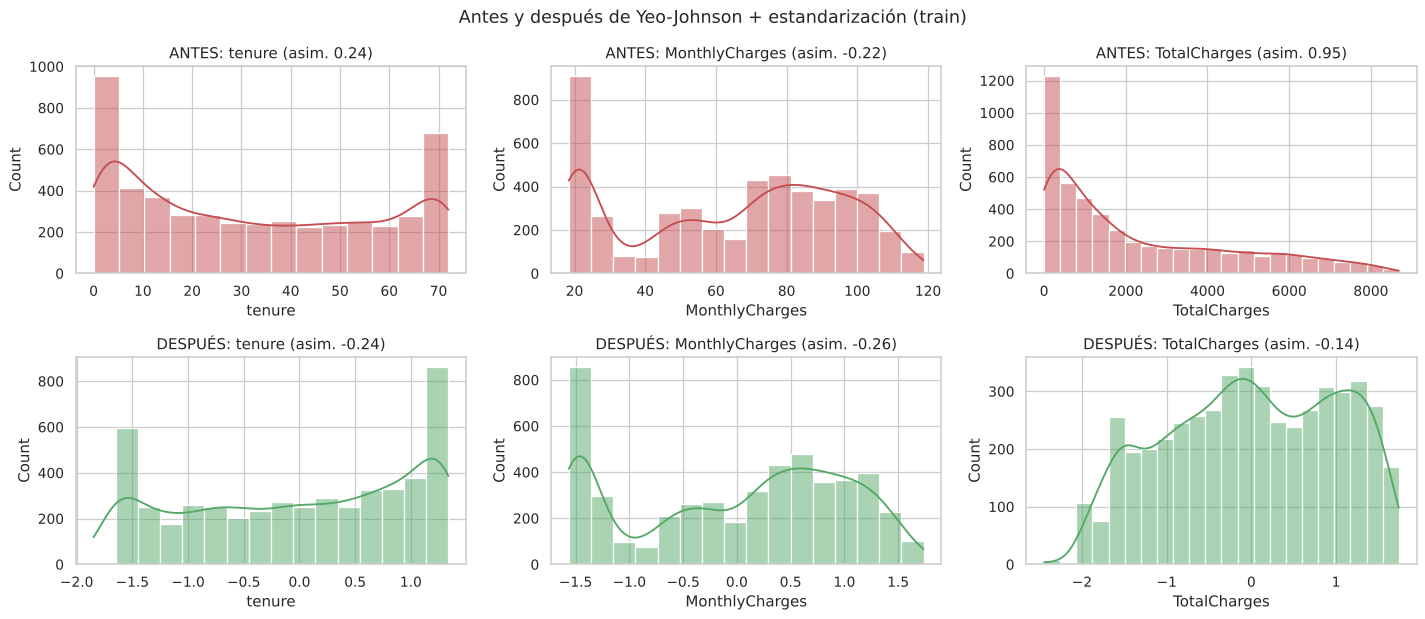

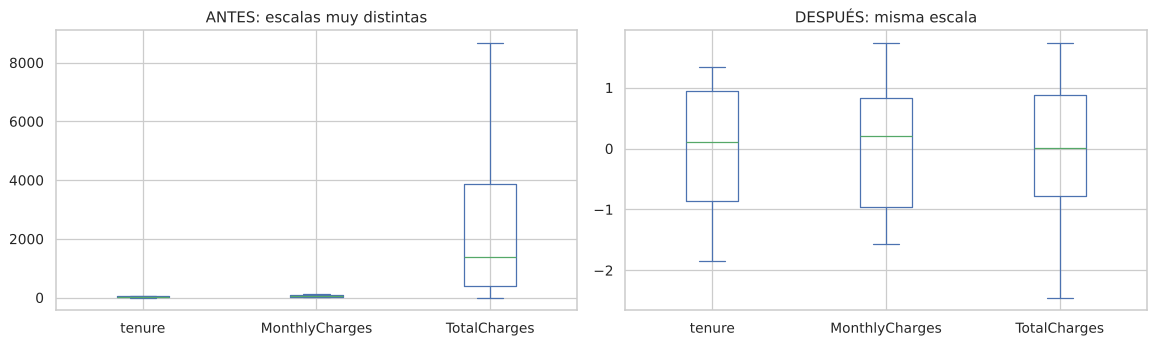

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for i, col in enumerate(num_t):
    sns.histplot(X_train_t[col], kde=True, ax=axes[0, i], color="#C44E52")
    axes[0, i].set_title(f"ANTES: {col} (asim. {X_train_t[col].skew():.2f})")
    sns.histplot(X_train_t_tr[col], kde=True, ax=axes[1, i], color="#55A868")
    axes[1, i].set_title(f"DESPUÉS: {col} (asim. {X_train_t_tr[col].skew():.2f})")
plt.suptitle("Antes y después de Yeo-Johnson + estandarización (train)", fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
X_train_t[num_t].plot(kind="box", ax=axes[0], title="ANTES: escalas muy distintas")
X_train_t_tr[num_t].plot(kind="box", ax=axes[1], title="DESPUÉS: misma escala")
plt.tight_layout(); plt.show()

**Resultado:** las tres variables quedaron con media 0 y desvío 1, y la asimetría de `TotalCharges` bajó casi a 0. En `tenure` y `MonthlyCharges` la forma bimodal (dos picos) se mantiene: **ninguna transformación puede convertir una distribución con dos picos en una campana**, porque los dos grupos de clientes existen realmente. En test la media no da exactamente 0 porque se usaron los parámetros de train: no hubo fuga de información.

> En la validación cruzada usamos un **Pipeline** (`make_pipeline(preproc_t(), modelo)`), para que la transformación se reajuste en cada fold sólo con la parte de entrenamiento.

## A4. Selección de características y reducción de dimensiones

Tenemos **23 variables** después de codificar. Siguiendo las **nuevas consignas** del TP:

1. Revisamos primero la **redundancia** entre variables (A4.1, análisis exploratorio que ya veníamos haciendo).
2. Aplicamos **una técnica de Feature Selection: RFE** (eliminación recursiva de características) con regresión logística (A4.2). En la regresión (parte B) usamos una técnica **distinta**: la importancia de variables con Random Forest.
3. Aplicamos **PCA** sobre las **23 variables del modelo base**, de manera **independiente** de RFE: PCA no se aplica sobre las variables que eligió RFE (A4.3).
4. Comparamos con validación cruzada las **tres alternativas**: el **modelo base** (todas las variables), el modelo con las **variables elegidas por RFE** y el modelo con **PCA** (A4.4). La comparación en test se hace recién en A7.

Todo se ajusta **sólo con train**.

### A4.1 Variables muy correlacionadas entre sí

In [26]:
corr_train_t = X_train_t.corr()
triang = corr_train_t.where(np.triu(np.ones(corr_train_t.shape), k=1).astype(bool))
print("Pares con |correlación| > 0.75 (después de la limpieza):")
print(triang.stack().loc[lambda s: s.abs() > 0.75].round(3).to_string())
print("\nCorrelación de cada una con la clase (train):")
print(X_train_t[["tenure", "TotalCharges", "MonthlyCharges"]].corrwith(pd.Series(y_train_t, index=X_train_t.index)).round(3).to_string())

Pares con |correlación| > 0.75 (después de la limpieza):
tenure          TotalCharges                   0.830
MonthlyCharges  InternetService_Fiber optic    0.789
                InternetService_No            -0.762

Correlación de cada una con la clase (train):
tenure           -0.344
TotalCharges     -0.190
MonthlyCharges    0.200


Después de la limpieza de A2.10 desaparecieron las correlaciones perfectas entre los servicios. Quedan dos pares por encima de 0,75:
- **`tenure` – `TotalCharges` (0,83)**: de cada par muy correlacionado conviene quedarse con una sola. Nos quedamos con **`tenure`**, porque está **más correlacionada con la clase** (−0,35 contra −0,20) y es más fácil de interpretar. Candidata a eliminar: **`TotalCharges`**.
- **`MonthlyCharges` con `InternetService_Fiber optic` (0,79) y con `InternetService_No` (−0,76)**: el tipo de internet explica gran parte del cargo mensual (la fibra es lo más caro; no tener internet, lo más barato). Pero cada una tiene información propia (el cargo también depende de los servicios adicionales y el tipo de internet refleja la calidad del servicio), así que no descartamos ninguna con este criterio.

### A4.2 Técnica de Feature Selection elegida: RFE (*Recursive Feature Elimination*)

**Cómo funciona:** entrena un modelo con todas las variables, elimina la **menos importante** (en la regresión logística, la de coeficiente más chico en valor absoluto) y repite hasta quedarse con la cantidad pedida. Es un método **envolvente** (*wrapper*): elige las variables según cuánto le sirven a un modelo concreto, y no de a una por separado como chi² o ANOVA.

**Por qué la elegimos:** la regresión logística es un modelo natural para este problema (clase binaria, variables mayormente 0/1) y RFE la usa directamente para decidir. Como las numéricas tienen escalas distintas, RFE se aplica sobre los datos **transformados** (Yeo-Johnson + estandarización): si no, los coeficientes no serían comparables entre sí.

**¿Cuántas variables conservar?** RFE necesita que le indiquemos el número. En lugar de elegirlo "a ojo", probamos **de 1 a 23** con validación cruzada (K-Fold estratificado, k=10) y medimos el AUC. RFE va **dentro del Pipeline**: en cada fold elige las variables usando sólo la parte de entrenamiento de ese fold, sin espiar la de validación.


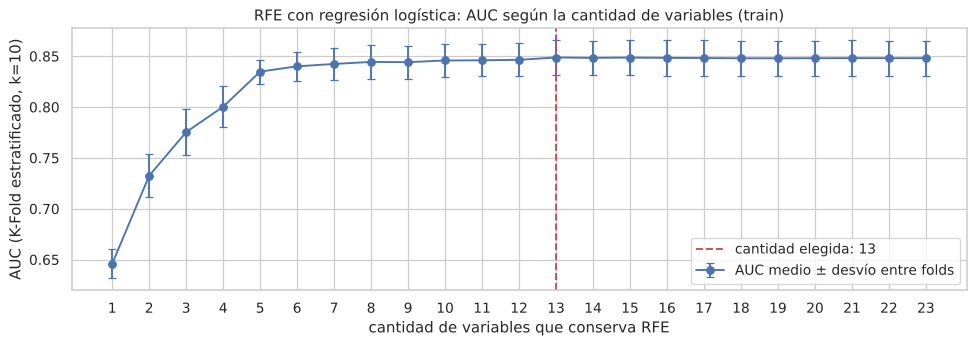

variables     1      2      3     4      5      6      7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22     23
AUC medio  0.646  0.733  0.775  0.80  0.835  0.840  0.842  0.844  0.844  0.846  0.846  0.847  0.849  0.848  0.849  0.848  0.848  0.848  0.848  0.848  0.848  0.848  0.848
desvío     0.014  0.021  0.023  0.02  0.012  0.014  0.015  0.017  0.016  0.016  0.016  0.016  0.017  0.017  0.018  0.018  0.017  0.017  0.017  0.017  0.017  0.017  0.017

Mejor AUC: 0.8487 con 13 variables
Elegimos 13 variables (AUC 0.8487): la menor cantidad a menos de 0.002 del mejor AUC


In [27]:
cv_t = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

n_vars_t = list(range(1, len(features_t) + 1))
auc_n_t, desv_n_t = [], []
for n in n_vars_t:
    pipe = make_pipeline(preproc_t(), RFE(LogisticRegression(max_iter=2000), n_features_to_select=n),
                         LogisticRegression(max_iter=2000))
    r = cross_val_score(pipe, X_train_t, y_train_t, cv=cv_t, scoring="roc_auc")
    auc_n_t.append(r.mean()); desv_n_t.append(r.std())
auc_n_t, desv_n_t = np.array(auc_n_t), np.array(desv_n_t)

# Criterio: la menor cantidad de variables cuyo AUC queda a menos de 0,002 del mejor
TOL_AUC = 0.002
n_rfe_t = n_vars_t[int(np.argmax(auc_n_t >= auc_n_t.max() - TOL_AUC))]

plt.figure(figsize=(11, 4))
plt.errorbar(n_vars_t, auc_n_t, yerr=desv_n_t, marker="o", capsize=3, label="AUC medio ± desvío entre folds")
plt.axvline(n_rfe_t, ls="--", color="#C44E52", label=f"cantidad elegida: {n_rfe_t}")
plt.xticks(n_vars_t); plt.xlabel("cantidad de variables que conserva RFE"); plt.ylabel("AUC (K-Fold estratificado, k=10)")
plt.title("RFE con regresión logística: AUC según la cantidad de variables (train)"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(pd.DataFrame({"AUC medio": auc_n_t, "desvío": desv_n_t}, index=pd.Index(n_vars_t, name="variables")).round(4).T.to_string())
print(f"\nMejor AUC: {auc_n_t.max():.4f} con {n_vars_t[int(auc_n_t.argmax())]} variables")
print(f"Elegimos {n_rfe_t} variables (AUC {auc_n_t[n_rfe_t - 1]:.4f}): la menor cantidad a menos de {TOL_AUC} del mejor AUC")

In [28]:
# RFE final con la cantidad elegida, ajustado con TODO train (datos transformados de A3.4)
rfe_t = RFE(LogisticRegression(max_iter=2000), n_features_to_select=n_rfe_t).fit(X_train_t_tr, y_train_t)
sel_rfe_t = [f for f, s in zip(features_t, rfe_t.support_) if s]
descartadas_t = [f for f in features_t if f not in sel_rfe_t]

coef_todas_t = LogisticRegression(max_iter=2000).fit(X_train_t_tr, y_train_t).coef_[0]
ranking_t = pd.DataFrame({"ranking RFE (1 = se conserva)": rfe_t.ranking_,
                          "coef. LoR con las 23 variables": coef_todas_t},
                         index=features_t).sort_values("ranking RFE (1 = se conserva)")

print(f"RFE conserva {len(sel_rfe_t)} de {len(features_t)} variables:", sel_rfe_t)
print(f"\nDescarta ({len(descartadas_t)}), en el orden en que las eliminó (la primera es la menos útil):")
print(ranking_t.index[::-1][:len(descartadas_t)].tolist())
ranking_t.round(3)

RFE conserva 13 de 23 variables: ['Dependents', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check']

Descarta (10), en el orden en que las eliminó (la primera es la menos útil):
['Partner', 'gender', 'PaymentMethod_Credit card (automatic)', 'DeviceProtection', 'PaymentMethod_Mailed check', 'OnlineBackup', 'MonthlyCharges', 'tenure', 'PhoneService', 'SeniorCitizen']


,ranking RFE (1 = se conserva),coef. LoR con las 23 variables
Dependents,1,-0.257
OnlineSecurity,1,-0.306
MultipleLines,1,0.449
TotalCharges,1,-1.059
StreamingMovies,1,0.429
PaperlessBilling,1,0.422
TechSupport,1,-0.250
StreamingTV,1,0.327
Contract_Two year,1,-1.522
Contract_One year,1,-0.715


**Lectura:**
- Con pocas variables el AUC sube rápido (de 0,65 con 1 variable a 0,835 con 5) y después **se estabiliza**: a partir de ~8 variables las diferencias son de milésimas, mucho menores que el desvío entre folds (~0,017).
- El mejor AUC (0,849) se alcanza con **13 variables**; agregar las 10 restantes no mejora nada. Por eso **RFE conserva 13 de las 23**.
- Las primeras que descarta son `Partner` y `gender` (que en el EDA no cambiaba la tasa de baja). Conserva las que el EDA mostró como clave: **tipo de contrato**, **fibra óptica**, **pago con cheque electrónico**, **seguridad online** y **soporte técnico**.
- Llama la atención que descarte `tenure` y `MonthlyCharges` y conserve `TotalCharges`, al revés de lo que habíamos razonado en A4.1. Las tres están muy relacionadas (`TotalCharges` ≈ `tenure` × `MonthlyCharges`), y junto con el tipo de contrato y de internet el modelo ya tiene casi toda esa información. Es un rasgo típico de RFE: entre variables redundantes se queda con una, aunque no siempre sea la más fácil de interpretar.

### A4.3 PCA sobre las variables del modelo base

**PCA** (*Análisis de Componentes Principales*) no elige variables: crea **variables nuevas** (componentes), que son combinaciones de todas las originales, ordenadas según cuánta varianza de los datos explica cada una. Sirve para **reducir dimensiones** conservando la mayor parte de la información.

Lo aplicamos sobre las **23 variables del modelo base**, ya transformadas en A3.4 (las numéricas con Yeo-Johnson + estandarización, para que ninguna domine sólo por estar en una escala más grande), y **no** sobre las variables elegidas por RFE, como pide la consigna. Conservamos la cantidad de componentes que explica el **90 % de la varianza**.

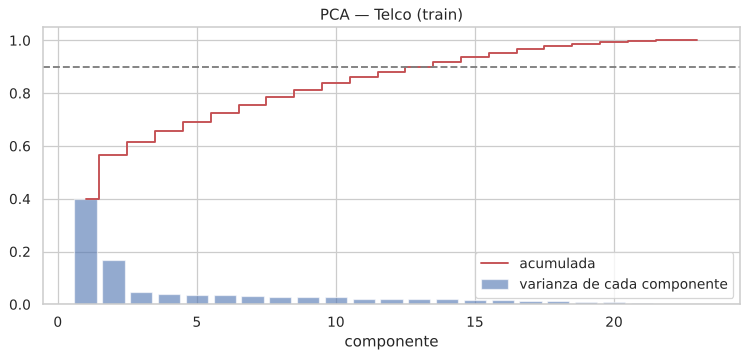

Componentes para explicar el 90 % de la varianza: 13 de 23


In [29]:
pca_t = PCA().fit(X_train_t_tr)
var_acum_t = np.cumsum(pca_t.explained_variance_ratio_)
n90_t = int(np.argmax(var_acum_t >= 0.90) + 1)
plt.figure(figsize=(10, 4))
plt.bar(range(1, len(var_acum_t) + 1), pca_t.explained_variance_ratio_, alpha=.6, label="varianza de cada componente")
plt.step(range(1, len(var_acum_t) + 1), var_acum_t, where="mid", color="#C44E52", label="acumulada")
plt.axhline(0.9, ls="--", color="gray"); plt.legend(); plt.xlabel("componente"); plt.title("PCA — Telco (train)"); plt.show()
print(f"Componentes para explicar el 90 % de la varianza: {n90_t} de {len(features_t)}")

Variables que más pesan en las dos primeras componentes (cargas):


,PC1,PC2
TotalCharges,0.573,-0.205
tenure,0.468,-0.540
MonthlyCharges,0.467,0.549
StreamingMovies,0.176,0.122
StreamingTV,0.175,0.131
DeviceProtection,0.164,0.034
MultipleLines,0.154,0.062
OnlineBackup,0.153,0.020


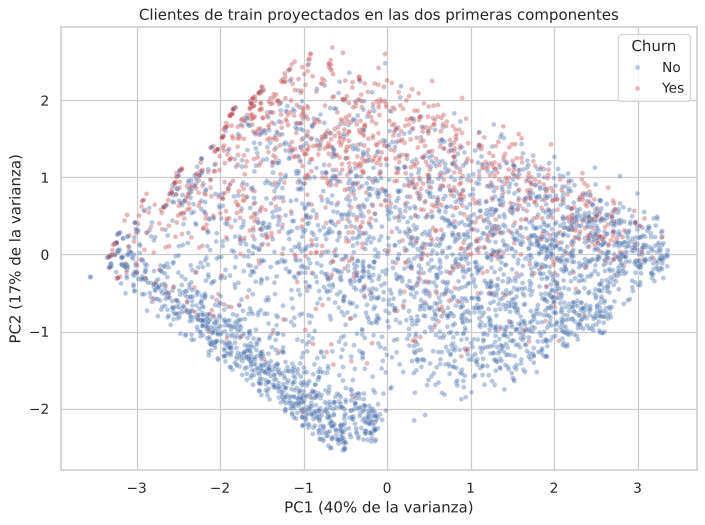

In [30]:
cargas_t = pd.DataFrame(pca_t.components_[:2].T, index=features_t, columns=["PC1", "PC2"])
print("Variables que más pesan en las dos primeras componentes (cargas):")
display(cargas_t.reindex(cargas_t["PC1"].abs().sort_values(ascending=False).index).head(8).round(3))

proy_t = pca_t.transform(X_train_t_tr)[:, :2]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proy_t[:, 0], y=proy_t[:, 1], hue=np.where(y_train_t == 1, "Yes", "No"), hue_order=["No", "Yes"],
                palette={"No": "#4C72B0", "Yes": "#C44E52"}, alpha=.4, s=15)
plt.xlabel(f"PC1 ({pca_t.explained_variance_ratio_[0]:.0%} de la varianza)")
plt.ylabel(f"PC2 ({pca_t.explained_variance_ratio_[1]:.0%} de la varianza)")
plt.title("Clientes de train proyectados en las dos primeras componentes"); plt.legend(title="Churn"); plt.tight_layout(); plt.show()

**Lectura:**
- Hacen falta **13 componentes** para explicar el 90 % de la varianza (de 23 variables): la reducción es moderada, porque muchas variables 0/1 (servicios, forma de pago) aportan información propia y no están muy correlacionadas entre sí.
- La **primera componente** (40 % de la varianza) está dominada por las tres numéricas (`TotalCharges`, `tenure`, `MonthlyCharges`): resume "cuánto y hace cuánto paga el cliente". La **segunda** contrapone `MonthlyCharges` (+) con `tenure` (−): de un lado los clientes nuevos con cargos altos, del otro los antiguos con cargos bajos.
- En el gráfico, las bajas (rojo) se concentran arriba (PC2 positiva: **poca antigüedad y cargo mensual alto**, el perfil de riesgo del EDA), pero se superponen bastante con los clientes que se quedan: dos componentes no alcanzan para separar las clases.
- Desventaja de PCA: cada componente **mezcla todas las variables**, así que se pierde la interpretación ("contrato de 2 años" deja de ser una columna).

### A4.4 Comparación de las tres alternativas (validación cruzada en train)

Evaluamos los seis algoritmos de clasificación de la clase 29-30 con K-Fold estratificado (k=10) en tres alternativas, y agregamos una cuarta columna para decidir qué hacer con `TotalCharges` (A4.1):

| Alternativa | Variables que recibe el modelo |
|---|---|
| **1. Modelo base** | Las 23 variables originales (codificadas) |
| **2. Feature Selection (RFE)** | Sólo las variables que conservó RFE en A4.2 |
| **3. PCA** | Las componentes principales calculadas sobre las 23 variables del modelo base |
| *Base sin `TotalCharges`* | *Las 22 variables, sin la redundante* |

En todos los casos la transformación (y PCA, cuando corresponde) va **dentro del Pipeline**, así que se reajusta en cada fold sólo con su parte de entrenamiento.

AUC medio (K-Fold estratificado, k=10, train):


,1. Base (23 var.),2. RFE (13 var.),3. PCA (13 comp.),Base sin TotalCharges (22 var.)
LoR,0.848,0.849,0.841,0.847
LDA,0.845,0.846,0.840,0.843
KNN,0.789,0.785,0.784,0.783
NB,0.835,0.834,0.835,0.831
CART,0.658,0.668,0.649,0.652
SVM,0.800,0.790,0.803,0.800


F1 de la clase 'Yes' (K-Fold estratificado, k=10, train):


,1. Base (23 var.),2. RFE (13 var.),3. PCA (13 comp.),Base sin TotalCharges (22 var.)
LoR,0.594,0.595,0.572,0.600
LDA,0.596,0.598,0.588,0.598
KNN,0.558,0.541,0.539,0.555
NB,0.626,0.621,0.612,0.622
CART,0.497,0.509,0.484,0.487
SVM,0.563,0.576,0.565,0.567


Desvío típico del AUC entre folds: 0.019


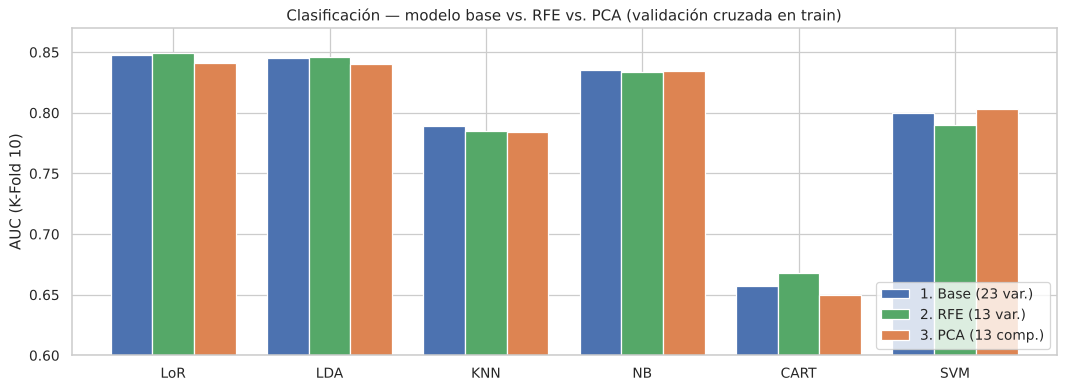

In [31]:
def clasificadores_base_t():
    return {"LoR": LogisticRegression(max_iter=2000), "LDA": LinearDiscriminantAnalysis(),
            "KNN": KNeighborsClassifier(), "NB": GaussianNB(),
            "CART": DecisionTreeClassifier(random_state=SEED), "SVM": SVC()}

def armar_clf(modelo, columnas, n_comp=None):
    """Transformación de A3.4 (+ PCA si se pide) + modelo, todo en un Pipeline."""
    pasos = [preproc_t(columnas)] + ([PCA(n_components=n_comp)] if n_comp else []) + [modelo]
    return make_pipeline(*pasos)

alternativas_t = {f"1. Base ({len(features_t)} var.)": (features_t, None),
                  f"2. RFE ({len(sel_rfe_t)} var.)": (sel_rfe_t, None),
                  f"3. PCA ({n90_t} comp.)": (features_t, n90_t),
                  f"Base sin TotalCharges ({len(features_t) - 1} var.)": ([f for f in features_t if f != "TotalCharges"], None)}

auc_alt_t, f1_alt_t, desv_alt_t = {}, {}, {}
for alt, (cols, n_comp) in alternativas_t.items():
    auc_alt_t[alt], f1_alt_t[alt], desv_alt_t[alt] = {}, {}, {}
    for nombre, modelo in clasificadores_base_t().items():
        r = cross_validate(armar_clf(modelo, cols, n_comp), X_train_t[cols], y_train_t, cv=cv_t, scoring=["roc_auc", "f1"])
        auc_alt_t[alt][nombre] = r["test_roc_auc"].mean(); desv_alt_t[alt][nombre] = r["test_roc_auc"].std()
        f1_alt_t[alt][nombre] = r["test_f1"].mean()
auc_alt_t, f1_alt_t, desv_alt_t = pd.DataFrame(auc_alt_t), pd.DataFrame(f1_alt_t), pd.DataFrame(desv_alt_t)

print("AUC medio (K-Fold estratificado, k=10, train):"); display(auc_alt_t.round(3))
print("F1 de la clase 'Yes' (K-Fold estratificado, k=10, train):"); display(f1_alt_t.round(3))
print(f"Desvío típico del AUC entre folds: {desv_alt_t.values.mean():.3f}")

tres_t = list(alternativas_t)[:3]
ax = auc_alt_t[tres_t].plot(kind="bar", figsize=(12, 4.5), color=["#4C72B0", "#55A868", "#DD8452"], width=0.8)
ax.set_ylim(0.6, 0.87); ax.set_ylabel("AUC (K-Fold 10)"); ax.set_xlabel("")
ax.set_title("Clasificación — modelo base vs. RFE vs. PCA (validación cruzada en train)")
ax.legend(loc="lower right"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Decisión:**
- **Modelo base vs. RFE:** con 13 variables, RFE logra **prácticamente el mismo rendimiento** que el modelo base con 23 (regresión logística: AUC 0,849 vs. 0,848; F1 0,595 vs. 0,594). Según el algoritmo, las diferencias van en uno u otro sentido y son de 0,01 como mucho, frente a un desvío entre folds de ~0,019: es un **empate técnico con 10 variables menos**.
- **PCA** no mejora: con la regresión logística el AUC baja a 0,841 y el F1 a 0,572. Sólo SVM sube levemente (0,803 vs. 0,800), dentro del ruido. Además se pierde la interpretación.
- **El árbol (CART)** es el que más aprovecha RFE (AUC 0,658 → 0,668): con menos variables tiene menos oportunidades de sobreajustar. Con PCA empeora (0,649), porque las componentes no permiten cortes simples del tipo "¿tiene contrato de 2 años?".
- **Sacar `TotalCharges`** casi no cambia el rendimiento (diferencias de AUC ≤ 0,006), lo que confirma que es redundante con `tenure` y `MonthlyCharges`.

**Para el resto del trabajo (A5 a A8)** mantenemos la decisión que ya teníamos: las **22 variables sin `TotalCharges`**. Rinden igual que las otras alternativas y conservan `tenure` y `MonthlyCharges`, que son más fáciles de explicar al negocio que el total facturado. La comparación de las tres alternativas en test está en A7.1.

In [32]:
COLS_T = [f for f in features_t if f != "TotalCharges"]
print(f"Variables que usamos para modelar: {len(COLS_T)}")

Variables que usamos para modelar: 22


## A5. Métodos de remuestreo

Comparamos los métodos de la clase 15-16 con un mismo modelo (regresión logística con la transformación elegida) sobre train.

In [33]:
modelo_ref_t = make_pipeline(preproc_t(COLS_T), LogisticRegression(max_iter=2000))
metodos = {
    "Train/test split (1 partición 67/33)": ShuffleSplit(n_splits=1, test_size=0.33, random_state=7),
    "ShuffleSplit (10 particiones 67/33)": ShuffleSplit(n_splits=10, test_size=0.33, random_state=7),
    "K-Fold (k=10)": KFold(n_splits=10, shuffle=True, random_state=7),
    "K-Fold estratificado (k=10)": StratifiedKFold(n_splits=10, shuffle=True, random_state=7),
    "K-Fold estratificado repetido (10×3)": RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=7),
}
filas = []
for nombre, cv in metodos.items():
    r = cross_val_score(modelo_ref_t, X_train_t[COLS_T], y_train_t, cv=cv, scoring="accuracy")
    filas.append({"método": nombre, "modelos entrenados": len(r), "accuracy media": r.mean(), "desvío": r.std()})

# LOOCV entrena un modelo por fila (~4.900): lo mostramos sobre una muestra de 500 filas de train para que sea viable
muestra = X_train_t[COLS_T].sample(500, random_state=SEED)
r = cross_val_score(modelo_ref_t, muestra, y_train_t[X_train_t.index.get_indexer(muestra.index)], cv=LeaveOneOut(), scoring="accuracy")
filas.append({"método": "Leave-One-Out (muestra de 500 filas)", "modelos entrenados": len(r), "accuracy media": r.mean(), "desvío": r.std()})
pd.DataFrame(filas).set_index("método")

,modelos entrenados,accuracy media,desvío
método,,,
Train/test split (1 partición 67/33),1,0.813,0.000
ShuffleSplit (10 particiones 67/33),10,0.807,0.006
K-Fold (k=10),10,0.807,0.011
K-Fold estratificado (k=10),10,0.808,0.014
K-Fold estratificado repetido (10×3),30,0.807,0.015
Leave-One-Out (muestra de 500 filas),500,0.802,0.398


**Lectura:**
- Con **una sola partición** obtenemos un único número, sin idea de su variabilidad.
- **LOOCV** entrena un modelo por fila: con ~4.900 filas de train serían ~4.900 modelos, por eso lo mostramos sobre una muestra. Cada "fold" tiene una sola fila, así que su accuracy es 0 o 1 (de ahí el desvío enorme), y no permite calcular AUC ni F1 por fold. **No es práctico con datasets de este tamaño.**
- **K-Fold con k=10** y sus variantes dan resultados casi iguales, con un desvío chico: con 4.900 filas, cada fold tiene ~490 clientes y la estimación es estable.

**Elegimos K-Fold estratificado con k=10**, que mantiene en cada fold el 26,5 % de bajas.

## A6. Modelado y comparación de algoritmos

### A6.1 Comprobación puntual de los 6 clasificadores

Mismo arnés de prueba para todos (K-Fold estratificado k=10 sobre train), sin transformar y con Yeo-Johnson + estandarización en un Pipeline. Ordenamos por AUC.

| Algoritmo | Taxonomía |
|---|---|
| Regresión logística (LoR), Análisis discriminante lineal (LDA) | Lineales |
| k-NN, Naive Bayes, Árbol (CART), SVM | No lineales |

In [34]:
res_sin_t, _ = comparar_clasificadores(clasificadores_base_t(), X_train_t[COLS_T], y_train_t, cv_t)
res_con_t, folds_con_t = comparar_clasificadores({n: make_pipeline(preproc_t(COLS_T), m) for n, m in clasificadores_base_t().items()},
                                                 X_train_t[COLS_T], y_train_t, cv_t)
tabla_t = res_sin_t.add_suffix(" (sin transf.)").join(res_con_t.add_suffix(" (YJ+Std)"))
tabla_t[["accuracy (sin transf.)", "accuracy (YJ+Std)", "kappa (sin transf.)", "kappa (YJ+Std)",
         "AUC (sin transf.)", "AUC (YJ+Std)", "F1 (sin transf.)", "F1 (YJ+Std)"]].round(3)

,accuracy (sin transf.),accuracy (YJ+Std),kappa (sin transf.),kappa (YJ+Std),AUC (sin transf.),AUC (YJ+Std),F1 (sin transf.),F1 (YJ+Std)
modelo,,,,,,,,
LoR,0.802,0.808,0.461,0.476,0.842,0.847,0.590,0.600
LDA,0.798,0.803,0.460,0.470,0.839,0.843,0.592,0.598
NB,0.749,0.751,0.441,0.447,0.829,0.831,0.618,0.622
KNN,0.772,0.776,0.398,0.406,0.782,0.783,0.549,0.555
SVM,0.790,0.804,0.380,0.445,0.782,0.800,0.503,0.567
CART,0.728,0.726,0.304,0.300,0.653,0.652,0.488,0.487


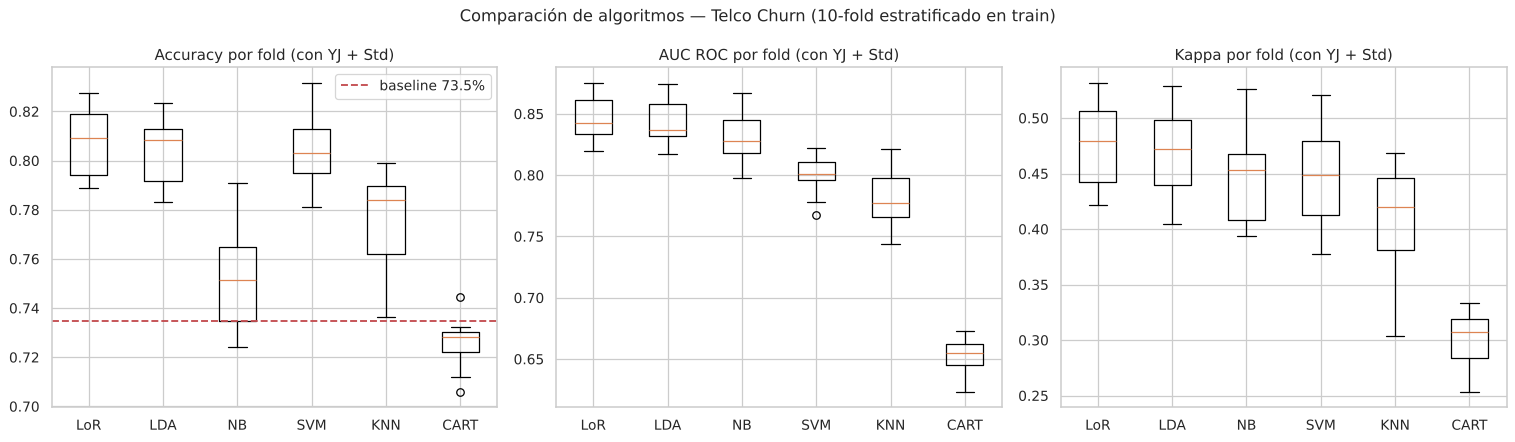

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
orden = res_con_t.index.tolist()
for ax, (metrica, clave) in zip(axes, [("Accuracy", "test_accuracy"), ("AUC ROC", "test_auc"), ("Kappa", "test_kappa")]):
    ax.boxplot([folds_con_t[n][clave] for n in orden], tick_labels=orden)
    ax.set_title(f"{metrica} por fold (con YJ + Std)")
    if metrica == "Accuracy":
        ax.axhline(baseline_t, color="#C44E52", ls="--", label=f"baseline {baseline_t:.1%}"); ax.legend()
plt.suptitle("Comparación de algoritmos — Telco Churn (10-fold estratificado en train)", fontsize=13)
plt.tight_layout(); plt.show()

**Lectura del spot-checking:**
- Todos los modelos superan el baseline de 73,5 %, pero el accuracy solo vuelve a engañar: **Naive Bayes** tiene el accuracy más bajo (75 %) y, sin embargo, el **F1 más alto (0,62)**, porque detecta muchas más bajas (a costa de más falsas alarmas).
- Los mejores por AUC son los **lineales: regresión logística (0,847) y LDA (0,843)**, seguidos de Naive Bayes (0,83). **El árbol sin límite es el peor (0,65)**: se sobreajusta.
- **La transformación ayuda sobre todo a SVM** (kappa de 0,38 a 0,45; AUC de 0,78 a 0,80). A los lineales les suma un poco y al árbol no le cambia nada, como esperábamos (corta de a una variable, así que la escala no le importa). A k-NN casi no le cambia: con la mayoría de las variables en 0/1, sólo hay dos numéricas que escalar.
- Los desvíos entre folds son chicos (~0,02 de AUC): con ~4.900 clientes en train, las estimaciones son estables. Aun así, las diferencias entre LoR, LDA y NB son del mismo orden que el desvío.

### A6.2 Ajuste de hiperparámetros

**k-NN: cantidad de vecinos**

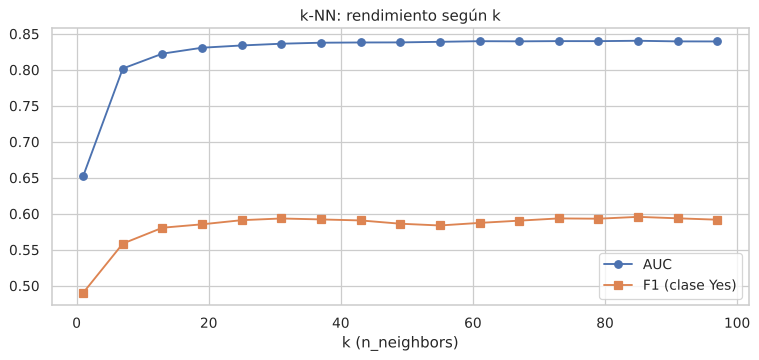

Mejor k por AUC: 85 (AUC = 0.840) | Mejor k por F1: 85 (F1 = 0.596)


In [36]:
ks = list(range(1, 102, 6))
auc_k, f1_k = [], []
for k in ks:
    r = cross_validate(make_pipeline(preproc_t(COLS_T), KNeighborsClassifier(n_neighbors=k)), X_train_t[COLS_T], y_train_t,
                       cv=cv_t, scoring={"auc": "roc_auc", "f1": "f1"})
    auc_k.append(r["test_auc"].mean()); f1_k.append(r["test_f1"].mean())
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, auc_k, marker="o", label="AUC"); ax.plot(ks, f1_k, marker="s", label="F1 (clase Yes)")
ax.set_xlabel("k (n_neighbors)"); ax.set_title("k-NN: rendimiento según k"); ax.legend(); plt.show()
mejor_k_t = ks[int(np.argmax(auc_k))]
print(f"Mejor k por AUC: {mejor_k_t} (AUC = {max(auc_k):.3f}) | Mejor k por F1: {ks[int(np.argmax(f1_k))]} (F1 = {max(f1_k):.3f})")

**Variantes de hiperparámetros de todos los algoritmos:**

In [37]:
variantes_t = {
    "LoR C=1 (defecto)": LogisticRegression(max_iter=2000),
    "LoR C=0.1": LogisticRegression(C=0.1, max_iter=2000),
    "LoR C=10": LogisticRegression(C=10, max_iter=2000),
    "LoR class_weight=balanced": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LDA": LinearDiscriminantAnalysis(),
    f"KNN k={mejor_k_t}": KNeighborsClassifier(n_neighbors=mejor_k_t),
    f"KNN k={mejor_k_t} weights=distance": KNeighborsClassifier(n_neighbors=mejor_k_t, weights="distance"),
    f"KNN k={mejor_k_t} p=1 (Manhattan)": KNeighborsClassifier(n_neighbors=mejor_k_t, p=1),
    "NB": GaussianNB(),
    "CART gini (sin límite)": DecisionTreeClassifier(random_state=SEED),
    "CART entropy": DecisionTreeClassifier(criterion="entropy", random_state=SEED),
    "CART max_depth=4": DecisionTreeClassifier(max_depth=4, random_state=SEED),
    "CART max_depth=6": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "CART min_samples_leaf=30": DecisionTreeClassifier(min_samples_leaf=30, random_state=SEED),
    "SVM rbf C=1 (defecto)": SVC(),
    "SVM rbf C=0.1": SVC(C=0.1),
    "SVM rbf class_weight=balanced": SVC(class_weight="balanced"),
    "SVM linear": SVC(kernel="linear"),
    "SVM poly (grado 3)": SVC(kernel="poly"),
    "SVM sigmoid": SVC(kernel="sigmoid"),
}
res_var_t, folds_var_t = comparar_clasificadores({n: make_pipeline(preproc_t(COLS_T), m) for n, m in variantes_t.items()},
                                                 X_train_t[COLS_T], y_train_t, cv_t)
res_var_t.round(3)

,accuracy,kappa,AUC,AUC (desv),F1
modelo,,,,,
LoR C=10,0.807,0.474,0.847,0.017,0.600
LoR C=1 (defecto),0.808,0.476,0.847,0.017,0.600
LoR C=0.1,0.806,0.466,0.847,0.017,0.590
LoR class_weight=balanced,0.753,0.457,0.847,0.017,0.631
SVM linear,0.804,0.459,0.844,0.017,0.584
LDA,0.803,0.470,0.843,0.018,0.598
KNN k=85,0.800,0.464,0.840,0.019,0.596
KNN k=85 p=1 (Manhattan),0.798,0.459,0.840,0.019,0.593
NB,0.751,0.447,0.831,0.021,0.622


### A6.3 Análisis de la comparación

- **Regresión logística:** cambiar `C` no mueve el AUC (0,847): la regularización no es un problema con 22 variables y 4.900 filas. Con **`class_weight="balanced"`** el accuracy baja (0,81 → 0,75) pero el **F1 sube de 0,60 a 0,63**, porque el modelo se anima a marcar más clientes como "se va". El AUC no cambia: el modelo ordena igual de bien a los clientes, sólo se corre el umbral.
- **k-NN:** necesita **muchos vecinos** (k ≈ 85): con pocos vecinos el voto es muy ruidoso, porque muchos clientes tienen perfiles casi iguales en las variables 0/1. Con k grande llega a un AUC de 0,84, muy cerca de los lineales. Ponderar por distancia empeora.
- **Árbol:** limitar la profundidad (4 o 6) o exigir 30 clientes por hoja lo sube de **0,65 a 0,82** de AUC: el árbol sin límite estaba memorizando train (**overfitting**). Entropía en lugar de Gini no ayuda.
- **SVM:** el kernel **lineal** (0,844) supera al rbf (0,80). Es otra señal de que la frontera entre clientes que se van y que se quedan es aproximadamente lineal. `class_weight="balanced"` sube el F1 a 0,63. El kernel sigmoide es el peor.
- **Conclusión:** vuelven a ganar los **modelos lineales**, con k-NN (k grande), SVM balanceado y Naive Bayes cerca. Pasan a la evaluación final la regresión logística (normal y balanceada), LDA, SVM balanceado, k-NN, Naive Bayes y el árbol con profundidad 6.

## A7. Evaluación final en el conjunto de prueba

Flujo de la clase 29-30: validación cruzada en train → entrenar con todo train → evaluar **una sola vez** en test.

In [38]:
finalistas_t = {
    "LoR": LogisticRegression(max_iter=2000),
    "LoR (balanced)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LDA": LinearDiscriminantAnalysis(),
    "SVM rbf (balanced)": SVC(class_weight="balanced", probability=True, random_state=SEED),
    f"KNN k={mejor_k_t}": KNeighborsClassifier(n_neighbors=mejor_k_t),
    "CART max_depth=6": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "NB": GaussianNB(),
}
filas, probas_t, preds_t, modelos_t = [], {}, {}, {}
for nombre, m in finalistas_t.items():
    modelo = make_pipeline(preproc_t(COLS_T), m).fit(X_train_t[COLS_T], y_train_t)
    pred = modelo.predict(X_test_t[COLS_T]); proba = modelo.predict_proba(X_test_t[COLS_T])[:, 1]
    preds_t[nombre], probas_t[nombre], modelos_t[nombre] = pred, proba, modelo
    filas.append({"modelo": nombre, "accuracy": accuracy_score(y_test_t, pred), "kappa": cohen_kappa_score(y_test_t, pred),
                  "AUC": roc_auc_score(y_test_t, proba), "precision (Yes)": precision_score(y_test_t, pred),
                  "recall (Yes)": recall_score(y_test_t, pred), "F1 (Yes)": f1_score(y_test_t, pred)})
test_t = pd.DataFrame(filas).set_index("modelo").sort_values("AUC", ascending=False)
print(f"Baseline en test (predecir siempre 'No'): accuracy = {1 - y_test_t.mean():.1%}")
test_t.round(3)

Baseline en test (predecir siempre 'No'): accuracy = 73.5%


,accuracy,kappa,AUC,precision (Yes),recall (Yes),F1 (Yes)
modelo,,,,,,
LoR,0.810,0.476,0.848,0.680,0.535,0.599
LoR (balanced),0.752,0.455,0.848,0.521,0.795,0.629
LDA,0.807,0.479,0.845,0.661,0.560,0.606
KNN k=85,0.795,0.455,0.838,0.626,0.561,0.592
SVM rbf (balanced),0.754,0.454,0.829,0.525,0.781,0.628
NB,0.746,0.435,0.824,0.515,0.758,0.613
CART max_depth=6,0.786,0.413,0.817,0.620,0.497,0.552


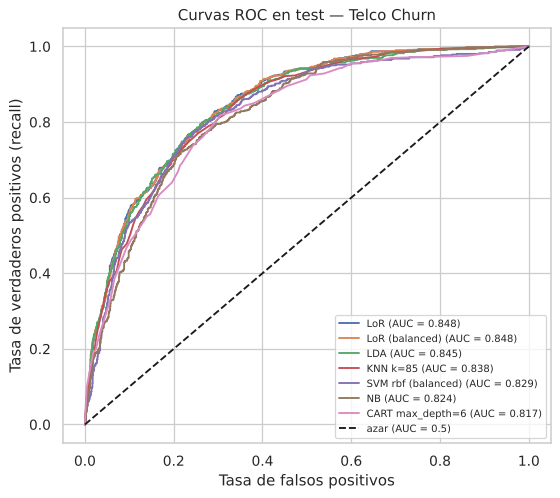

In [39]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre in test_t.index:
    fpr, tpr, _ = roc_curve(y_test_t, probas_t[nombre])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {test_t.loc[nombre, 'AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curvas ROC en test — Telco Churn"); ax.legend(loc="lower right", fontsize=8); plt.show()

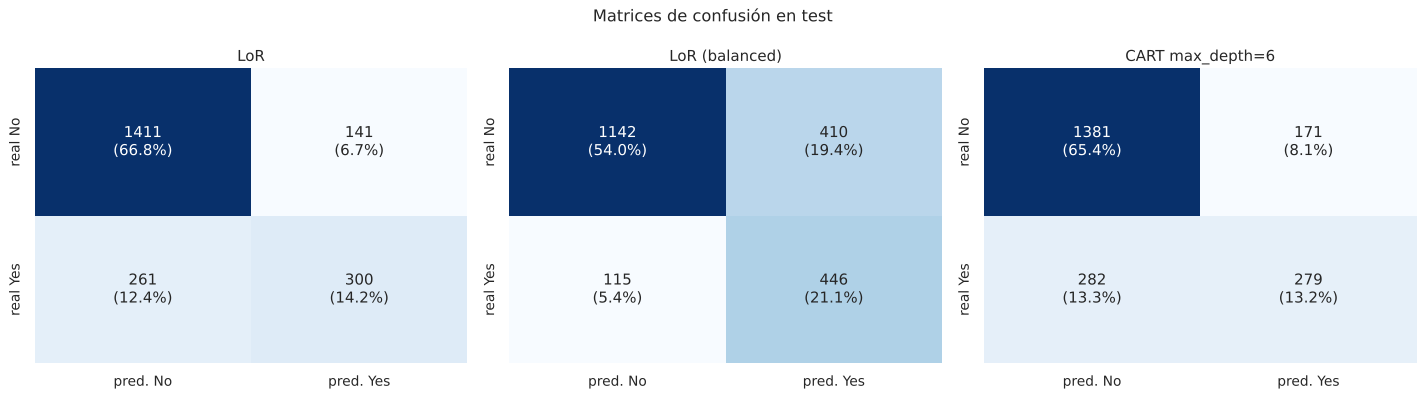

===== LoR =====
               precision    recall  f1-score   support

No (se queda)      0.844     0.909     0.875      1552
  Yes (se va)      0.680     0.535     0.599       561

     accuracy                          0.810      2113
    macro avg      0.762     0.722     0.737      2113
 weighted avg      0.800     0.810     0.802      2113

===== LoR (balanced) =====
               precision    recall  f1-score   support

No (se queda)      0.909     0.736     0.813      1552
  Yes (se va)      0.521     0.795     0.629       561

     accuracy                          0.752      2113
    macro avg      0.715     0.765     0.721      2113
 weighted avg      0.806     0.752     0.764      2113

===== CART max_depth=6 =====
               precision    recall  f1-score   support

No (se queda)      0.830     0.890     0.859      1552
  Yes (se va)      0.620     0.497     0.552       561

     accuracy                          0.786      2113
    macro avg      0.725     0.694     0

In [40]:
modelos_cm_t = ["LoR", "LoR (balanced)", "CART max_depth=6"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, nombre in zip(axes, modelos_cm_t):
    cm = confusion_matrix(y_test_t, preds_t[nombre])
    etiquetas = np.array([[f"{v}\n({v / cm.sum():.1%})" for v in fila] for fila in cm])
    sns.heatmap(cm, annot=etiquetas, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred. No", "pred. Yes"], yticklabels=["real No", "real Yes"])
    ax.set_title(nombre)
plt.suptitle("Matrices de confusión en test", fontsize=13); plt.tight_layout(); plt.show()
for nombre in modelos_cm_t:
    print(f"===== {nombre} =====")
    print(classification_report(y_test_t, preds_t[nombre], target_names=["No (se queda)", "Yes (se va)"], digits=3))

**Interpretación de la evaluación en test:**
- Los resultados en test son **casi idénticos a los de la validación cruzada** (regresión logística: AUC 0,847 en CV y 0,848 en test): no hay sobreajuste y la estimación con K-Fold fue confiable.
- La **regresión logística** tiene el **mejor AUC (0,848)** y accuracy (81 %), pero con el umbral por defecto **detecta sólo 300 de los 561 clientes que se van** (recall 53 %).
- La **regresión logística balanceada** tiene el mismo AUC pero **detecta 446 de los 561 (recall 80 %)**, a costa de más falsas alarmas (precisión 52 %: de cada 2 clientes que marca, 1 se iba a ir).
- **SVM balanceado** y **Naive Bayes** logran un recall parecido (76-78 %) con un AUC algo menor. **LDA** queda prácticamente empatada con la regresión logística. El **árbol** es el más débil, aunque el más fácil de explicar.

**¿Cuál elegimos?** Para una campaña de retención **es más caro perder un cliente que ofrecerle un descuento a alguien que no se iba a ir**. Por eso conviene priorizar el **recall** de la clase "se va". **Elegimos la regresión logística balanceada**: mejor AUC (empatada), detecta 8 de cada 10 bajas, es estable y sus coeficientes se pueden explicar (A8).

### A7.1 Las tres alternativas en el conjunto de prueba

Para completar la comparación de A4.4 evaluamos en test las **tres alternativas** con el mismo algoritmo, la **regresión logística**: modelo base (23 variables), variables elegidas por RFE y PCA sobre las variables del modelo base. Cada una se entrena con todo train y se evalúa una sola vez en test.

In [41]:
filas = []
for alt, (cols, n_comp) in list(alternativas_t.items())[:3]:
    modelo = armar_clf(LogisticRegression(max_iter=2000), cols, n_comp).fit(X_train_t[cols], y_train_t)
    pred, prob = modelo.predict(X_test_t[cols]), modelo.predict_proba(X_test_t[cols])[:, 1]
    filas.append({"alternativa": alt, "accuracy": accuracy_score(y_test_t, pred), "kappa": cohen_kappa_score(y_test_t, pred),
                  "AUC": roc_auc_score(y_test_t, prob), "precision (Yes)": precision_score(y_test_t, pred),
                  "recall (Yes)": recall_score(y_test_t, pred), "F1 (Yes)": f1_score(y_test_t, pred)})
alt_test_t = pd.DataFrame(filas).set_index("alternativa")
print("Regresión logística en test — las tres alternativas:")
alt_test_t.round(3)

Regresión logística en test — las tres alternativas:


,accuracy,kappa,AUC,precision (Yes),recall (Yes),F1 (Yes)
alternativa,,,,,,
1. Base (23 var.),0.811,0.480,0.849,0.684,0.537,0.601
2. RFE (13 var.),0.808,0.471,0.847,0.676,0.531,0.595
3. PCA (13 comp.),0.803,0.446,0.840,0.676,0.492,0.570


**Resultado en test:** igual que en la validación cruzada, las alternativas quedan muy parejas. El **modelo base** (AUC 0,849; F1 0,601) y **RFE** (AUC 0,847; F1 0,595) prácticamente empatan, con RFE usando 10 variables menos. **PCA** es la más débil (AUC 0,840; F1 0,570; recall 0,49): al resumir la información en componentes se pierde parte de lo que distingue a los clientes que se van. En este problema **reducir variables no mejora la predicción**, pero RFE permite un modelo más simple sin perder rendimiento.

### A7.2 Interpretación del árbol de decisión

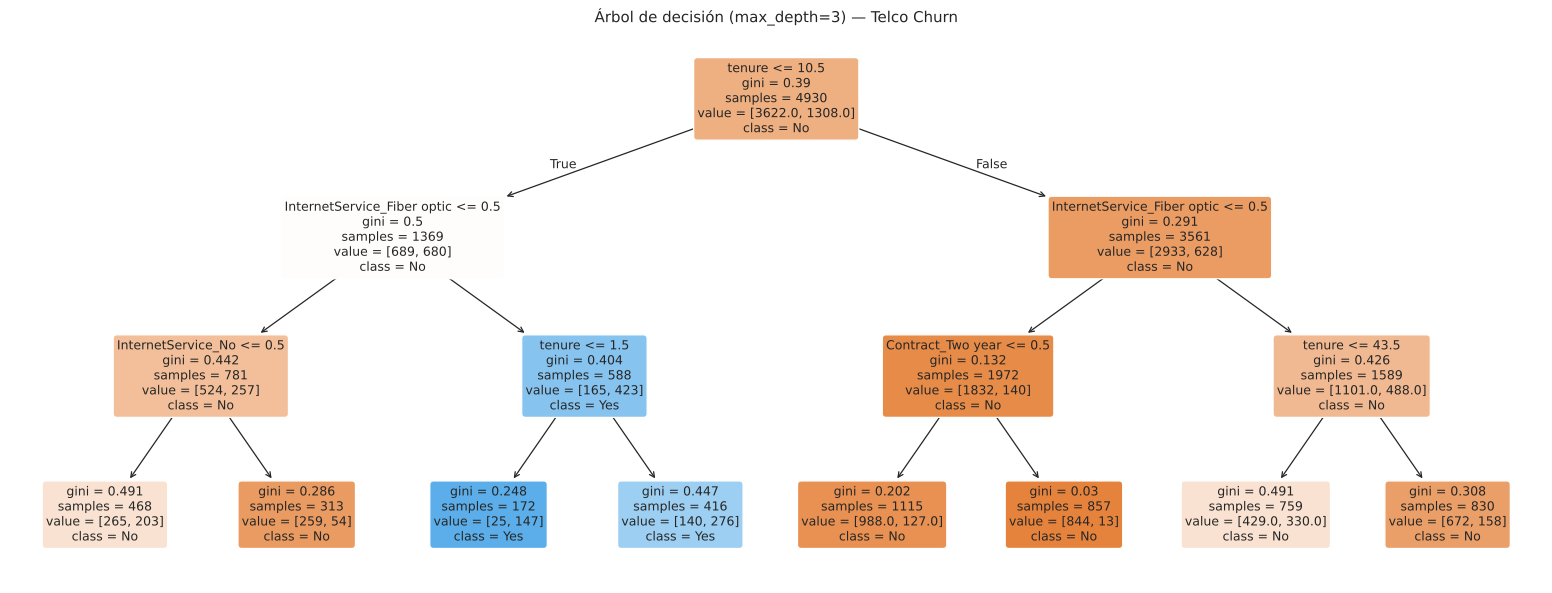

In [42]:
arbol_t = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_train_t[COLS_T], y_train_t)
plt.figure(figsize=(22, 8))
plot_tree(arbol_t, feature_names=COLS_T, class_names=["No", "Yes"], filled=True, rounded=True, fontsize=10, proportion=False)
plt.title("Árbol de decisión (max_depth=3) — Telco Churn"); plt.show()

El árbol resume los hallazgos del EDA en reglas simples:
- La **primera pregunta es la antigüedad** (¿10 meses o menos?).
- **Clientes nuevos con fibra óptica** son el grupo de mayor riesgo: si además tienen 1 mes o menos, se va el **85 %** (147 de 172).
- **Clientes antiguos sin fibra y con contrato de 2 años** casi nunca se van (13 de 857, **1,5 %**).
- Los clientes antiguos con fibra y menos de 44 meses tienen un riesgo intermedio (~43 %).

## A8. Modelo final y predicción de un cliente nuevo

Reentrenamos el modelo elegido con **todos los datos** (train + test) y estimamos la probabilidad de baja de dos clientes de ejemplo.

In [43]:
modelo_final_t = make_pipeline(preproc_t(COLS_T), LogisticRegression(max_iter=2000, class_weight="balanced"))
modelo_final_t.fit(X_t[COLS_T], y_t)

def cliente(**datos):
    """Arma un cliente con todas las columnas codificadas (0 por defecto) y completa las que se indican."""
    fila = pd.DataFrame([np.zeros(len(features_t))], columns=features_t)
    for k, v in datos.items():
        fila[k] = v
    return fila[COLS_T]

nuevos = pd.concat([
    cliente(PhoneService=1, tenure=3, MonthlyCharges=95.0, TotalCharges=285.0, **{"InternetService_Fiber optic": 1,
            "PaymentMethod_Electronic check": 1, "PaperlessBilling": 1, "StreamingTV": 1}),
    cliente(PhoneService=1, tenure=48, MonthlyCharges=60.0, TotalCharges=2880.0, Partner=1, OnlineSecurity=1, TechSupport=1,
            **{"Contract_Two year": 1, "PaymentMethod_Credit card (automatic)": 1}),
], ignore_index=True)
nuevos.index = ["Cliente A: 3 meses, fibra, mes a mes, cheque electrónico", "Cliente B: 4 años, DSL, contrato 2 años, tarjeta"]
proba_baja = modelo_final_t.predict_proba(nuevos)[:, 1]
pd.DataFrame({"predicción": le_t.inverse_transform(modelo_final_t.predict(nuevos)),
              "probabilidad de baja": [f"{p:.1%}" for p in proba_baja]}, index=nuevos.index)

,predicción,probabilidad de baja
"Cliente A: 3 meses, fibra, mes a mes, cheque electrónico",Yes,88.9%
"Cliente B: 4 años, DSL, contrato 2 años, tarjeta",No,2.7%


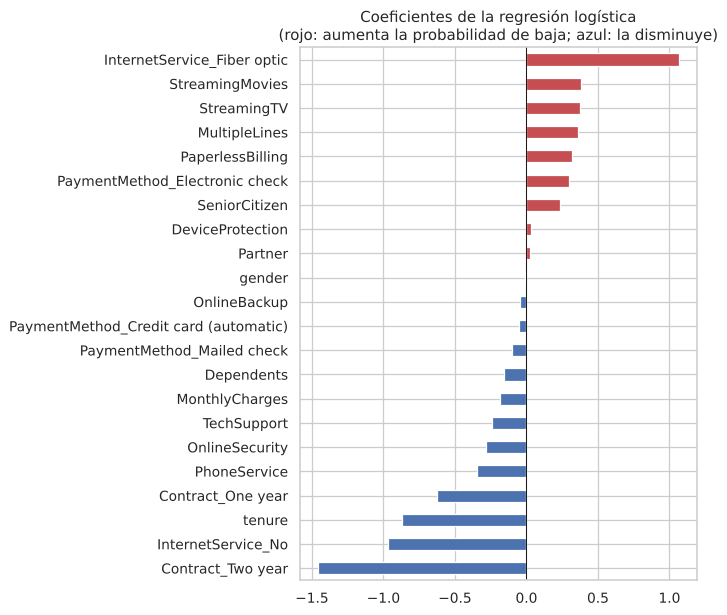

In [44]:
# el ColumnTransformer pone primero las numéricas: tomamos los nombres en el orden de salida
coefs_t = pd.Series(modelo_final_t[-1].coef_[0], index=modelo_final_t[0].get_feature_names_out()).sort_values()
coefs_t.plot(kind="barh", figsize=(8, 7), color=np.where(coefs_t > 0, "#C44E52", "#4C72B0"))
plt.axvline(0, color="k", lw=.8)
plt.title("Coeficientes de la regresión logística\n(rojo: aumenta la probabilidad de baja; azul: la disminuye)")
plt.tight_layout(); plt.show()

**Lectura de los coeficientes** (las variables numéricas están estandarizadas, así que los tamaños son comparables):
- Lo que más **reduce** la probabilidad de baja: el **contrato de 2 años** (el coeficiente más grande), **no tener internet** (clientes sólo con teléfono, más estables), la **antigüedad** y el **contrato de 1 año**. Tener **seguridad online** y **soporte técnico** también ayuda a retener.
- Lo que más la **aumenta**: la **fibra óptica** (probablemente por su precio o por problemas de calidad del servicio), el **streaming**, la **factura electrónica**, el **pago con cheque electrónico** y ser **mayor de 65**.
- `gender` y `Partner` tienen coeficientes prácticamente 0: el modelo confirma que no influyen.

**Recomendación para el negocio:** los clientes nuevos, con fibra, contrato mes a mes y cheque electrónico son los de mayor riesgo (el cliente A de ejemplo tiene ~90 % de probabilidad de irse). Ofrecerles **migrar a un contrato anual** y a **débito automático**, o sumarles **soporte técnico**, ataca justo los factores que el modelo asocia con la permanencia.

---
# PARTE B — REGRESIÓN: *Medical Cost Personal*

## B1. Descripción del problema

**Contexto.** El dataset *Medical Cost Personal* (Kaggle; proviene del libro *Machine Learning with R* de Brett Lantz) tiene **1.338 personas aseguradas** en Estados Unidos, con algunos datos personales y el **costo médico anual** que le facturaron al seguro.

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica (entera) | Edad del titular (18 a 64 años) |
| `sex` | Categórica (2) | Sexo: `female` / `male` |
| `bmi` | Numérica (continua) | Índice de masa corporal (peso / altura²) |
| `children` | Numérica (entera) | Cantidad de hijos cubiertos por el seguro |
| `smoker` | Categórica (2) | ¿Fuma? `yes` / `no` |
| `region` | Categórica (4) | Región de residencia en EE. UU.: `northeast`, `northwest`, `southeast`, `southwest` |
| **`charges`** | **Numérica (continua)** | **Costo médico anual facturado (USD) → variable objetivo** |

**¿Qué queremos predecir?** El **costo médico anual (`charges`)** de una persona a partir de sus características. Es un problema de **regresión**: la respuesta es un número (dólares), no una categoría.

**¿Por qué es adecuado para el TP?**
- Mezcla **variables numéricas y categóricas** → nos obliga a aplicar **codificación** (Label, One-Hot y Target Encoding).
- La variable objetivo es **muy asimétrica** (muchos costos bajos y pocos muy altos) → sirve para aplicar **Box-Cox**.
- Tiene una **fila duplicada** y **valores atípicos** reales → paso concreto de limpieza.
- Las relaciones no son del todo lineales (el efecto del IMC depende de si la persona fuma) → buen caso para comparar algoritmos **lineales y no lineales**.
- Tamaño manejable y variables fáciles de explicar.

**Uso práctico:** en una aseguradora, estimar el costo esperado de un asegurado sirve para **fijar primas**, **armar reservas** y detectar qué factores de riesgo pesan más.

## B2. Análisis exploratorio de datos (EDA)

### B2.1 Carga y primera revisión

In [45]:
df_i = pd.read_csv("data/insurance.csv")
df_i.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855
5,31,female,25.740,0,no,southeast,3756.622
6,46,female,33.440,1,no,southeast,8240.590
7,37,female,27.740,3,no,northwest,7281.506
8,37,male,29.830,2,no,northeast,6406.411
9,60,female,25.840,0,no,northwest,28923.137


In [46]:
print("Dimensiones (filas, columnas):", df_i.shape)
print("\nTipos de datos:")
print(df_i.dtypes)
num_i = ["age", "bmi", "children"]
cat_i = ["sex", "smoker", "region"]

Dimensiones (filas, columnas): (1338, 7)

Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


Hay 4 columnas numéricas (`age`, `bmi`, `children`, `charges`) y 3 categóricas de tipo texto (`sex`, `smoker` y `region`; pandas las muestra como `object` o `str` según la versión).

### B2.2 Estadística descriptiva

In [47]:
desc_i = df_i.describe().T
desc_i["mediana"] = df_i.median(numeric_only=True)
desc_i["coef_var"] = desc_i["std"] / desc_i["mean"]
desc_i[["count", "mean", "std", "min", "25%", "mediana", "75%", "max", "coef_var"]]

,count,mean,std,min,25%,mediana,75%,max,coef_var
age,1338.0,39.207,14.050,18.000,27.000,39.000,51.000,64.000,0.358
bmi,1338.0,30.663,6.098,15.960,26.296,30.400,34.694,53.130,0.199
children,1338.0,1.095,1.205,0.000,0.000,1.000,2.000,5.000,1.101
charges,1338.0,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428,0.913


In [48]:
# Variables categóricas: cantidad de categorías, la más frecuente y su frecuencia
df_i.describe(include="object").T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


**Lo que vemos:**
- `charges` va de ~1.100 a ~63.800 USD, con **media (13.270) muy superior a la mediana (9.382)**: hay pocas personas con costos muy altos que tiran la media para arriba (asimetría a la derecha).
- `age` se distribuye de forma bastante pareja entre 18 y 64 años; `bmi` tiene media ~30,7 (en el límite de la obesidad según la OMS).
- En las categóricas, `smoker` tiene 2 categorías y la más frecuente es "no"; `region` tiene 4.

### B2.3 Distribución de la variable objetivo y de las categorías

En regresión no hay "clases", pero sí conviene ver cómo se reparten las categorías y cómo cambia el costo en cada una.

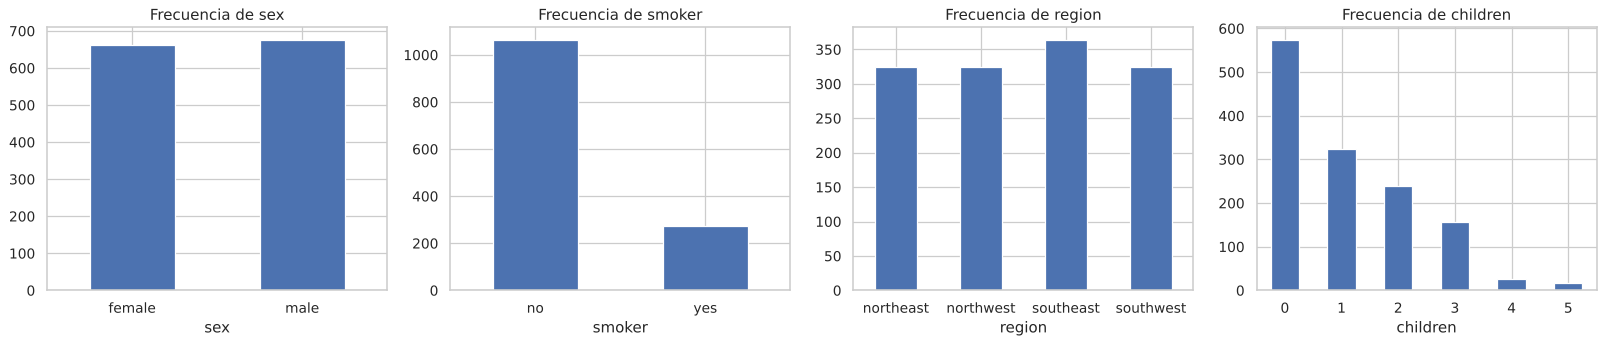


sex:
        cantidad     %  costo medio  costo mediano
sex                                               
female       662  49.5      12570.0         9413.0
male         676  50.5      13957.0         9370.0

smoker:
        cantidad     %  costo medio  costo mediano
smoker                                            
no          1064  79.5       8434.0         7345.0
yes          274  20.5      32050.0        34456.0

region:
           cantidad     %  costo medio  costo mediano
region                                               
northeast       324  24.2      13406.0        10058.0
northwest       325  24.3      12418.0         8966.0
southeast       364  27.2      14735.0         9294.0
southwest       325  24.3      12347.0         8799.0


In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_i + ["children"]):
    df_i[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(f"Frecuencia de {col}"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

for col in cat_i:
    print(f"\n{col}:")
    print(pd.DataFrame({"cantidad": df_i[col].value_counts(), "%": df_i[col].value_counts(normalize=True).mul(100).round(1),
                        "costo medio": df_i.groupby(col)["charges"].mean().round(0),
                        "costo mediano": df_i.groupby(col)["charges"].median().round(0)}).to_string())

**Lo que vemos:**
- `sex` y `region` están **balanceadas** (~50 % y ~25 % por categoría).
- Sólo **~20 % son fumadores**, pero su costo medio (~32.000 USD) es **casi 4 veces** el de los no fumadores (~8.400 USD). Es la diferencia más marcada del dataset.
- Entre sexos y regiones las diferencias de costo son mucho más chicas (el sudeste es algo más caro).

### B2.4 Asimetría

In [50]:
asim_i = df_i[num_i + ["charges"]].skew().sort_values(ascending=False)
pd.DataFrame({"asimetría": asim_i,
              "interpretación": np.where(asim_i.abs() > 1, "fuerte", np.where(asim_i.abs() > 0.5, "moderada", "baja"))})

,asimetría,interpretación
charges,1.516,fuerte
children,0.938,moderada
bmi,0.284,baja
age,0.056,baja


**`charges` tiene asimetría fuerte (1,52)**; `children` es moderada (es un conteo con muchos ceros) y `age` y `bmi` son casi simétricas. Por eso vamos a probar **Box-Cox sobre `charges`** (todos sus valores son positivos, así que Box-Cox se puede aplicar).

### B2.5 Histogramas y gráficos de densidad

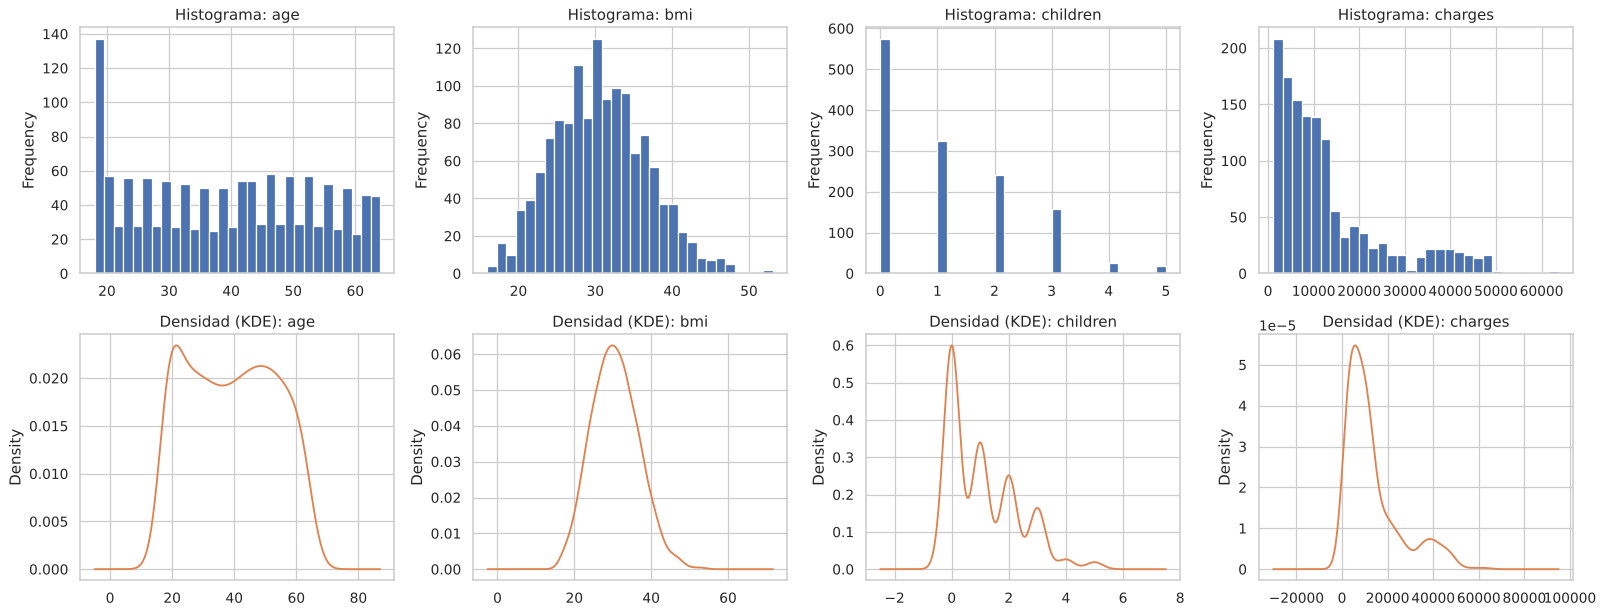

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(num_i + ["charges"]):
    df_i[col].plot(kind="hist", bins=30, ax=axes[0, i], color="#4C72B0", edgecolor="white", title=f"Histograma: {col}")
    df_i[col].plot(kind="density", ax=axes[1, i], color="#DD8452", title=f"Densidad (KDE): {col}")
plt.tight_layout(); plt.show()

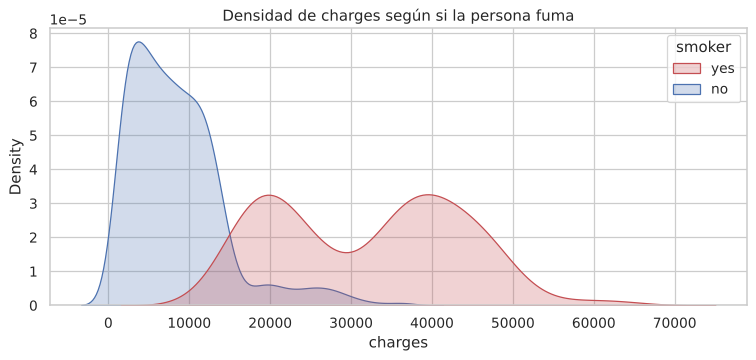

In [52]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_i, x="charges", hue="smoker", fill=True, common_norm=False, palette={"no": "#4C72B0", "yes": "#C44E52"})
plt.title("Densidad de charges según si la persona fuma"); plt.show()

El histograma de `charges` es muy asimétrico y tiene **varias "jorobas"**. El gráfico por `smoker` explica por qué: los no fumadores se concentran en costos bajos, mientras que los fumadores forman **dos grupos** (uno alrededor de 20.000 USD y otro cerca de 40.000 USD). Es decir, el costo es una **mezcla de subpoblaciones**, lo que ya sugiere que un modelo puramente lineal va a tener dificultades.

### B2.6 Boxplots (univariables y según las categorías)

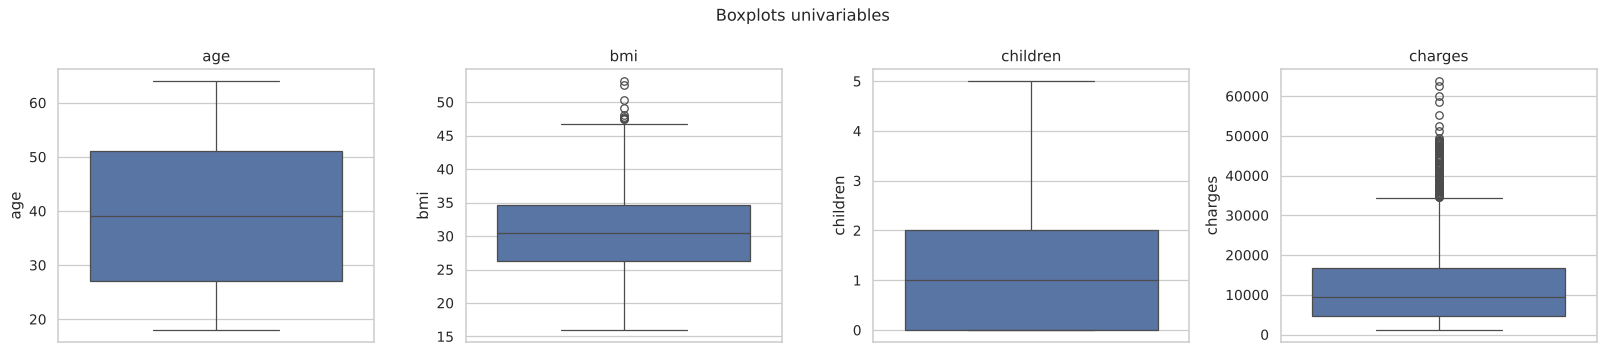

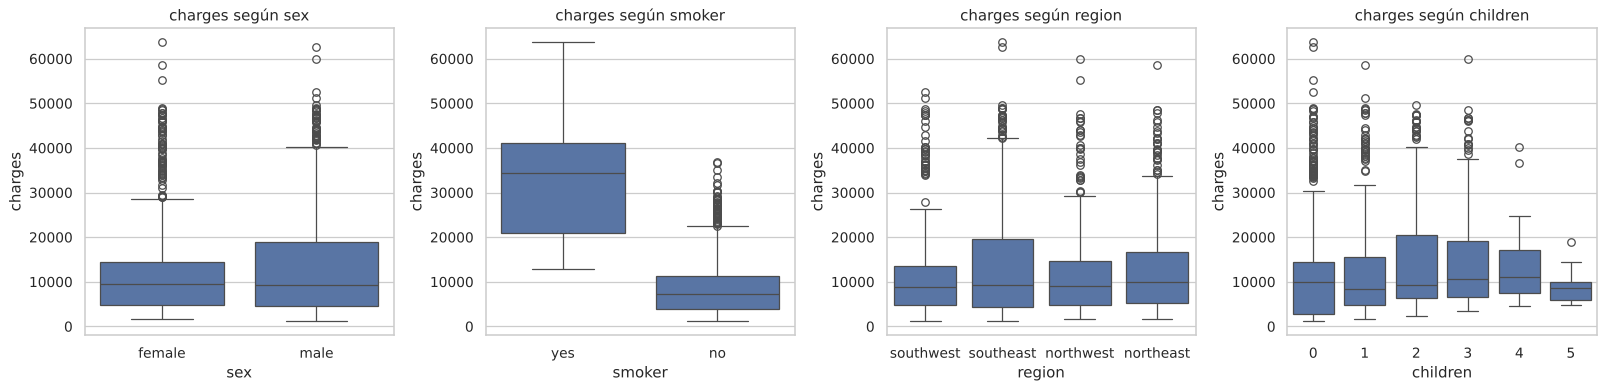

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_i + ["charges"]):
    sns.boxplot(y=df_i[col], ax=ax, color="#4C72B0"); ax.set_title(col)
plt.suptitle("Boxplots univariables", fontsize=13); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, cat_i + ["children"]):
    sns.boxplot(data=df_i, x=col, y="charges", ax=ax); ax.set_title(f"charges según {col}")
plt.tight_layout(); plt.show()

- En el boxplot de `charges` hay **muchos puntos por encima del bigote**: son los costos altos (casi todos de fumadores, como muestra el boxplot por `smoker`).
- `bmi` tiene algunos atípicos por encima de 47.
- La caja de fumadores está **completamente por encima** de la de no fumadores. Por sexo y región, las cajas son parecidas.

### B2.7 Matriz de correlación

Para calcular la correlación con las variables categóricas, en esta copia exploratoria pasamos `sex` y `smoker` a 0/1 y `region` a variables dummy (en B3 hacemos la codificación formal).

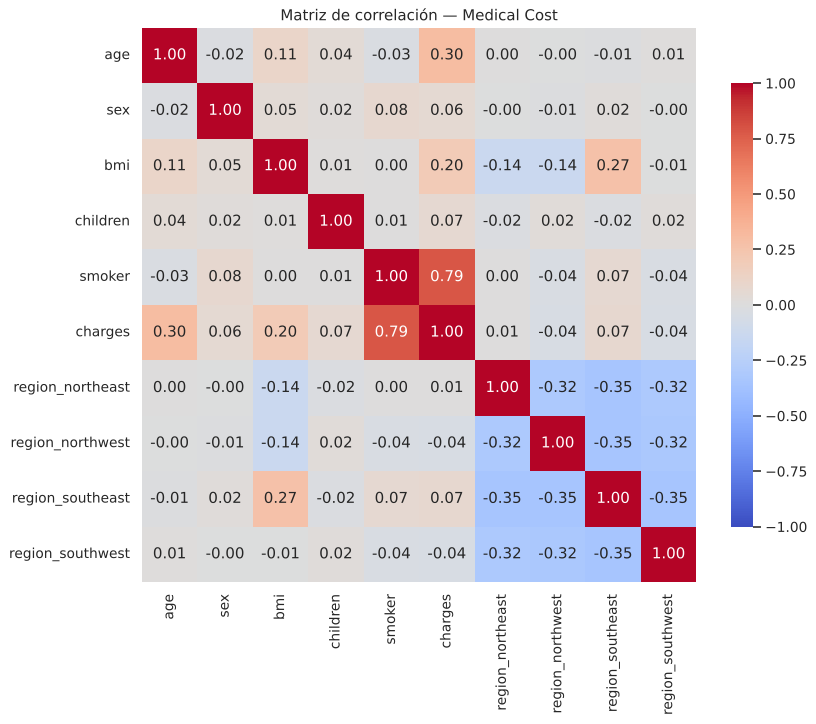

Correlación con charges:
smoker              0.787
age                 0.299
bmi                 0.198
region_southeast    0.074
children            0.068
sex                 0.057
region_southwest   -0.043
region_northwest   -0.040
region_northeast    0.006


In [54]:
df_i_corr = df_i.copy()
df_i_corr["sex"] = (df_i_corr["sex"] == "male").astype(int)
df_i_corr["smoker"] = (df_i_corr["smoker"] == "yes").astype(int)
df_i_corr = pd.get_dummies(df_i_corr, columns=["region"], dtype=int)
corr_i = df_i_corr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_i, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación — Medical Cost"); plt.show()
print("Correlación con charges:")
print(corr_i["charges"].drop("charges").sort_values(key=abs, ascending=False).round(3).to_string())

- **`smoker` es la variable más correlacionada con el costo (0,79)**, muy lejos de las demás.
- Después vienen `age` (0,30) y `bmi` (0,20). `children`, `sex` y la región casi no se correlacionan con el costo.
- Entre las variables de entrada **no hay correlaciones altas** (la mayor es entre las dummies de región, que es lógico porque son excluyentes): no hay problema de multicolinealidad.

### B2.8 Matriz de dispersión

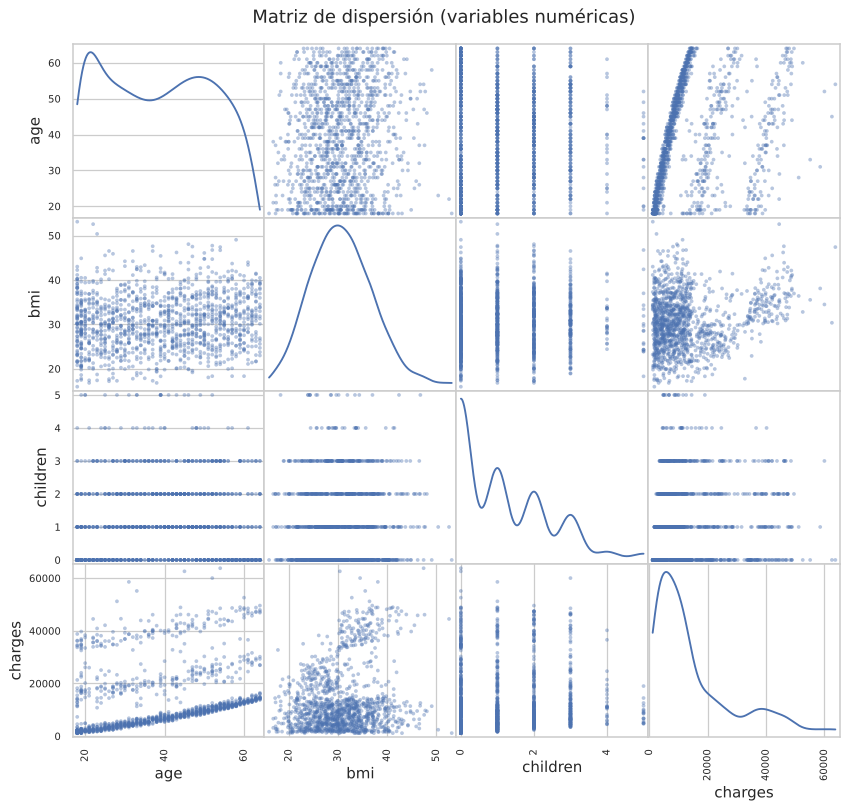

In [55]:
pd.plotting.scatter_matrix(df_i[num_i + ["charges"]], figsize=(11, 10), alpha=0.4, diagonal="kde", color="#4C72B0")
plt.suptitle("Matriz de dispersión (variables numéricas)", y=0.92); plt.show()

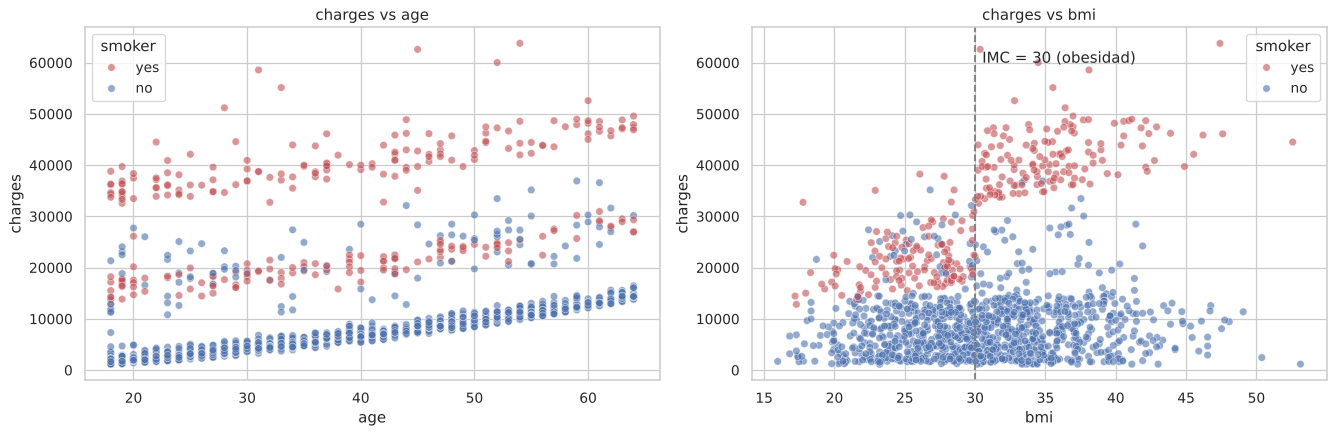

In [56]:
# Complemento: la misma relación coloreando por smoker revela la estructura oculta
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_i, x="age", y="charges", hue="smoker", alpha=.6, ax=axes[0], palette={"no": "#4C72B0", "yes": "#C44E52"})
axes[0].set_title("charges vs age")
sns.scatterplot(data=df_i, x="bmi", y="charges", hue="smoker", alpha=.6, ax=axes[1], palette={"no": "#4C72B0", "yes": "#C44E52"})
axes[1].axvline(30, color="gray", ls="--"); axes[1].text(30.5, 60000, "IMC = 30 (obesidad)")
axes[1].set_title("charges vs bmi"); plt.tight_layout(); plt.show()

Este es el hallazgo más importante del EDA:
- **charges vs age:** se ven **tres "bandas" paralelas**. En todas, el costo sube con la edad, pero la banda depende del grupo: no fumadores (abajo), y fumadores divididos en dos niveles.
- **charges vs bmi:** en los **no fumadores** el IMC casi no influye. En los **fumadores**, hay un **salto** al pasar IMC = 30: los fumadores con obesidad tienen costos de ~40.000 USD y los fumadores sin obesidad, de ~20.000 USD.

Es decir, hay una **interacción**: el efecto del IMC depende de si la persona fuma. Un modelo lineal simple (que suma efectos por separado) no puede capturarla; un árbol sí. Lo vamos a aprovechar en B3.4 con una **binarización** del IMC.

### B2.9 Valores faltantes, duplicados, atípicos e inconsistencias

In [57]:
print("Valores faltantes por columna:")
print(df_i.isna().sum().to_string())
print("\nFilas duplicadas:", df_i.duplicated().sum())
display(df_i[df_i.duplicated(keep=False)])
print("Categorías únicas (para detectar inconsistencias de escritura):")
for col in cat_i:
    print(f"  {col}: {sorted(df_i[col].unique())}")
print("\nValores atípicos según IQR:")
display(contar_atipicos_iqr(df_i[num_i + ["charges"]]))

Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0

Filas duplicadas: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.563
581,19,male,30.59,0,no,northwest,1639.563


Categorías únicas (para detectar inconsistencias de escritura):
  sex: ['female', 'male']
  smoker: ['no', 'yes']
  region: ['northeast', 'northwest', 'southeast', 'southwest']

Valores atípicos según IQR:


,atípicos,% del total
age,0,0.0
bmi,9,0.7
children,0,0.0
charges,139,10.4


**Diagnóstico y decisiones:**
1. **Faltantes:** no hay.
2. **Inconsistencias de formato:** las categorías están bien escritas (sin mayúsculas mezcladas ni espacios). Los tipos de datos son correctos.
3. **Duplicados:** hay **1 fila repetida** (un hombre de 19 años, no fumador, del noroeste, con exactamente el mismo costo). Es muy improbable que dos personas distintas tengan el mismo costo con todos los decimales, así que es un **error de carga**: **la eliminamos**.
4. **Atípicos:** `charges` tiene ~10 % de valores altos según IQR y `bmi` unos pocos. **Los conservamos**: no son errores, son los pacientes caros (en su mayoría fumadores), que son justamente el caso más importante para una aseguradora. Eliminarlos haría que el modelo subestime los costos altos. Su efecto sobre los modelos lineales lo atenuamos con **Box-Cox sobre `charges`** (B3.3).

In [58]:
df_i = df_i.drop_duplicates().reset_index(drop=True)
print("Filas después de eliminar el duplicado:", len(df_i))

Filas después de eliminar el duplicado: 1337


## B3. Preprocesamiento de datos

### B3.1 Codificación de variables categóricas

| Variable | Categorías | Técnica | Motivo |
|---|---|---|---|
| `sex` | 2 | **Label Encoding** | Binaria: female → 0, male → 1 |
| `smoker` | 2 | **Label Encoding** | Binaria: no → 0, yes → 1 |
| `region` | 4, sin orden | **One-Hot Encoding** (`drop_first=True`) | Si usáramos 0, 1, 2, 3 el modelo interpretaría que "southwest" (3) es "mayor" que "northeast" (0), lo que no tiene sentido |

Estas codificaciones **no aprenden nada de los valores de `charges`**, así que se pueden aplicar antes de dividir sin riesgo de fuga de datos. Más abajo mostramos además **Target Encoding**, que sí aprende de `charges` y por eso se calcula sólo con train.

In [59]:
df_i_cod = df_i.copy()
le_sex, le_smoker = LabelEncoder(), LabelEncoder()
df_i_cod["sex"] = le_sex.fit_transform(df_i_cod["sex"])
df_i_cod["smoker"] = le_smoker.fit_transform(df_i_cod["smoker"])
print("sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))),
      "| smoker:", dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_))))
df_i_cod = pd.get_dummies(df_i_cod, columns=["region"], drop_first=True, dtype=int)

print("ANTES de codificar:"); display(df_i.head())
print("DESPUÉS de codificar (Label Encoding + One-Hot):"); display(df_i_cod.head())

sex: {'female': np.int64(0), 'male': np.int64(1)} | smoker: {'no': np.int64(0), 'yes': np.int64(1)}
ANTES de codificar:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


DESPUÉS de codificar (Label Encoding + One-Hot):


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.924,0,0,1
1,18,1,33.770,1,0,1725.552,0,1,0
2,28,1,33.000,3,0,4449.462,0,1,0
3,33,1,22.705,0,0,21984.471,1,0,0
4,32,1,28.880,0,0,3866.855,1,0,0


`drop_first=True` elimina la columna `region_northeast` porque es redundante: si las otras tres dummies valen 0, la persona es del noreste. Así evitamos la multicolinealidad perfecta en la regresión lineal.

### B3.2 División en entrenamiento y prueba

In [60]:
X_i = df_i_cod.drop(columns="charges")
y_i = df_i_cod["charges"]
features_i = X_i.columns.tolist()
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_i, y_i, test_size=0.30, random_state=SEED)
print(f"Train: {X_train_i.shape} | Test: {X_test_i.shape}")
print(f"Costo medio → train: {y_train_i.mean():,.0f} USD | test: {y_test_i.mean():,.0f} USD")
print(f"% fumadores → train: {X_train_i['smoker'].mean():.1%} | test: {X_test_i['smoker'].mean():.1%}")

Train: (935, 8) | Test: (402, 8)
Costo medio → train: 13,035 USD | test: 13,847 USD
% fumadores → train: 20.7% | test: 19.9%


**Target Encoding (demostración, sólo con train).** Reemplaza cada región por el **costo promedio de esa región en train**. Es útil cuando una variable tiene muchas categorías (por ejemplo, 200 ciudades), porque One-Hot generaría 200 columnas. Como usa `charges`, si lo calculáramos con todo el dataset el modelo "espiaría" el test.

In [61]:
region_train = df_i.loc[X_train_i.index, "region"]
medias_region = y_train_i.groupby(region_train).mean()
print("Target Encoding aprendido en train (costo medio por región):")
print(medias_region.round(0).to_string())
region_te_test = df_i.loc[X_test_i.index, "region"].map(medias_region)
pd.DataFrame({"region (original)": df_i.loc[X_test_i.index, "region"].head(6).values,
              "region (target encoding)": region_te_test.head(6).round(0).values})

Target Encoding aprendido en train (costo medio por región):
region
northeast    13660.0
northwest    12052.0
southeast    14041.0
southwest    12343.0


,region (original),region (target encoding)
0,northeast,13660.0
1,southwest,12343.0
2,northwest,12052.0
3,northwest,12052.0
4,southeast,14041.0
5,southeast,14041.0


In [62]:
# ¿Conviene Target Encoding o One-Hot para region? Lo comparamos con regresión lineal y K-Fold en train.
# Para no filtrar información, dentro de cada fold el promedio por región se calcula sólo con la parte de entrenamiento del fold.
kf_i = KFold(n_splits=10, shuffle=True, random_state=7)
X_train_i_te = X_train_i.drop(columns=[c for c in features_i if c.startswith("region_")]).assign(region=region_train.values)
rmse_te, rmse_oh = [], []
for tr, va in kf_i.split(X_train_i):
    medias = y_train_i.iloc[tr].groupby(X_train_i_te["region"].iloc[tr]).mean()
    A_tr = X_train_i_te.iloc[tr].assign(region=lambda d: d["region"].map(medias))
    A_va = X_train_i_te.iloc[va].assign(region=lambda d: d["region"].map(medias))
    rmse_te.append(np.sqrt(mean_squared_error(y_train_i.iloc[va], LinearRegression().fit(A_tr, y_train_i.iloc[tr]).predict(A_va))))
    m = LinearRegression().fit(X_train_i.iloc[tr], y_train_i.iloc[tr])
    rmse_oh.append(np.sqrt(mean_squared_error(y_train_i.iloc[va], m.predict(X_train_i.iloc[va]))))
print(f"RMSE regresión lineal con One-Hot:         {np.mean(rmse_oh):,.0f} USD")
print(f"RMSE regresión lineal con Target Encoding: {np.mean(rmse_te):,.0f} USD")

RMSE regresión lineal con One-Hot:         6,046 USD
RMSE regresión lineal con Target Encoding: 6,036 USD


Las dos codificaciones dan prácticamente el mismo error. Como `region` tiene sólo 4 categorías, **nos quedamos con One-Hot**, que es más simple y no tiene riesgo de fuga. Target Encoding sería la opción si hubiera muchas categorías.

### B3.3 Transformación de la variable objetivo: Box-Cox

`charges` es muy asimétrica y todos sus valores son positivos → aplicamos **Box-Cox**. `PowerTransformer(method="box-cox")` hace, en este orden, **1º Box-Cox y 2º estandarización** (media 0, desvío 1). El λ se aprende **sólo con train**.

λ de Box-Cox aprendido en train: 0.052
   charges antes  charges después (Box-Cox + Std)
0      27322.734                            1.252
1      42303.692                            1.768
2      42112.236                            1.762
3      41676.081                            1.750
4      44202.654                            1.820


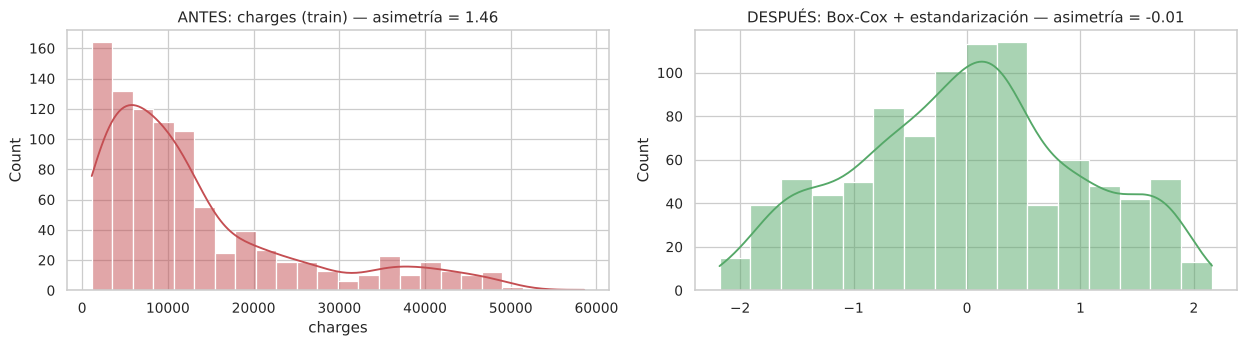

In [63]:
bc_y = PowerTransformer(method="box-cox")
y_train_i_bc = bc_y.fit_transform(y_train_i.to_frame()).ravel()
y_test_i_bc = bc_y.transform(y_test_i.to_frame()).ravel()
print(f"λ de Box-Cox aprendido en train: {bc_y.lambdas_[0]:.3f}")
print(pd.DataFrame({"charges antes": y_train_i.head().values, "charges después (Box-Cox + Std)": y_train_i_bc[:5]}).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(y_train_i, kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title(f"ANTES: charges (train) — asimetría = {pd.Series(y_train_i).skew():.2f}")
sns.histplot(y_train_i_bc, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"DESPUÉS: Box-Cox + estandarización — asimetría = {pd.Series(y_train_i_bc).skew():.2f}")
plt.tight_layout(); plt.show()

La asimetría bajó de ~1,5 a prácticamente 0. La distribución no queda perfectamente normal (siguen existiendo los grupos de fumadores), pero la cola larga desaparece.

Para usarla en los modelos, usamos `TransformedTargetRegressor`: el modelo **aprende sobre `charges` transformada** y, al predecir, **aplica la transformación inversa**, de modo que las predicciones y las métricas quedan en dólares y se pueden comparar con los modelos sin transformar.

### B3.4 Transformaciones de las variables de entrada: estandarización y binarización

1. **Estandarización (`StandardScaler`)** de `age`, `bmi` y `children`: las variables están en escalas distintas (la edad llega a 64, los hijos a 5, las dummies son 0/1). k-NN y SVR usan distancias y Ridge/LASSO penalizan coeficientes, así que necesitan la misma escala.
2. **Binarización (`Binarizer`)** del IMC con umbral 30 → nueva variable `obeso` (1 si IMC > 30). El EDA mostró que el costo "salta" en ese punto para los fumadores. Con ella creamos la **interacción `fumador_obeso` = smoker × obeso**, para que los modelos lineales puedan capturar ese salto.

El umbral 30 no se aprende de los datos (es el corte de obesidad de la OMS), así que no hay fuga; igual seguimos la regla de ajustar con train y aplicar a test.

In [64]:
binarizador = Binarizer(threshold=30.0)
def agregar_obesidad(X):
    X = X.copy()
    X["obeso"] = binarizador.transform(X[["bmi"]]).ravel().astype(int)
    X["fumador_obeso"] = X["smoker"] * X["obeso"]
    return X

binarizador.fit(X_train_i[["bmi"]])            # no aprende nada: el umbral es fijo
X_train_i2 = agregar_obesidad(X_train_i)
X_test_i2 = agregar_obesidad(X_test_i)
features_i2 = X_train_i2.columns.tolist()

print("ANTES (bmi continuo):"); display(X_train_i[["bmi", "smoker"]].head())
print("DESPUÉS (binarización + interacción):"); display(X_train_i2[["bmi", "obeso", "smoker", "fumador_obeso"]].head())
print("Costo medio en train según grupo:")
print(y_train_i.groupby([X_train_i2["smoker"].map({0: "no fuma", 1: "fuma"}),
                         X_train_i2["obeso"].map({0: "IMC <= 30", 1: "IMC > 30"})]).agg(["count", "mean"]).round(0).to_string())

ANTES (bmi continuo):


,bmi,smoker
138,31.900,0
381,30.685,1
292,45.540,1
1089,36.190,1
892,38.940,1


DESPUÉS (binarización + interacción):


,bmi,obeso,smoker,fumador_obeso
138,31.900,1,0,0
381,30.685,1,1,1
292,45.540,1,1,1
1089,36.190,1,1,1
892,38.940,1,1,1


Costo medio en train según grupo:
                   count     mean
smoker  obeso                    
fuma    IMC <= 30    101  21344.0
        IMC > 30      93  40880.0
no fuma IMC <= 30    348   7881.0
        IMC > 30     393   8875.0


ANTES de estandarizar:


,age,bmi,children
mean,39.010,30.620,1.084
std,13.999,6.024,1.198
min,18.000,15.960,0.000
max,64.000,53.130,5.000


DESPUÉS de estandarizar:


,age,bmi,children
mean,1.159e-16,-2.223e-16,-2.375e-17
std,1.001e+00,1.001e+00,1.001e+00
min,-1.502e+00,-2.435e+00,-9.058e-01
max,1.786e+00,3.739e+00,3.270e+00


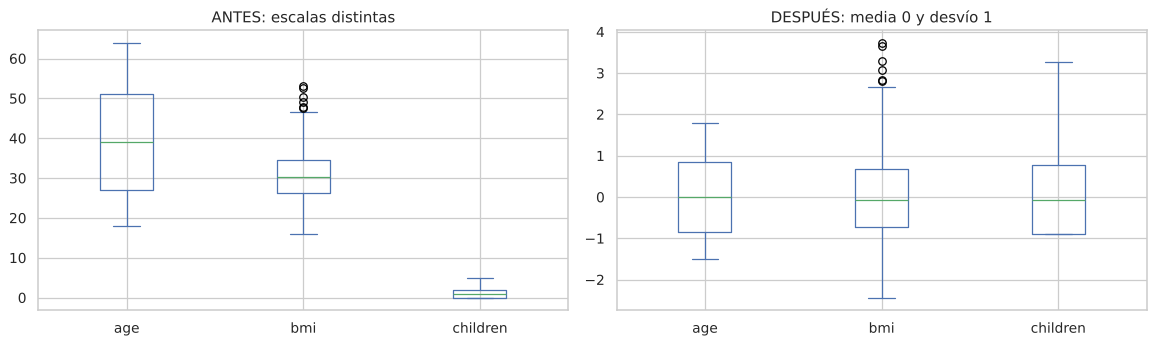

In [65]:
esc_i = StandardScaler()
X_train_i_std = X_train_i2.copy(); X_test_i_std = X_test_i2.copy()
X_train_i_std[num_i] = esc_i.fit_transform(X_train_i2[num_i])     # fit sólo con train
X_test_i_std[num_i] = esc_i.transform(X_test_i2[num_i])           # transform en test
print("ANTES de estandarizar:"); display(X_train_i2[num_i].describe().loc[["mean", "std", "min", "max"]])
print("DESPUÉS de estandarizar:"); display(X_train_i_std[num_i].describe().loc[["mean", "std", "min", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
X_train_i2[num_i].plot(kind="box", ax=axes[0], title="ANTES: escalas distintas")
X_train_i_std[num_i].plot(kind="box", ax=axes[1], title="DESPUÉS: media 0 y desvío 1")
plt.tight_layout(); plt.show()

La tabla del costo medio por grupo confirma el hallazgo del EDA: los fumadores con IMC > 30 cuestan en promedio unos 41.000 USD, los fumadores sin obesidad unos 21.000 USD y los no fumadores unos 8.000 USD, sin importar el IMC. La estandarización dejó las tres variables numéricas en la misma escala; las variables 0/1 (sexo, fumador, región, obeso) no se modifican porque ya están en una escala comparable.

> En la validación cruzada el escalado se hace dentro de un **Pipeline**, para que se ajuste en cada fold sólo con su parte de entrenamiento.

## B4. Selección de características y reducción de dimensiones

Siguiendo las **nuevas consignas** del TP:

1. Revisamos la **correlación de cada variable con `charges`** (B4.1, exploración), incluidas las dos variables nuevas de B3.4 (`obeso` y `fumador_obeso`).
2. Aplicamos **una técnica de Feature Importance: importancia con Random Forest** (B4.2). Es **distinta** de la usada en clasificación (RFE). La aplicamos sobre las **10 variables** disponibles: las 8 originales + las 2 creadas en B3.4.
3. Aplicamos **PCA** sobre las **8 variables del modelo base** (las originales codificadas), de manera **independiente** de la selección (B4.3).
4. Comparamos con validación cruzada el **modelo base**, el modelo con las **variables seleccionadas** y el modelo con **PCA** (B4.4). La comparación en test se hace en B6.

Todo se ajusta **sólo con train**.

### B4.1 Correlación con la variable objetivo

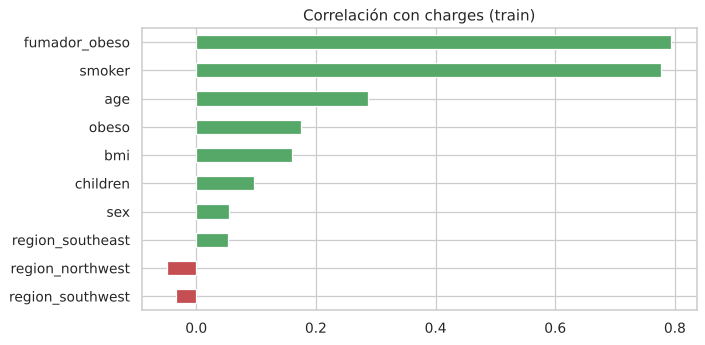

fumador_obeso       0.794
smoker              0.776
age                 0.287
obeso               0.175
bmi                 0.160
children            0.096
sex                 0.055
region_southeast    0.052
region_northwest   -0.049
region_southwest   -0.034


In [66]:
corr_obj = X_train_i2.corrwith(y_train_i).sort_values(key=abs, ascending=False)
corr_obj.plot(kind="barh", figsize=(8, 4), color=np.where(corr_obj > 0, "#55A868", "#C44E52"), title="Correlación con charges (train)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(corr_obj.round(3).to_string())

La nueva variable **`fumador_obeso` (0,79)** es la **más correlacionada** con el costo, incluso más que `smoker` (0,78): la binarización capturó bien el salto. `sex`, `children` y las regiones tienen correlación muy baja.

### B4.2 Técnica de Feature Importance elegida: importancia con Random Forest

**Cómo funciona:** un **Random Forest** entrena muchos árboles de decisión, cada uno con una muestra distinta de filas y de variables. Cada vez que un árbol usa una variable para hacer un corte, el error (la varianza de `charges` dentro de cada grupo) baja. La **importancia** de una variable es cuánto baja el error, en promedio, en todos los cortes en los que se usó. Las importancias suman 1.

**Por qué la elegimos:** a diferencia de la correlación (que sólo mide relaciones lineales de a una variable), los árboles **capturan relaciones no lineales e interacciones**, como el salto del costo en los fumadores con obesidad que encontramos en el EDA. Además no necesita escalar las variables.

**Criterio de selección:** conservamos las variables con **importancia de al menos 1 %**. Después verificamos con validación cruzada que agregar más variables, en el orden de importancia, no mejora el error.


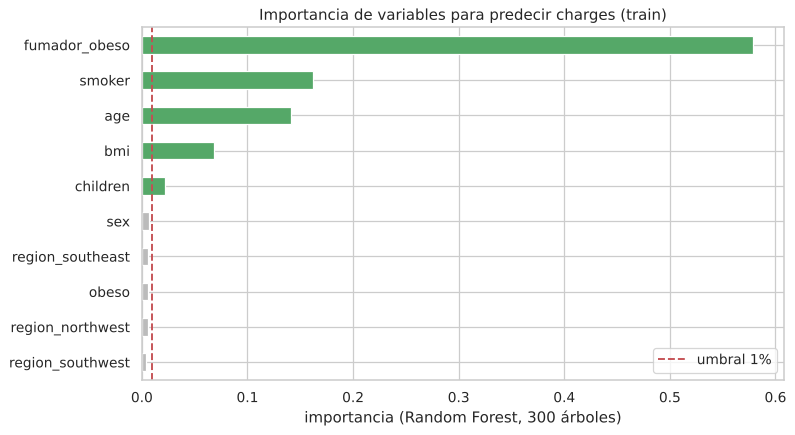

Variables seleccionadas (importancia >= 1%): ['age', 'bmi', 'children', 'smoker', 'fumador_obeso']


,importancia,importancia acumulada,seleccionada
fumador_obeso,0.579,0.579,True
smoker,0.162,0.741,True
age,0.141,0.882,True
bmi,0.069,0.950,True
children,0.022,0.972,True
sex,0.007,0.979,False
region_southeast,0.006,0.985,False
obeso,0.006,0.991,False
region_northwest,0.006,0.996,False
region_southwest,0.004,1.000,False


In [67]:
rf_i = RandomForestRegressor(n_estimators=300, random_state=SEED).fit(X_train_i2, y_train_i)
imp_i = pd.Series(rf_i.feature_importances_, index=features_i2).sort_values(ascending=False)

UMBRAL_IMP = 0.01
seleccion_i = [f for f in features_i2 if imp_i[f] >= UMBRAL_IMP]     # mismo orden que las columnas

fig, ax = plt.subplots(figsize=(9, 5))
imp_i.sort_values().plot(kind="barh", ax=ax, color=["#55A868" if v >= UMBRAL_IMP else "#BBBBBB" for v in imp_i.sort_values()])
ax.axvline(UMBRAL_IMP, ls="--", color="#C44E52", label=f"umbral {UMBRAL_IMP:.0%}")
ax.set_xlabel("importancia (Random Forest, 300 árboles)"); ax.set_title("Importancia de variables para predecir charges (train)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Variables seleccionadas (importancia >= {UMBRAL_IMP:.0%}): {seleccion_i}")
pd.DataFrame({"importancia": imp_i, "importancia acumulada": imp_i.cumsum(), "seleccionada": imp_i >= UMBRAL_IMP}).round(3)

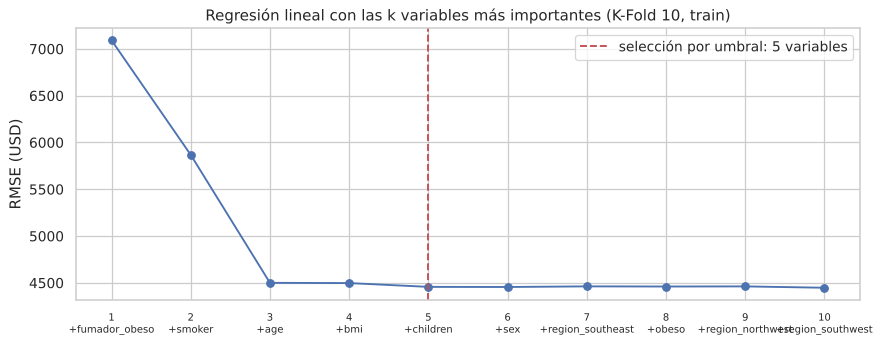

top 1 (+fumador_obeso)        7092.0
top 2 (+smoker)               5867.0
top 3 (+age)                  4500.0
top 4 (+bmi)                  4497.0
top 5 (+children)             4457.0
top 6 (+sex)                  4456.0
top 7 (+region_southeast)     4462.0
top 8 (+obeso)                4461.0
top 9 (+region_northwest)     4462.0
top 10 (+region_southwest)    4448.0


In [68]:
# Verificación: regresión lineal con las k variables más importantes (k = 1 a 10), K-Fold 10 en train
orden_imp_i = imp_i.index.tolist()
rmse_top_i = [np.sqrt(-cross_val_score(make_pipeline(StandardScaler(), LinearRegression()), X_train_i2[orden_imp_i[:k]], y_train_i,
                                       cv=kf_i, scoring="neg_mean_squared_error").mean()) for k in range(1, len(orden_imp_i) + 1)]
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(orden_imp_i) + 1), rmse_top_i, marker="o")
plt.axvline(len(seleccion_i), ls="--", color="#C44E52", label=f"selección por umbral: {len(seleccion_i)} variables")
plt.xticks(range(1, len(orden_imp_i) + 1), [f"{k}\n+{v}" for k, v in enumerate(orden_imp_i, 1)], fontsize=8)
plt.ylabel("RMSE (USD)"); plt.title("Regresión lineal con las k variables más importantes (K-Fold 10, train)")
plt.legend(); plt.tight_layout(); plt.show()
print(pd.Series(rmse_top_i, index=[f"top {k} (+{v})" for k, v in enumerate(orden_imp_i, 1)], name="RMSE (USD)").round(0).to_string())

**Lectura:**
- `fumador_obeso` concentra el **58 %** de la importancia, seguida por `smoker` (16 %) y `age` (14 %): entre las tres suman el 88 %. Coincide con el EDA y con la correlación de B4.1.
- Con el umbral de 1 % se seleccionan **5 variables**: `age`, `bmi`, `children`, `smoker` y `fumador_obeso`. Quedan afuera `sex`, `obeso` y las tres regiones (menos de 1 % cada una). `obeso` sobra porque su información ya está en `bmi` y en `fumador_obeso`.
- **Verificación:** con esas 5 variables la regresión lineal tiene un RMSE de ~4.457 USD. Agregar las otras 5, en orden de importancia, lo mueve menos de 10 USD (con las 10: 4.448 USD), frente a un desvío entre folds de ~540 USD. La selección no pierde información.
- Aclaración: la importancia se calculó con todo train y la verificación también usa train, así que es una comprobación orientativa. La evaluación independiente es la de test (B6.1).

### B4.3 PCA sobre las variables del modelo base

Aplicamos PCA sobre las **8 variables del modelo base** (`age`, `sex`, `bmi`, `children`, `smoker` y las 3 dummies de `region`), **no** sobre las variables seleccionadas en B4.2 ni sobre las creadas en B3.4, como pide la consigna. Antes de PCA **estandarizamos las 8 variables**: PCA busca las direcciones de mayor varianza, y sin escalar quedaría dominado por `age` y `bmi`, que tienen los números más grandes. Conservamos los componentes que explican el **90 % de la varianza**.

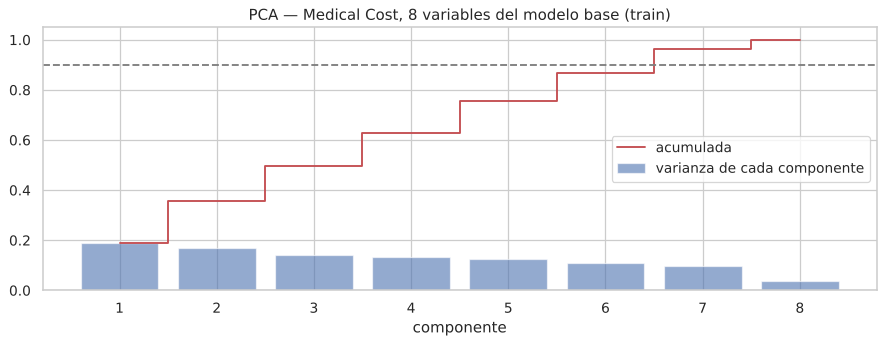

Varianza acumulada por componente: [0.19  0.358 0.497 0.63  0.755 0.866 0.962 1.   ]
Componentes para el 90 %: 7 de 8

Cargas de las tres primeras componentes:


,PC1,PC2,PC3
age,0.023,0.092,0.719
sex,-0.013,-0.142,-0.025
bmi,0.480,0.038,0.372
children,-0.055,-0.001,0.313
smoker,0.073,-0.104,-0.445
region_northwest,-0.508,-0.528,0.193
region_southeast,0.694,-0.248,-0.082
region_southwest,-0.141,0.787,-0.061


In [69]:
pca_pipe_i = make_pipeline(StandardScaler(), PCA()).fit(X_train_i[features_i])     # 8 variables del modelo base, sólo train
pca_i = pca_pipe_i[-1]
var_acum_i = np.cumsum(pca_i.explained_variance_ratio_)
n90_i = int(np.argmax(var_acum_i >= 0.90) + 1)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(var_acum_i) + 1), pca_i.explained_variance_ratio_, alpha=.6, label="varianza de cada componente")
plt.step(range(1, len(var_acum_i) + 1), var_acum_i, where="mid", color="#C44E52", label="acumulada")
plt.axhline(0.9, ls="--", color="gray"); plt.legend(); plt.xlabel("componente"); plt.title("PCA — Medical Cost, 8 variables del modelo base (train)")
plt.tight_layout(); plt.show()
print("Varianza acumulada por componente:", np.round(var_acum_i, 3))
print(f"Componentes para el 90 %: {n90_i} de {len(features_i)}")

cargas_i = pd.DataFrame(pca_i.components_[:3].T, index=features_i, columns=["PC1", "PC2", "PC3"])
print("\nCargas de las tres primeras componentes:")
cargas_i.round(3)

**Lectura:**
- Hacen falta **7 de 8 componentes** para llegar al 90 % de la varianza: casi no hay reducción. Pasa porque las 8 variables del modelo base están **poco correlacionadas entre sí** (edad, sexo, IMC, hijos y fumar son casi independientes), así que cada una aporta información propia.
- Las dos primeras componentes están dominadas por las **dummies de región** y por `bmi`; `smoker`, la variable que más explica el costo, recién pesa en la **tercera** componente, junto con la edad. PCA ordena según la **varianza de las variables de entrada**, no según su relación con `charges`: lo que más varía no es necesariamente lo que mejor predice.
- Como en clasificación, cada componente combina variables y se pierde la interpretación ("fumar" deja de ser una columna).

### B4.4 Comparación de las alternativas (validación cruzada en train)

Comparamos con K-Fold (k=10) cuatro algoritmos de regresión de la clase 29-30 —regresión lineal, k-NN, árbol y SVR (con Box-Cox sobre `charges`, porque sin ella no funciona, ver B5.1)— en estas alternativas:

| Alternativa | Variables que recibe el modelo |
|---|---|
| **1. Modelo base** | Las 8 variables originales (codificadas) |
| **2. Feature Importance (Random Forest)** | Las variables seleccionadas en B4.2 (incluye `fumador_obeso`) |
| **3. PCA** | Las componentes principales calculadas sobre las 8 variables del modelo base |
| *Base + ingeniería* | *Las 8 originales + `obeso` y `fumador_obeso` (10 variables)* |

Agregamos la cuarta fila porque la selección de B4.2 se hizo sobre las 10 variables: así podemos separar cuánto aporta **crear** variables (B3.4) y cuánto aporta **seleccionarlas**. Estandarización (y PCA, cuando corresponde) van dentro del Pipeline.

RMSE medio en USD (K-Fold 10, train):


,1. Base (8 var.),2. Selección RF (5 var.),3. PCA (7 comp.),Base + ingeniería (10 var.)
LiR,6067.0,4457.0,6073.0,4448.0
KNN (k=5),5508.0,4866.0,5497.0,4873.0
CART (max_depth=4),4700.0,4697.0,6691.0,4703.0
SVR rbf + Box-Cox(y),5019.0,4535.0,5072.0,4613.0


R² medio (K-Fold 10, train):


,1. Base (8 var.),2. Selección RF (5 var.),3. PCA (7 comp.),Base + ingeniería (10 var.)
LiR,0.719,0.849,0.718,0.850
KNN (k=5),0.768,0.821,0.769,0.819
CART (max_depth=4),0.833,0.832,0.662,0.832
SVR rbf + Box-Cox(y),0.810,0.845,0.807,0.840


Desvío típico del RMSE entre folds: 585 USD


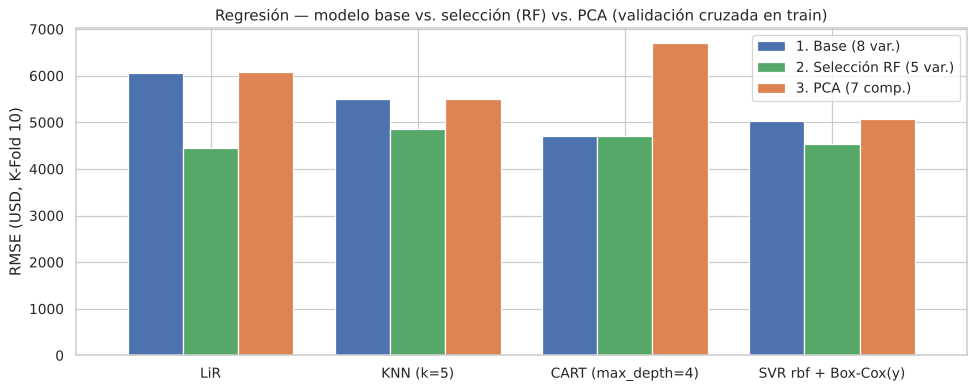

In [70]:
def armar_reg(modelo, n_comp=None, boxcox=False):
    """Estandarización (+ PCA si se pide) + modelo; opcionalmente Box-Cox sobre charges."""
    pipe = make_pipeline(*([StandardScaler()] + ([PCA(n_components=n_comp)] if n_comp else []) + [modelo]))
    return TransformedTargetRegressor(regressor=pipe, transformer=PowerTransformer(method="box-cox")) if boxcox else pipe

fabricas_i = {"LiR": lambda: LinearRegression(),
              "KNN (k=5)": lambda: KNeighborsRegressor(),
              "CART (max_depth=4)": lambda: DecisionTreeRegressor(max_depth=4, random_state=SEED),
              "SVR rbf + Box-Cox(y)": lambda: SVR()}

alternativas_i = {f"1. Base ({len(features_i)} var.)": (features_i, None),
                  f"2. Selección RF ({len(seleccion_i)} var.)": (seleccion_i, None),
                  f"3. PCA ({n90_i} comp.)": (features_i, n90_i),
                  f"Base + ingeniería ({len(features_i2)} var.)": (features_i2, None)}

rmse_alt_i, r2_alt_i, desv_alt_i = {}, {}, {}
for alt, (cols, n_comp) in alternativas_i.items():
    rmse_alt_i[alt], r2_alt_i[alt], desv_alt_i[alt] = {}, {}, {}
    for nombre, fab in fabricas_i.items():
        r = cross_validate(armar_reg(fab(), n_comp, boxcox="Box-Cox" in nombre), X_train_i2[cols], y_train_i, cv=kf_i, scoring=SCORING_REG)
        rmse_alt_i[alt][nombre] = np.sqrt(-r["test_neg_mse"].mean())
        desv_alt_i[alt][nombre] = np.sqrt(-r["test_neg_mse"]).std()
        r2_alt_i[alt][nombre] = r["test_r2"].mean()
rmse_alt_i, r2_alt_i, desv_alt_i = pd.DataFrame(rmse_alt_i), pd.DataFrame(r2_alt_i), pd.DataFrame(desv_alt_i)

print("RMSE medio en USD (K-Fold 10, train):"); display(rmse_alt_i.round(0))
print("R² medio (K-Fold 10, train):"); display(r2_alt_i.round(3))
print(f"Desvío típico del RMSE entre folds: {desv_alt_i.values.mean():,.0f} USD")

tres_i = list(alternativas_i)[:3]
ax = rmse_alt_i[tres_i].plot(kind="bar", figsize=(11, 4.5), color=["#4C72B0", "#55A868", "#DD8452"], width=0.8)
ax.set_ylabel("RMSE (USD, K-Fold 10)"); ax.set_xlabel(""); ax.set_title("Regresión — modelo base vs. selección (RF) vs. PCA (validación cruzada en train)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Decisión:**
- **Selección (RF) vs. modelo base:** la mejora es grande en la regresión lineal (RMSE de ~6.070 a ~4.460 USD; R² de 0,72 a 0,85), en k-NN y en SVR. Pero esa mejora viene sobre todo de **`fumador_obeso`**, la variable creada en B3.4: la fila "base + ingeniería" (10 variables) rinde igual que la selección (4.448 vs. 4.457 USD). Es decir, **crear la variable** aporta mucho, y **seleccionar** permite quedarse con la mitad de las variables sin perder nada.
- **PCA** no mejora en ningún algoritmo. Con la regresión lineal da lo mismo que el modelo base (6.073 vs. 6.067 USD; con 7 de 8 componentes casi no hay reducción) y con el árbol **empeora mucho** (4.700 → 6.691 USD): el árbol ya no puede hacer el corte simple "¿fuma?", porque esa información quedó repartida entre varias componentes.
- El **árbol** rinde igual con las 8 originales que con la selección (~4.700 USD): descubre solo la interacción fumador × IMC con cortes sucesivos.

**Usamos las 5 variables seleccionadas** (`age`, `bmi`, `children`, `smoker`, `fumador_obeso`) en el resto del trabajo (B5 a B7): mismo error que con 10, modelo más simple, y quedan afuera `sex` y la región, que casi no aportan. **No usamos PCA.**

## B5. Modelado y comparación de algoritmos

### B5.1 Comprobación puntual de los regresores

Evaluamos los algoritmos de regresión de la clase 29-30 con K-Fold (k=10, `shuffle=True`, `random_state=7`) sobre train, en tres escenarios:
1. **Sin escalar** (variables originales codificadas).
2. **Con estandarización** (Pipeline con `StandardScaler`).
3. **Con estandarización + Box-Cox sobre `charges`** (`TransformedTargetRegressor`).

Todos con las variables seleccionadas en B4. Métricas: **Neg MSE** (como en el notebook de clase), su raíz **RMSE** (en dólares, más fácil de interpretar), **MAE** y **R²**.

In [71]:
X_train_i_sel = X_train_i2[seleccion_i]
X_test_i_sel = X_test_i2[seleccion_i]

def regresores_base():
    return {"LiR": LinearRegression(), "Ridge": Ridge(), "LASSO": Lasso(), "ElasticNet": ElasticNet(),
            "KNN": KNeighborsRegressor(), "CART": DecisionTreeRegressor(random_state=SEED), "SVR": SVR()}

def con_boxcox(modelo):
    return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(), modelo),
                                      transformer=PowerTransformer(method="box-cox"))

r1, f1_ = comparar_regresores(regresores_base(), X_train_i_sel, y_train_i, kf_i)
r2, f2_ = comparar_regresores({n: make_pipeline(StandardScaler(), m) for n, m in regresores_base().items()}, X_train_i_sel, y_train_i, kf_i)
r3, f3_ = comparar_regresores({n: con_boxcox(m) for n, m in regresores_base().items()}, X_train_i_sel, y_train_i, kf_i)

tabla_i = pd.DataFrame({"RMSE sin escalar": r1["RMSE"], "RMSE estandarizado": r2["RMSE"], "RMSE std + Box-Cox(y)": r3["RMSE"],
                        "R2 sin escalar": r1["R2"], "R2 estandarizado": r2["R2"], "R2 std + Box-Cox(y)": r3["R2"]})
tabla_i.sort_values("RMSE estandarizado").round(3)

,RMSE sin escalar,RMSE estandarizado,RMSE std + Box-Cox(y),R2 sin escalar,R2 estandarizado,R2 std + Box-Cox(y)
modelo,,,,,,
Ridge,4457.560,4456.821,8083.179,0.849,0.849,0.530
LASSO,4456.848,4456.839,12318.339,0.849,0.849,-0.123
LiR,4456.845,4456.845,8100.891,0.849,0.849,0.528
KNN,10683.998,4865.899,4642.495,0.156,0.821,0.838
ElasticNet,8482.096,5207.991,11575.423,0.464,0.795,0.010
CART,6649.946,6625.976,6586.734,0.662,0.665,0.670
SVR,12242.973,12204.805,4535.186,-0.109,-0.102,0.845


**Lectura (el preprocesamiento hay que elegirlo según el algoritmo):**
- **Modelos lineales (LiR, Ridge, LASSO):** son los mejores (RMSE ~4.457 USD, R² 0,85). Estandarizar no les cambia nada (en la regresión lineal los coeficientes se ajustan a la escala).
- **k-NN:** sin escalar es muy malo (R² 0,16) y **con estandarización pasa a R² 0,82**. Sin escalar, la distancia está dominada por `age` y `bmi` (valores de 18 a 64) y `smoker`, que vale 0 o 1, casi no cuenta… ¡cuando es la variable más importante!
- **SVR:** sin transformar `charges` tiene R² negativo (peor que predecir siempre el promedio). Sus hiperparámetros por defecto (`C=1`, `epsilon=0.1`) están pensados para una variable objetivo de escala chica, y `charges` está en miles de dólares: el modelo casi no se mueve de una constante. **Con Box-Cox sobre `charges`, SVR pasa a R² 0,85.**
- **Box-Cox sobre `charges` empeora a los lineales** (RMSE de 4.457 a 8.100). En escala Box-Cox (casi logarítmica) los efectos se vuelven multiplicativos, pero en este dataset son **aditivos en dólares** (fumar suma una cantidad casi fija); además, al volver a dólares, los errores en los costos altos se agrandan. LASSO y ElasticNet directamente colapsan: con la variable objetivo estandarizada, `alpha=1` es una penalización enorme y lleva todos los coeficientes a 0.
- **CART** sin límite de profundidad se sobreajusta (RMSE ~6.600): lo ajustamos en B5.2.

### B5.2 Ajuste de hiperparámetros

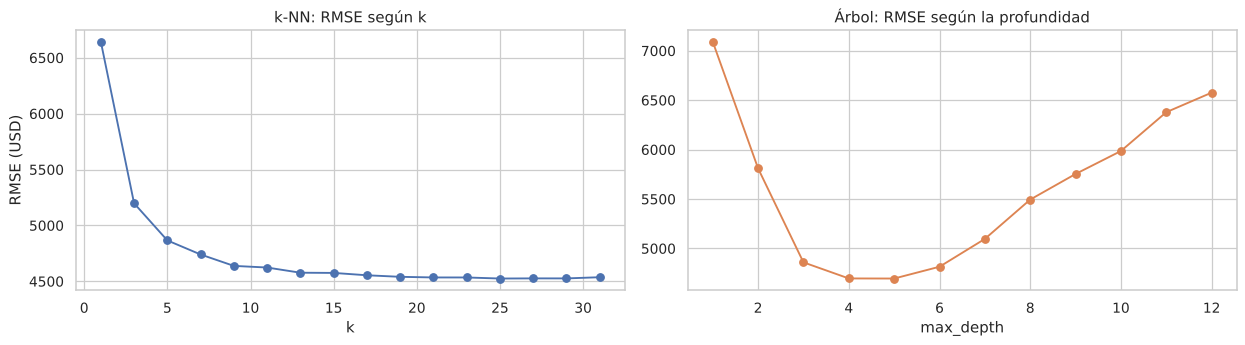

Mejor k: 25 (RMSE 4,525) | Mejor max_depth: 5 (RMSE 4,696)


In [72]:
ks_r = list(range(1, 32, 2))
rmse_k = [np.sqrt(-cross_val_score(make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k)),
                                   X_train_i_sel, y_train_i, cv=kf_i, scoring="neg_mean_squared_error").mean()) for k in ks_r]
profs = list(range(1, 13))
rmse_d = [np.sqrt(-cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=SEED),
                                   X_train_i_sel, y_train_i, cv=kf_i, scoring="neg_mean_squared_error").mean()) for d in profs]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ks_r, rmse_k, marker="o"); axes[0].set_xlabel("k"); axes[0].set_ylabel("RMSE (USD)"); axes[0].set_title("k-NN: RMSE según k")
axes[1].plot(profs, rmse_d, marker="o", color="#DD8452"); axes[1].set_xlabel("max_depth"); axes[1].set_title("Árbol: RMSE según la profundidad")
plt.tight_layout(); plt.show()
mejor_k_i = ks_r[int(np.argmin(rmse_k))]; mejor_d_i = profs[int(np.argmin(rmse_d))]
print(f"Mejor k: {mejor_k_i} (RMSE {min(rmse_k):,.0f}) | Mejor max_depth: {mejor_d_i} (RMSE {min(rmse_d):,.0f})")

El gráfico del árbol muestra claramente el **sobreajuste (overfitting)**: con poca profundidad el árbol es demasiado simple (sub-ajuste), el error baja hasta un mínimo y después **vuelve a subir** a medida que el árbol se hace más profundo y empieza a memorizar el ruido de train.

In [73]:
variantes_i = {
    "LiR": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge alpha=1": make_pipeline(StandardScaler(), Ridge(alpha=1)),
    "Ridge alpha=10": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "LASSO alpha=100": make_pipeline(StandardScaler(), Lasso(alpha=100)),
    "LassoCV": make_pipeline(StandardScaler(), LassoCV(cv=5)),
    "ElasticNet alpha=0.1 l1_ratio=0.5": make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5)),
    "ElasticNet alpha=0.1 l1_ratio=0.9": make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.9)),
    f"KNN k={mejor_k_i}": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=mejor_k_i)),
    f"KNN k={mejor_k_i} distance p=1": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=mejor_k_i, weights="distance", p=1)),
    "CART (sin límite)": DecisionTreeRegressor(random_state=SEED),
    f"CART max_depth={mejor_d_i}": DecisionTreeRegressor(max_depth=mejor_d_i, random_state=SEED),
    f"CART max_depth={mejor_d_i} absolute_error": DecisionTreeRegressor(max_depth=mejor_d_i, criterion="absolute_error", random_state=SEED),
    f"CART max_depth={mejor_d_i} poisson": DecisionTreeRegressor(max_depth=mejor_d_i, criterion="poisson", random_state=SEED),
    "CART min_samples_leaf=20": DecisionTreeRegressor(min_samples_leaf=20, random_state=SEED),
    "SVR rbf C=1 + Box-Cox(y)": con_boxcox(SVR()),
    "SVR rbf C=10 + Box-Cox(y)": con_boxcox(SVR(C=10)),
    "SVR linear + Box-Cox(y)": con_boxcox(SVR(kernel="linear")),
    "SVR poly + Box-Cox(y)": con_boxcox(SVR(kernel="poly")),
}
res_var_i, folds_var_i = comparar_regresores(variantes_i, X_train_i_sel, y_train_i, kf_i)
res_var_i.round(3)

,Neg MSE,RMSE,RMSE (desv),MAE,R2
modelo,,,,,
Ridge alpha=1,-1.986e+07,4456.821,537.172,2472.718,0.849
LiR,-1.986e+07,4456.845,537.120,2471.391,0.849
LassoCV,-1.986e+07,4456.860,536.677,2473.772,0.849
ElasticNet alpha=0.1 l1_ratio=0.9,-1.987e+07,4457.194,537.558,2482.945,0.849
Ridge alpha=10,-1.987e+07,4457.390,537.650,2485.275,0.849
LASSO alpha=100,-1.990e+07,4460.898,532.342,2501.866,0.849
ElasticNet alpha=0.1 l1_ratio=0.5,-1.998e+07,4470.013,539.524,2541.459,0.848
KNN k=25,-2.048e+07,4525.009,552.945,2513.975,0.845
SVR rbf C=1 + Box-Cox(y),-2.057e+07,4535.186,627.590,1865.445,0.845


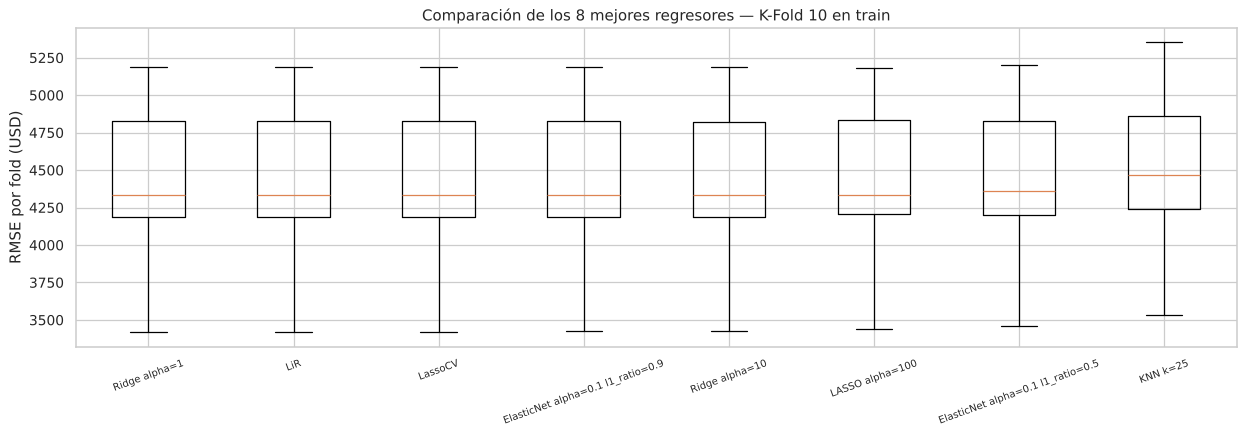

In [74]:
top_i = res_var_i.index[:8].tolist()
plt.figure(figsize=(14, 5))
plt.boxplot([np.sqrt(-folds_var_i[n]["test_neg_mse"]) for n in top_i], tick_labels=[n.replace(" + ", "\n+ ") for n in top_i])
plt.ylabel("RMSE por fold (USD)"); plt.xticks(fontsize=8, rotation=20)
plt.title("Comparación de los 8 mejores regresores — K-Fold 10 en train"); plt.tight_layout(); plt.show()

### B5.3 Análisis de la comparación

- Los **modelos lineales** (LiR, Ridge, LassoCV, ElasticNet con l1_ratio alto) quedan primeros y **prácticamente iguales** (RMSE ~4.457 USD, R² 0,849). La regularización no aporta porque hay pocas variables y no hay multicolinealidad.
- **k-NN (k=25)**, **SVR rbf con Box-Cox** y **CART con profundidad 5** quedan muy cerca (RMSE entre 4.525 y 4.700). La diferencia entre el 1º y el 12º es de ~250 USD, **menos de la mitad del desvío entre folds (~540 USD)**: en la práctica es un **empate técnico**, como se ve en los boxplots superpuestos.
- **SVR tiene el MAE más bajo (~1.865 USD vs. ~2.470 de la regresión lineal)**: para la mayoría de las personas (no fumadores, costos bajos) predice mejor, pero comete errores más grandes en algunos casos caros, y el RMSE castiga más esos errores grandes. Elegir entre MAE y RMSE depende de si nos preocupan más los errores grandes (RMSE) o el error típico (MAE).
- El criterio `poisson`, que era el mejor árbol en Boston, acá no mejora. `absolute_error` baja el MAE del árbol, porque cada hoja predice la mediana en vez de la media.
- SVR con kernel lineal o polinómico rinde mal.

Pasan a la evaluación final: la regresión lineal, el mejor k-NN, el mejor árbol y SVR con Box-Cox. Agregamos la **regresión lineal sin ingeniería de variables** (8 variables originales) para medir cuánto aportó la binarización.

## B6. Evaluación final en el conjunto de prueba

In [75]:
finalistas_i = {
    f"CART max_depth={mejor_d_i}": DecisionTreeRegressor(max_depth=mejor_d_i, random_state=SEED),
    "SVR rbf C=10 + Box-Cox(y)": con_boxcox(SVR(C=10)),
    f"KNN k={mejor_k_i}": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=mejor_k_i)),
    "LiR (con fumador_obeso)": make_pipeline(StandardScaler(), LinearRegression()),
    "LiR sin ingeniería (8 variables originales)": make_pipeline(StandardScaler(), LinearRegression()),
}
filas, preds_i = [], {}
for nombre, modelo in finalistas_i.items():
    Xtr, Xte = (X_train_i, X_test_i) if "sin ingeniería" in nombre else (X_train_i_sel, X_test_i_sel)
    modelo.fit(Xtr, y_train_i)
    pred = modelo.predict(Xte)
    preds_i[nombre] = pred
    filas.append({"modelo": nombre, "MAE": mean_absolute_error(y_test_i, pred),
                  "RMSE": np.sqrt(mean_squared_error(y_test_i, pred)), "R2": r2_score(y_test_i, pred)})
test_i = pd.DataFrame(filas).set_index("modelo").sort_values("RMSE")
print(f"Referencia: predecir siempre la media de train → RMSE = {np.sqrt(mean_squared_error(y_test_i, np.full(len(y_test_i), y_train_i.mean()))):,.0f} USD")
test_i.round(3)

Referencia: predecir siempre la media de train → RMSE = 13,106 USD


,MAE,RMSE,R2
modelo,,,
LiR (con fumador_obeso),2458.263,4582.103,0.877
KNN k=25,2556.782,4626.260,0.875
CART max_depth=5,2636.853,4757.451,0.868
SVR rbf C=10 + Box-Cox(y),2024.218,4825.895,0.864
LiR sin ingeniería (8 variables originales),4181.816,6240.206,0.772


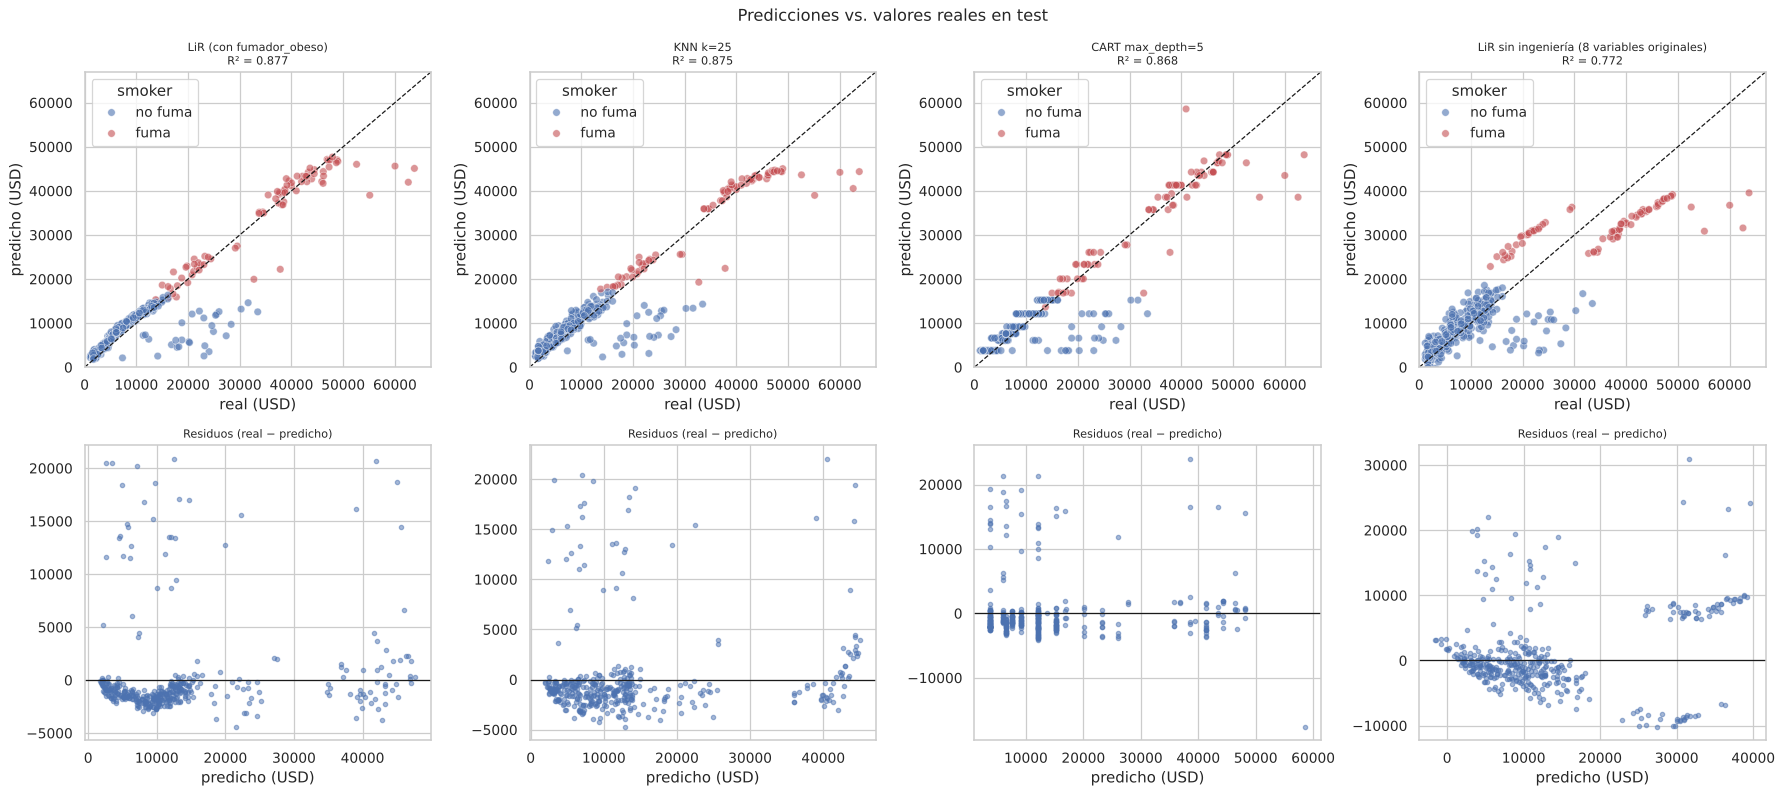

In [76]:
modelos_graf = test_i.index[:3].tolist() + ["LiR sin ingeniería (8 variables originales)"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fum_test = X_test_i["smoker"].map({0: "no fuma", 1: "fuma"})
for j, nombre in enumerate(modelos_graf):
    ax = axes[0, j]
    sns.scatterplot(x=y_test_i, y=preds_i[nombre], hue=fum_test, alpha=.6, ax=ax, palette={"no fuma": "#4C72B0", "fuma": "#C44E52"})
    lim = [0, max(y_test_i.max(), preds_i[nombre].max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{nombre}\nR² = {test_i.loc[nombre, 'R2']:.3f}", fontsize=9); ax.set_xlabel("real (USD)"); ax.set_ylabel("predicho (USD)")
    ax = axes[1, j]
    resid = y_test_i - preds_i[nombre]
    ax.scatter(preds_i[nombre], resid, alpha=.5, s=12); ax.axhline(0, color="k", lw=1)
    ax.set_title("Residuos (real − predicho)", fontsize=9); ax.set_xlabel("predicho (USD)")
plt.suptitle("Predicciones vs. valores reales en test", fontsize=13); plt.tight_layout(); plt.show()

**Interpretación de la evaluación en test:**
- Todos los finalistas explican entre el **86 % y el 88 % de la variación del costo** (R²), frente a un RMSE de ~13.100 USD si predijéramos siempre el promedio.
- La **regresión lineal con `fumador_obeso`** es la mejor en RMSE (**~4.580 USD**) y R² (**0,877**), y su resultado es coherente con la validación cruzada (4.457): **no hay sobreajuste**.
- La **misma regresión lineal sin la ingeniería de variables** tiene RMSE ~6.240 y R² 0,77. **La binarización del IMC y la interacción con fumar redujeron el error un 27 %**: la mejora más grande del trabajo no vino de cambiar de algoritmo sino de **entender los datos** en el EDA.
- **SVR con Box-Cox** vuelve a tener el **menor MAE (~2.020 USD)** pero el mayor RMSE de los finalistas.
- **Residuos:** no hay errores grandes por sobreestimación, pero hay un grupo de personas (34 de 402, en su mayoría **no fumadoras**) con costos reales **más de 5.000 USD por encima** de lo predicho. Son los puntos que quedan por encima de la línea diagonal y se ven como una "banda" en los gráficos de residuos. Probablemente sean personas con alguna enfermedad o internación que **no está registrada en el dataset**: ningún modelo puede predecirlas con estas variables (es una limitación de los datos, no del algoritmo).

### B6.1 Las tres alternativas en el conjunto de prueba

Evaluamos en test las **tres alternativas** con la **regresión lineal**: modelo base (8 variables), variables seleccionadas por importancia con Random Forest, y PCA sobre las variables del modelo base. Agregamos la referencia "base + ingeniería" (10 variables).

In [77]:
filas = []
for alt, (cols, n_comp) in alternativas_i.items():
    modelo = armar_reg(LinearRegression(), n_comp).fit(X_train_i2[cols], y_train_i)
    pred = modelo.predict(X_test_i2[cols])
    filas.append({"alternativa": alt, "MAE": mean_absolute_error(y_test_i, pred),
                  "RMSE": np.sqrt(mean_squared_error(y_test_i, pred)), "R2": r2_score(y_test_i, pred)})
alt_test_i = pd.DataFrame(filas).set_index("alternativa")
print("Regresión lineal en test — alternativas:")
alt_test_i.round(3)

Regresión lineal en test — alternativas:


,MAE,RMSE,R2
alternativa,,,
1. Base (8 var.),4181.816,6240.206,0.772
2. Selección RF (5 var.),2458.263,4582.103,0.877
3. PCA (7 comp.),4178.128,6254.150,0.771
Base + ingeniería (10 var.),2465.244,4544.336,0.879


**Resultado en test:** se confirma lo de la validación cruzada. La regresión lineal con las **5 variables seleccionadas** tiene un RMSE de ~4.580 USD y un R² de 0,877, contra ~6.240 USD y 0,772 del **modelo base**: el error baja un 27 %. **PCA** (7 componentes) da prácticamente lo mismo que el modelo base (RMSE ~6.250 USD; R² 0,771): en un modelo lineal, combinar las variables en componentes no agrega información. La referencia con las 10 variables queda en ~4.540 USD, a menos de 40 USD de la selección: la selección no perdió información relevante.

### B6.2 Interpretación del árbol

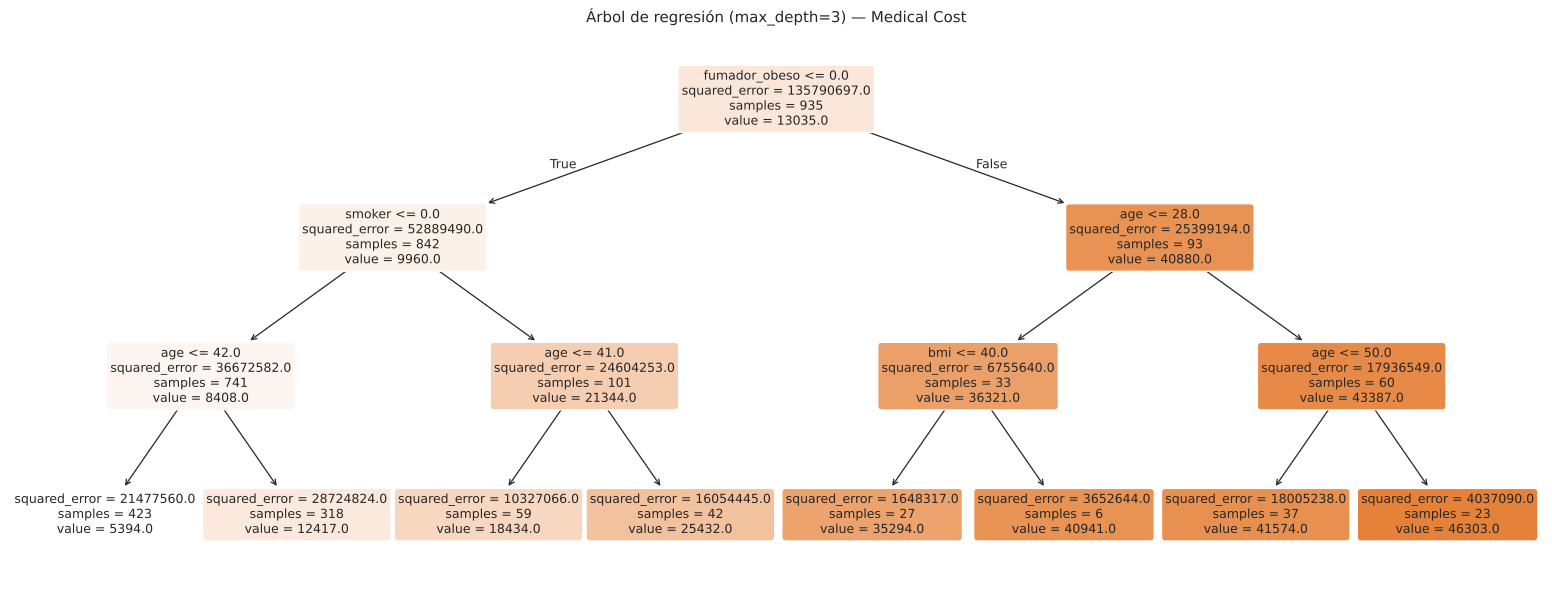

In [78]:
arbol_i = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(X_train_i_sel, y_train_i)
plt.figure(figsize=(22, 8))
plot_tree(arbol_i, feature_names=seleccion_i, filled=True, rounded=True, fontsize=10, precision=0)
plt.title("Árbol de regresión (max_depth=3) — Medical Cost"); plt.show()

El árbol cuenta la misma historia en forma de reglas: la **primera pregunta es si la persona es fumadora con obesidad** (`fumador_obeso`); después, si fuma, y después, la **edad**. Las hojas van de ~5.400 USD (no fumadores menores de 43 años) a ~46.300 USD (fumadores con obesidad mayores de 50).

## B7. Modelo final y predicción de casos nuevos

**Modelo elegido: regresión lineal con las 5 variables seleccionadas** (incluida `fumador_obeso`). Tuvo el menor RMSE en test, empata con los mejores en validación cruzada, es el más simple y, sobre todo, es **interpretable**: cada coeficiente dice cuántos dólares suma cada factor, algo muy valioso para explicar una prima en una aseguradora.

Lo reentrenamos con **todos los datos** (train + test). Para leer los coeficientes en dólares lo ajustamos sin estandarizar (en la regresión lineal las predicciones son las mismas con o sin escalado).

In [79]:
X_i_full = agregar_obesidad(X_i)[seleccion_i]
modelo_final_i = LinearRegression().fit(X_i_full, y_i)
print(f"Término independiente (β0): {modelo_final_i.intercept_:,.0f} USD")
pd.Series(modelo_final_i.coef_, index=seleccion_i, name="USD que suma cada unidad").round(0).to_frame()

Término independiente (β0): -3,954 USD


,USD que suma cada unidad
age,264.0
bmi,47.0
children,500.0
smoker,13567.0
fumador_obeso,19530.0


**Lectura de los coeficientes:**
- Cada **año de edad** suma ~264 USD al costo anual; cada **hijo**, ~500 USD; cada punto de **IMC**, apenas ~47 USD.
- **Fumar** suma ~13.600 USD por año.
- Ser **fumador con obesidad** suma **otros ~19.500 USD** encima de lo anterior: un fumador con IMC > 30 cuesta, en promedio, ~33.000 USD más que un no fumador de la misma edad.

In [80]:
def perfil(age, sex, bmi, children, smoker, region):
    fila = {"age": age, "sex": int(sex == "male"), "bmi": bmi, "children": children, "smoker": int(smoker == "yes"),
            "region_northwest": int(region == "northwest"), "region_southeast": int(region == "southeast"),
            "region_southwest": int(region == "southwest")}
    return agregar_obesidad(pd.DataFrame([fila]))[seleccion_i]

casos = pd.concat([perfil(45, "female", 26.0, 2, "no", "northeast"),
                   perfil(45, "female", 26.0, 2, "yes", "northeast"),
                   perfil(45, "female", 34.0, 2, "yes", "northeast")], ignore_index=True)
casos.index = ["45 años, no fuma, IMC 26", "45 años, fuma, IMC 26", "45 años, fuma, IMC 34"]
casos["costo estimado (USD)"] = modelo_final_i.predict(casos).round(0)
casos

,age,bmi,children,smoker,fumador_obeso,costo estimado (USD)
"45 años, no fuma, IMC 26",45,26.0,2,0,0,10159.0
"45 años, fuma, IMC 26",45,26.0,2,1,0,23726.0
"45 años, fuma, IMC 34",45,34.0,2,1,1,43629.0


---
# Conclusiones

## Resumen comparativo de los modelos

In [81]:
print("CLASIFICACIÓN — Telco Churn (test)")
display(test_t.round(3))
print("\nREGRESIÓN — Medical Cost (test, 402 personas; RMSE de predecir siempre la media ≈ 13.100 USD)")
display(test_i.round(3))

CLASIFICACIÓN — Telco Churn (test)


,accuracy,kappa,AUC,precision (Yes),recall (Yes),F1 (Yes)
modelo,,,,,,
LoR,0.810,0.476,0.848,0.680,0.535,0.599
LoR (balanced),0.752,0.455,0.848,0.521,0.795,0.629
LDA,0.807,0.479,0.845,0.661,0.560,0.606
KNN k=85,0.795,0.455,0.838,0.626,0.561,0.592
SVM rbf (balanced),0.754,0.454,0.829,0.525,0.781,0.628
NB,0.746,0.435,0.824,0.515,0.758,0.613
CART max_depth=6,0.786,0.413,0.817,0.620,0.497,0.552



REGRESIÓN — Medical Cost (test, 402 personas; RMSE de predecir siempre la media ≈ 13.100 USD)


,MAE,RMSE,R2
modelo,,,
LiR (con fumador_obeso),2458.263,4582.103,0.877
KNN k=25,2556.782,4626.260,0.875
CART max_depth=5,2636.853,4757.451,0.868
SVR rbf C=10 + Box-Cox(y),2024.218,4825.895,0.864
LiR sin ingeniería (8 variables originales),4181.816,6240.206,0.772


### Clasificación binaria — *Telco Customer Churn*

1. **Modelo más adecuado: regresión logística** (Yeo-Johnson + estandarización en las numéricas y `class_weight="balanced"`). Tuvo el mejor AUC en validación cruzada y en test (0,85), fue estable entre folds y es interpretable. Con pesos balanceados **detecta 8 de cada 10 clientes que se van**, que es lo que importa en una campaña de retención. LDA quedó prácticamente empatada.
2. **Los modelos lineales ganaron a los no lineales.** SVM con kernel lineal superó al rbf, y el árbol fue el más débil y el más propenso al sobreajuste (AUC 0,65 sin límite → 0,82 con profundidad limitada), aunque sirve para explicar las reglas.
3. **El accuracy no alcanza con clases desbalanceadas.** Decir siempre "No" ya acierta el 73,5 %. Naive Bayes tenía el peor accuracy y el mejor F1: sólo mirando kappa, AUC, F1 y recall se entiende qué modelo sirve para el objetivo.
4. **La limpieza fue clave:** corregir el formato de `TotalCharges`, imputar sus faltantes con un criterio lógico (0 para clientes nuevos) y unificar las categorías redundantes ("No internet service") eliminó correlaciones perfectas y simplificó la codificación. Eliminar `TotalCharges` por redundante no cambió el rendimiento.
5. **Qué explica la baja:** el **contrato mes a mes**, la **poca antigüedad**, la **fibra óptica** y el **pago con cheque electrónico** aumentan el riesgo; los **contratos largos**, la **antigüedad**, la **seguridad online** y el **soporte técnico** lo reducen.
6. **Selección de variables y PCA (nuevas consignas):** RFE redujo de 23 a 13 variables sin perder rendimiento (AUC en test 0,847 contra 0,849 del modelo base). PCA necesitó 13 componentes para el 90 % de la varianza y fue la alternativa más débil (AUC 0,840). Con estos datos, reducir dimensiones no mejora la predicción, pero RFE permite un modelo más simple.

### Regresión — *Medical Cost Personal*

1. **Modelo más adecuado: regresión lineal con la variable de interacción `fumador_obeso`** (RMSE ≈ 4.580 USD, R² ≈ 0,88 en test). k-NN, el árbol y SVR quedaron en un empate técnico muy cerca, pero la regresión lineal es la más simple e interpretable.
2. **La mejora más grande vino del EDA, no del algoritmo.** La matriz de dispersión coloreada por `smoker` reveló que el costo "salta" en los fumadores con IMC > 30. Binarizar el IMC y crear la interacción redujo el error de la regresión lineal un 27 % (R² de 0,77 a 0,88).
3. **Cada algoritmo necesita su propio preprocesamiento:** k-NN sólo funciona con variables escaladas; SVR sólo funciona con la variable objetivo transformada (Box-Cox); y esa misma transformación **empeora** a los modelos lineales. Comparar algoritmos sin preparar los datos para cada uno lleva a conclusiones equivocadas (lo mismo que observamos con Boston en la clase 29-30).
4. **Qué determina el costo:** ser fumador (y más aún fumador con obesidad), seguido de la edad. El sexo y la región casi no influyen.
5. **Selección de variables y PCA (nuevas consignas):** la importancia con Random Forest se quedó con 5 de las 10 variables sin perder precisión. PCA no sirve en este problema: las variables casi no están correlacionadas entre sí (hacen falta 7 de 8 componentes para el 90 % de la varianza) y la regresión lineal con PCA rinde igual que el modelo base (R² 0,77 en test, contra 0,88 con la selección).

### Conclusiones generales

- En los dos problemas, un **modelo lineal bien preparado** fue tan bueno o mejor que los no lineales, con la ventaja de ser explicable. Un algoritmo más complejo no garantiza un mejor resultado.
- El trabajo de **exploración y preparación** (limpieza de duplicados, transformaciones, codificación, ingeniería de variables) tuvo más impacto que la elección del algoritmo.
- **Separar el test al principio**, ajustar las transformaciones sólo con train y usar **Pipelines** dentro de la validación cruzada nos permitió estimaciones honestas: en los dos casos, el resultado en test fue coherente con el de la validación cruzada.

## Limitaciones

- **Clasificación:** es una foto de un solo mes de una sola empresa (datos de ejemplo de IBM): no sabemos cuándo se dio de baja cada cliente ni qué pasó antes (reclamos, cortes de servicio, ofertas de la competencia), que probablemente expliquen muchas bajas.
- **Clasificación:** el AUC de 0,85 es bueno pero no excelente: casi la mitad de los clientes que el modelo balanceado marca como riesgosos no se iban a ir. Con estas variables hay un límite a lo que se puede predecir.
- **Regresión:** faltan variables clave del costo médico (enfermedades previas, internaciones, tipo de cobertura). Eso explica el grupo de personas cuyo costo real supera por mucho la predicción.
- **Regresión:** los datos son de Estados Unidos y de un solo período; no representan a la población de otro país ni el aumento de costos en el tiempo.
- En los dos casos probamos hiperparámetros "a mano" (algunos valores por algoritmo), sin una búsqueda sistemática.

## Posibles mejoras

- **Ajuste sistemático de hiperparámetros** con `GridSearchCV` o `RandomizedSearchCV` (se ve en las próximas clases).
- **Algoritmos de ensamble** (Random Forest, Gradient Boosting), que combinan muchos árboles y suelen mejorar a un árbol solo.
- **Clasificación:** elegir el **umbral de decisión** según el costo real de cada error (en lugar de 0,5), probar técnicas de remuestreo de la clase minoritaria (por ejemplo, SMOTE), crear variables nuevas (por ejemplo, cantidad de servicios contratados) y estimar el **valor del cliente** para priorizar la retención de los más rentables.
- **Regresión:** probar otras interacciones (edad × fumador), modelar por separado fumadores y no fumadores, y conseguir variables de historia clínica.
- Validar los modelos con **datos nuevos** (otras cosechas u otro período) antes de usarlos en producción.

---
## Anexo: temas de la materia aplicados en el trabajo

| Tema (clase) | Dónde se aplicó |
|---|---|
| Python, estructuras de datos y control; funciones (25-26 ago) | Funciones auxiliares, loops de comparación de modelos, diccionarios de modelos |
| NumPy y Pandas (1-2 sep) | Carga, `groupby`, `value_counts`, `get_dummies`, `drop_duplicates`, `np.where` |
| Estadística descriptiva (8-9 sep) | A2.1–A2.4, B2.1–B2.4: `head`, `shape`, `dtypes`, `describe`, `groupby().size()`, `corr`, `skew` |
| Visualización (8-9 sep) | Histogramas, densidad, boxplots, matriz de correlación, matriz de dispersión (por clase), boxplots por clase |
| Transformación de datos (8-9 sep) | A3.3 comparación de MinMax, Standard, Normalizer, Binarizer (antigüedad ≤ 12 meses), Box-Cox (no aplicable por ceros) y Yeo-Johnson; A3.4 Yeo-Johnson + estandarización con `make_column_transformer`; B3.3 Box-Cox en `charges`; B3.4 estandarización y binarización del IMC |
| Preprocesamiento y limpieza (18-19 ago) | Columna numérica guardada como texto, imputación de faltantes, categorías redundantes, duplicados, atípicos (IQR); codificación Label, One-Hot y Target Encoding |
| Métodos de remuestreo (15-16 sep) | `train_test_split`, A5: ShuffleSplit, K-Fold, K-Fold estratificado, repetido, LOOCV |
| Evaluación de algoritmos (15-16 sep) | Accuracy, kappa, AUC ROC y curva ROC, matriz de confusión, precision, recall, F1, `classification_report`; MAE, MSE, RMSE, R², Neg MSE |
| Feature Selection (22-23 sep) | A4.1 variables muy correlacionadas entre sí; **A4.2 RFE con regresión logística** (cantidad de variables elegida con validación cruzada); B4.1 correlación con la variable objetivo |
| Feature Importance y PCA (22-23 sep) | **B4.2 importancia con Random Forest**; A4.3 y B4.3 PCA sobre las variables del modelo base (varianza explicada y cargas); A4.4, A7.1, B4.4 y B6.1 comparación modelo base vs. selección vs. PCA; árboles de decisión graficados |
| Algoritmos de ML (29-30 sep) | LoR, LDA, k-NN, Naive Bayes, CART, SVM / LiR, Ridge, LASSO, ElasticNet, k-NN, CART, SVR; variación de hiperparámetros; flujo train/test + K-Fold + evaluación en test + modelo final con todos los datos; `predict` y `predict_proba` |